# Laboratorio 2 — Question Answering y RAG

**Procesamiento del Lenguaje Natural con Transformers**

---

**Universidad de El Salvador**  
**Facultad de Ingeniería y Arquitectura**  
**Escuela de Ingeniería de Sistemas Informáticos**  
**Curso de Especialización**

## Objetivos generales

Al finalizar esta práctica el estudiante será capaz de:

- Comprender el funcionamiento de los sistemas de Question Answering (QA).
- Diferenciar los principales tipos de QA.
- Utilizar modelos preentrenados de Hugging Face.
- Implementar sistemas de preguntas y respuestas en español.
- Interpretar el score de confianza y las respuestas candidatas.
- Analizar limitaciones de los modelos extractivos.

## Requisitos de ejecución

- Python 3.10 o superior.
- Google Colab, Jupyter o un entorno equivalente.
- Transformers y PyTorch.


## 1. Fundamentos de Question Answering

Question Answering (QA) es una tarea fundamental del Procesamiento del Lenguaje Natural cuyo objetivo consiste en responder automáticamente preguntas formuladas en lenguaje natural utilizando la información contenida en un texto.

A diferencia de un buscador tradicional, un sistema QA no devuelve documentos completos, sino la respuesta específica que responde a la pregunta.

Actualmente esta tecnología es utilizada por:

- ChatGPT
- Gemini
- Claude
- Copilot
- Alexa
- Siri
- Motores de búsqueda inteligentes

Los modelos modernos utilizan arquitecturas Transformer entrenadas con millones de ejemplos.

### 1.1 Objetivos de aprendizaje

- instalar Transformers
- cargar modelos preentrenados
- utilizar Tokenizers
- construir un Pipeline de QA
- responder preguntas en español
- analizar la confianza de las respuestas
- trabajar con múltiples respuestas (`top_k`)
- detectar preguntas sin respuesta

### 1.2 ¿Qué es Question Answering?

Un sistema Question Answering recibe dos entradas:

1. Un contexto
2. Una pregunta

y produce como salida:

- respuesta
- nivel de confianza
- posición dentro del texto

Ejemplo

Contexto:

> El Sistema Solar se formó hace aproximadamente 4.6 mil millones de años.

Pregunta:

> ¿Cuándo se formó el Sistema Solar?

Respuesta:

> 4.6 mil millones de años

### 1.3 Tipos de Question Answering

Existen cuatro categorías principales.

#### QA extractivo

Extrae literalmente un fragmento del contexto.

Ejemplo

Contexto

> El Sol es una estrella.

Pregunta

> ¿Qué es el Sol?

Respuesta

> una estrella

---

#### QA abstractivo

Genera una respuesta utilizando un modelo generativo.

---

#### Dominio abierto (*Open Domain*)

Puede responder preguntas sobre cualquier tema.

---

#### Dominio cerrado (*Closed Domain*)

Está especializado en un dominio específico.

### 1.4 Arquitectura Transformer

Los modelos modernos de Question Answering utilizan la arquitectura Transformer.

Componentes principales

- Embeddings
- Positional Encoding
- Multi-Head Attention
- Feed Forward Network
- Encoder
- Decoder

Para QA extractivo normalmente solo se utiliza el Encoder.

### 1.5 Modelos QA en español

El notebook utiliza modelos BERT entrenados para español y ajustados para QA extractivo. Los identificadores realmente cargados en los experimentos son:

|Nombre descriptivo coherente|Identificador de Hugging Face|
|---|---|
|BETO-SQuAD2 (mrm8488)|`mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es`|
|BETO-SQuAD2 (MMG)|`MMG/bert-base-spanish-wwm-cased-finetuned-squad2-es`|
|BETO-SQAC (MMG)|`MMG/bert-base-spanish-wwm-cased-finetuned-sqac`|

Los nombres descriptivos se derivan de la arquitectura y del corpus indicado por cada repositorio. En particular, el modelo base de `mrm8488` es BERT/BETO, no RoBERTa-BNE.


In [1]:
# =====================================================
# INSTALACIÓN DE LIBRERÍAS
# =====================================================

%pip install -q -r requirements.txt

In [2]:
# =====================================================
# IMPORTACIÓN DE LIBRERÍAS
# =====================================================

import torch
import numpy as np
import pandas as pd

from transformers import (
    pipeline,
    AutoTokenizer,
    AutoModelForQuestionAnswering
)

print("PyTorch:", torch.__version__)

PyTorch: 2.11.0+cpu


## 2. Configuración del entorno y modelo base

En el siguiente bloque aprenderemos a:

- cargar un modelo de Question Answering
- crear el Pipeline
- analizar el Tokenizer
- construir nuestra primera función para responder preguntas

### 2.1 Librerías principales

#### Transformers

Permite utilizar modelos de lenguaje desarrollados por Hugging Face.

#### `AutoTokenizer`

Convierte texto en tokens.

#### `AutoModelForQuestionAnswering`

Carga un modelo especializado en Question Answering.

#### `pipeline`

Simplifica el uso del modelo mediante una única función.

In [3]:
# =====================================================
# VERIFICAR GPU
# =====================================================

if torch.cuda.is_available():
    print("GPU disponible")
    print(torch.cuda.get_device_name(0))
else:
    print("Se utilizará CPU")

Se utilizará CPU


### 2.2 Carga del modelo de Question Answering

Los modelos de Question Answering se entrenan para localizar la respuesta a una pregunta dentro de un contexto.

El proceso consta de cuatro pasos:

1. Cargar el Tokenizer.
2. Cargar el modelo entrenado.
3. Construir un Pipeline.
4. Enviar preguntas y obtener respuestas.

Durante esta práctica utilizaremos un modelo entrenado para español.

### 2.3 Modelo utilizado realmente

El modelo base cargado por el código es:

**`mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es`**

Características coherentes con el identificador y la configuración:

- Arquitectura: BERT para Question Answering (familia BETO en español).
- Idioma: español.
- Tipo: Question Answering extractivo.
- Ajuste fino: corpus SQuAD2 en español.

Este identificador no corresponde a `PlanTL-GOB-ES/roberta-base-bne-sqac`; por ello, en el resto del notebook se evita denominarlo **RoBERTa-BNE**.


In [4]:
from huggingface_hub import list_models

# Buscar modelos de PlanTL-GOB-ES
models = list_models(author="PlanTL-GOB-ES")
print("Modelos disponibles de PlanTL-GOB-ES:")
for model in models:
    print(f"  - {model.modelId}")

Modelos disponibles de PlanTL-GOB-ES:
  - PlanTL-GOB-ES/RoBERTalex
  - PlanTL-GOB-ES/roberta-base-biomedical-clinical-es
  - PlanTL-GOB-ES/roberta-base-biomedical-es
  - PlanTL-GOB-ES/roberta-base-ca
  - PlanTL-GOB-ES/bsc-bio-ehr-es-pharmaconer
  - PlanTL-GOB-ES/bsc-bio-ehr-es-cantemist
  - PlanTL-GOB-ES/bsc-bio-es
  - PlanTL-GOB-ES/bsc-bio-ehr-es
  - PlanTL-GOB-ES/longformer-base-4096-biomedical-clinical-es
  - PlanTL-GOB-ES/es_pharmaconer_ner_trf
  - PlanTL-GOB-ES/es_cantemist_ner_trf
  - PlanTL-GOB-ES/es_bsc_demo_trf
  - PlanTL-GOB-ES/roberta-base-es-wikicat-es
  - PlanTL-GOB-ES/mt-plantl-es-ca
  - PlanTL-GOB-ES/mt-plantl-es-gl
  - PlanTL-GOB-ES/es_bsc_demo_md
  - PlanTL-GOB-ES/ca_anonimization_core_lg
  - PlanTL-GOB-ES/es_anonimization_core_lg
  - PlanTL-GOB-ES/Controversy-Prediction
  - PlanTL-GOB-ES/roberta-large-bne
  - PlanTL-GOB-ES/roberta-base-bne
  - PlanTL-GOB-ES/longformer-base-4096-bne-es
  - PlanTL-GOB-ES/gpt2-base-bne
  - PlanTL-GOB-ES/gpt2-large-bne


### 2.4 ¿Qué es un tokenizer?

Los modelos Transformer no trabajan directamente con palabras.

Antes de procesar un texto, éste debe convertirse en números.

El Tokenizer realiza tres tareas:

- dividir el texto en tokens
- asignar un identificador a cada token
- preparar la entrada para la red neuronal

Ejemplo

Texto

```
La inteligencia artificial está transformando el mundo.
```

Tokens

```
["La",
"inteligencia",
"artificial",
"está",
"transformando",
"el",
"mundo"]
```

In [5]:
from transformers import AutoTokenizer, AutoModelForQuestionAnswering
import torch

print("=" * 60)
print("MODELO DE QA EN ESPAÑOL - VERSIÓN MANUAL")
print("=" * 60)

# Cargar modelo y tokenizer
nombre_modelo_base = "mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es"
tokenizer = AutoTokenizer.from_pretrained(nombre_modelo_base)
model = AutoModelForQuestionAnswering.from_pretrained(nombre_modelo_base)

# Mover a GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f" Modelo cargado en: {device}")

# Función para hacer preguntas
def responder_pregunta_basica(pregunta, contexto):
    """
    Función que responde preguntas usando el modelo de QA
    """
    # Tokenizar el input
    inputs = tokenizer(
        pregunta,
        contexto,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    # Mover inputs al dispositivo
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Obtener predicciones
    with torch.no_grad():
        outputs = model(**inputs)

    # Obtener las posiciones de inicio y fin
    start_logits = outputs.start_logits
    end_logits = outputs.end_logits

    # Encontrar la mejor respuesta
    start_idx = torch.argmax(start_logits)
    end_idx = torch.argmax(end_logits)

    # Asegurar que end_idx sea mayor que start_idx
    if end_idx < start_idx:
        end_idx = start_idx + 1

    # Decodificar la respuesta
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    answer_tokens = tokens[start_idx:end_idx+1]
    answer = tokenizer.convert_tokens_to_string(answer_tokens)

    # Calcular la confianza (score)
    score = torch.softmax(start_logits, dim=-1)[0][start_idx].item() * \
            torch.softmax(end_logits, dim=-1)[0][end_idx].item()

    return {
        "answer": answer,
        "score": score,
        "start": start_idx.item(),
        "end": end_idx.item()
    }

# Probar la función
print("\n" + "=" * 60)
print("PROBANDO EL MODELO")
print("=" * 60)

# Ejemplo 1
contexto1 = "La Universidad de El Salvador (UES) es la institución de educación superior más grande y antigua de la República de El Salvador, además de ser la única universidad pública del país. Fundada el 16 de enero de 1841, cuenta con una población que supera los 62,000 estudiantes en programas de grado y posgrado. Su principal ventaja competitiva es la gratuidad total en matrículas y cuotas para aquellos estudiantes que provienen de instituciones públicas de educación media."
pregunta1 = "¿Cuando fue fundada la Universidad de El Salvador?"

resultado1 = responder_pregunta_basica(pregunta1, contexto1)
print(f"\n Contexto: {contexto1}")
print(f" Pregunta: {pregunta1}")
print(f" Respuesta: {resultado1['answer']}")
print(f" Confianza: {resultado1['score']:.4f}")

# Ejemplo 2
contexto2 = """
El español es el idioma oficial de España y de 19 países de América Latina.
La Real Academia Española fue fundada en 1713 en Madrid.
"""

pregunta2 = "¿Cuándo fue fundada la Real Academia Española?"

resultado2 = responder_pregunta_basica(pregunta2, contexto2)
print(f"\n Contexto: {contexto2[:100]}...")
print(f" Pregunta: {pregunta2}")
print(f" Respuesta: {resultado2['answer']}")
print(f" Confianza: {resultado2['score']:.4f}")

# Ejemplo 3 - con tu propio contexto
print("\n" + "=" * 60)
print("PRUEBA CON UN CONTEXTO MAYOR")
print("=" * 60)

tu_contexto = """
San Salvador es la capital y la ciudad más poblada de la República de El Salvador,
ubicada en el centro del país en el Valle de las Hamacas a una altura promedio de 658 metros sobre el nivel del mar.
Es el principal centro político, económico, financiero y cultural de la nación.
Geografía y Clima: Ubicada en un valle rodeado por montañas y cerca del volcán de San Salvador (El Boquerón).
Clima cálido gran parte del año, con temperaturas que varían entre los 22 °C y 32 °C.
Presenta una marcada estación seca (noviembre a abril) y una estación lluviosa (mayo a octubre).
"""

tu_pregunta = "¿Cuál es la capital de El Salvador?"

resultado3 = responder_pregunta_basica(tu_pregunta, tu_contexto)
print(f"\n Contexto: {tu_contexto}")
print(f" Pregunta: {tu_pregunta}")
print(f" Respuesta: {resultado3['answer']}")
print(f" Confianza: {resultado3['score']:.4f}")

MODELO DE QA EN ESPAÑOL - VERSIÓN MANUAL
 Modelo cargado en: cpu

PROBANDO EL MODELO

 Contexto: La Universidad de El Salvador (UES) es la institución de educación superior más grande y antigua de la República de El Salvador, además de ser la única universidad pública del país. Fundada el 16 de enero de 1841, cuenta con una población que supera los 62,000 estudiantes en programas de grado y posgrado. Su principal ventaja competitiva es la gratuidad total en matrículas y cuotas para aquellos estudiantes que provienen de instituciones públicas de educación media.
 Pregunta: ¿Cuando fue fundada la Universidad de El Salvador?
 Respuesta: 16 de enero de 1841
 Confianza: 0.9358

 Contexto: 
El español es el idioma oficial de España y de 19 países de América Latina.
La Real Academia Españo...
 Pregunta: ¿Cuándo fue fundada la Real Academia Española?
 Respuesta: [UNK]
 Confianza: 0.9790

PRUEBA CON UN CONTEXTO MAYOR

 Contexto: 
San Salvador es la capital y la ciudad más poblada de la Repúblic

### 2.5 ¿Qué hace el modelo?

El modelo recibe:

- una pregunta
- un contexto

Internamente calcula la probabilidad de que cada palabra del contexto sea el inicio y el final de la respuesta.

Finalmente devuelve:

- respuesta
- puntuación de confianza
- posición inicial
- posición final

> **Nota de ejecución.** La carga puede informar que los pesos de `bert.pooler` son inesperados. El modelo termina de cargar y el aviso no afecta este experimento de QA, que utiliza los logits de inicio y fin de respuesta, no la capa *pooler*.


### 2.6 Pipeline de Hugging Face

Un Pipeline simplifica el uso del modelo.

Sin Pipeline habría que:

- tokenizar
- convertir tensores
- ejecutar el modelo
- calcular probabilidades
- decodificar la respuesta

El Pipeline realiza automáticamente todos esos pasos.

### 2.7 Salida de un pipeline QA

Cada respuesta contiene:

- answer
- score
- start
- end

Ejemplo

```python
{
 'answer':'Ganímedes',
 'score':0.92,
 'start':215,
 'end':224
}
```

El atributo **score** representa el nivel de confianza del modelo.

## 3. Implementación básica de QA

### 3.1 Función reutilizable de preguntas y respuestas

En este bloque se pasa de la carga manual del modelo a una función reutilizable. La progresión conserva el ejemplo introductorio, define `responder_pregunta()` con soporte para `top_k` y muestra sus respuestas antes de iniciar los experimentos.


In [6]:
# La implementación introductoria anterior se conserva en
# `responder_pregunta_basica`. A continuación se define la función reutilizable
# que admite varias respuestas mediante `top_k`.


In [7]:
# =====================================================
# FUNCIÓN responder_pregunta()
# =====================================================

def responder_pregunta(contexto, pregunta, top_k=3):
    """
    Responde una pregunta utilizando un modelo de
    Question Answering (sin usar el objeto pipeline).

    Parámetros
    ----------
    contexto : str
        Texto donde buscar la respuesta.

    pregunta : str
        Pregunta formulada por el usuario.

    top_k : int
        Número máximo de respuestas a devolver.

    Retorna
    -------
    list
        Lista de respuestas ordenadas por confianza.
    """
    # Tokenizar el input
    inputs = tokenizer(
        pregunta,
        contexto,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    # Mover las entradas al dispositivo definido al cargar el modelo
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Obtener predicciones
    with torch.no_grad():
        outputs = model(**inputs)

    start_logits = outputs.start_logits.cpu().squeeze()
    end_logits = outputs.end_logits.cpu().squeeze()

    # Convertir los logits en probabilidades
    start_probs = torch.softmax(start_logits, dim=-1)
    end_probs = torch.softmax(end_logits, dim=-1)

    all_answers = []
    # Obtener candidatos de inicio y fin
    # Se consideran candidatos adicionales para formar suficientes spans válidos.
    num_spans_to_consider = min(len(start_probs), 2 * top_k) # Número acotado de posiciones candidatas
    top_k_start_scores, top_k_start_indices = torch.topk(start_probs, num_spans_to_consider)
    top_k_end_scores, top_k_end_indices = torch.topk(end_probs, num_spans_to_consider)

    # Combinar posiciones candidatas de inicio y fin
    for s_score, s_idx in zip(top_k_start_scores, top_k_start_indices):
        for e_score, e_idx in zip(top_k_end_scores, top_k_end_indices):
            if s_idx <= e_idx: # El inicio debe preceder al fin
                # Limitar la longitud máxima de la respuesta
                if (e_idx - s_idx + 1) > 30: # Máximo de 30 tokens
                    continue

                tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
                answer_tokens = tokens[s_idx : e_idx + 1]
                answer = tokenizer.convert_tokens_to_string(answer_tokens)

                # Descartar respuestas formadas únicamente por tokens especiales
                if answer.strip() == tokenizer.cls_token or answer.strip() == tokenizer.sep_token:
                    continue

                score = (s_score * e_score).item()
                all_answers.append({
                    "answer": answer,
                    "score": score,
                    "start": s_idx.item(),
                    "end": e_idx.item()
                })

    # Ordenar por score y devolver las mejores respuestas
    all_answers = sorted(all_answers, key=lambda x: x["score"], reverse=True)
    return all_answers[:top_k]

In [8]:
# =====================================================
# PROBAR LA FUNCIÓN
# =====================================================

contexto = """
La Universidad de El Salvador fue fundada en 1841.
Es la universidad pública más antigua del país.
Su campus central está ubicado en San Salvador.
"""

pregunta = "¿En qué año fue fundada la Universidad de El Salvador?"

respuesta = responder_pregunta(
    contexto,
    pregunta
)

respuesta

[{'answer': '1841', 'score': 0.9859557747840881, 'start': 22, 'end': 23},
 {'answer': '1841.', 'score': 0.002889536786824465, 'start': 22, 'end': 24},
 {'answer': '[CLS] ¿ en que ano fue fundada la universidad de el salvador? [SEP] la universidad de el salvador fue fundada en 1841',
  'score': 0.0028839248698204756,
  'start': 0,
  'end': 23}]

In [9]:
# =====================================================
# MOSTRAR LA MEJOR RESPUESTA
# =====================================================

print("="*50)

print("Pregunta")
print(pregunta)

print("\nRespuesta")
print(respuesta[0]["answer"])

print("\nConfianza")
print(round(respuesta[0]["score"],4))

Pregunta
¿En qué año fue fundada la Universidad de El Salvador?

Respuesta
1841

Confianza
0.986


In [10]:
# =====================================================
# MOSTRAR MÚLTIPLES RESPUESTAS
# =====================================================

respuestas = responder_pregunta(
    contexto,
    pregunta,
    top_k=5
)

print("="*60)
print("RESPUESTAS CANDIDATAS")
print("="*60)

for i, r in enumerate(respuestas, start=1):
    print(f"\nRespuesta {i}")
    print(f"Texto      : {r['answer']}")
    print(f"Confianza  : {r['score']:.4f}")

RESPUESTAS CANDIDATAS

Respuesta 1
Texto      : 1841
Confianza  : 0.9860

Respuesta 2
Texto      : 1841.
Confianza  : 0.0029

Respuesta 3
Texto      : [CLS] ¿ en que ano fue fundada la universidad de el salvador? [SEP] la universidad de el salvador fue fundada en 1841
Confianza  : 0.0029

Respuesta 4
Texto      : 184
Confianza  : 0.0019

Respuesta 5
Texto      : en 1841
Confianza  : 0.0010


### 3.2 Resumen de la implementación

En este bloque aprendimos a:

- Cargar un modelo de Question Answering.
- Comprender el funcionamiento del Tokenizer.
- Construir un Pipeline de Hugging Face.
- Interpretar la estructura de una respuesta.
- Implementar una función reutilizable para responder preguntas.
- Obtener múltiples respuestas mediante el parámetro `top_k`.

En el siguiente bloque se trabajará con contextos más extensos (Sistema Solar, Inteligencia Artificial y Universidad de El Salvador), además de analizar el comportamiento del modelo ante diferentes tipos de preguntas y distintos niveles de confianza.

## 4. Experimentos iniciales

### 4.1 Ejemplo 1 — Sistema Solar

En este primer ejemplo utilizaremos un contexto relativamente largo.

El objetivo es observar cómo el modelo identifica automáticamente el fragmento del texto que responde a una pregunta determinada.

Durante este ejemplo analizaremos:

- calidad de la respuesta
- score de confianza
- múltiples respuestas (`top_k`)
- posición de la respuesta dentro del texto

In [11]:
# =====================================================
# CONTEXTO 1
# SISTEMA SOLAR
# =====================================================

contexto_solar = """
El Sistema Solar es el conjunto de cuerpos celestes que giran alrededor del Sol.

Se formó hace aproximadamente 4.6 mil millones de años debido al colapso gravitacional de una nube molecular.

Está compuesto por ocho planetas principales:

Mercurio,
Venus,
Tierra,
Marte,
Júpiter,
Saturno,
Urano
y Neptuno.

Júpiter es el planeta más grande del Sistema Solar.

Ganímedes, una luna de Júpiter, es el satélite natural más grande del Sistema Solar.

La mayor parte de la masa del Sistema Solar corresponde al Sol.
"""

#### Pregunta 1

**¿Cuándo se formó el Sistema Solar?**

El modelo deberá localizar la fecha dentro del contexto.

In [12]:
pregunta = "¿Cuándo se formó el Sistema Solar?"

respuesta = responder_pregunta(
    contexto_solar,
    pregunta,
    top_k=3
)

respuesta

[{'answer': 'hace aproximadamente 4. 6 mil millones de anos',
  'score': 0.4050234854221344,
  'start': 31,
  'end': 40},
 {'answer': '4. 6 mil millones de anos',
  'score': 0.3638102114200592,
  'start': 33,
  'end': 40},
 {'answer': 'aproximadamente 4. 6 mil millones de anos',
  'score': 0.15057606995105743,
  'start': 32,
  'end': 40}]

In [13]:
print("="*60)

print("Pregunta")
print(pregunta)

print("\nRespuesta")

for i,r in enumerate(respuesta):

    print(f"\nRespuesta {i+1}")

    print("Texto      :",r["answer"])

    print("Confianza  :",round(r["score"],4))

    print("Inicio     :",r["start"])

    print("Fin        :",r["end"])

Pregunta
¿Cuándo se formó el Sistema Solar?

Respuesta

Respuesta 1
Texto      : hace aproximadamente 4. 6 mil millones de anos
Confianza  : 0.405
Inicio     : 31
Fin        : 40

Respuesta 2
Texto      : 4. 6 mil millones de anos
Confianza  : 0.3638
Inicio     : 33
Fin        : 40

Respuesta 3
Texto      : aproximadamente 4. 6 mil millones de anos
Confianza  : 0.1506
Inicio     : 32
Fin        : 40


#### Pregunta 2

¿Cuál es el planeta más grande del Sistema Solar?

In [14]:
pregunta = "¿Cuál es el planeta más grande del Sistema Solar?"

respuesta = responder_pregunta(
    contexto_solar,
    pregunta,
    top_k=5
)

for r in respuesta:

    print(r)

{'answer': 'jupiter', 'score': 0.6398580074310303, 'start': 86, 'end': 88}
{'answer': 'jupiter es', 'score': 0.043491262942552567, 'start': 86, 'end': 89}
{'answer': 'neptuno. jupiter', 'score': 0.030204560607671738, 'start': 82, 'end': 88}
{'answer': 'jupiter, saturno, urano y neptuno. jupiter', 'score': 0.023761238902807236, 'start': 71, 'end': 88}
{'answer': 'mercurio, venus, tierra, marte, jupiter, saturno, urano y neptuno. jupiter', 'score': 0.006902943830937147, 'start': 61, 'end': 88}


#### Pregunta 3

¿Cuál es el satélite natural más grande?

In [15]:
pregunta = "¿Cuál es el satélite natural más grande?"

respuesta = responder_pregunta(
    contexto_solar,
    pregunta,
    top_k=5
)

for r in respuesta:

    print(r)

{'answer': 'ganimedes', 'score': 0.8539800643920898, 'start': 98, 'end': 100}
{'answer': 'ganimedes,', 'score': 0.012843425385653973, 'start': 98, 'end': 101}
{'answer': 'ganimedes, una luna de jupiter', 'score': 0.009893633425235748, 'start': 98, 'end': 107}
{'answer': 'ganimedes, una luna de jupiter, es el satelite natural mas grande del sistema solar', 'score': 0.0051299892365932465, 'start': 98, 'end': 119}
{'answer': 'jupiter es el planeta mas grande del sistema solar. ganimedes', 'score': 0.0016320743598043919, 'start': 86, 'end': 100}


#### Interpretación

Observe que el modelo no genera texto nuevo.

Simplemente extrae un fragmento del contexto.

Por ello este tipo de modelo recibe el nombre de **Question Answering Extractivo**.

### 4.2 Ejemplo 2 — Inteligencia Artificial

In [16]:
contexto_ia = """
La Inteligencia Artificial es una rama de la informática que desarrolla sistemas capaces de realizar tareas que normalmente requieren inteligencia humana.

El término Inteligencia Artificial fue propuesto por John McCarthy durante la Conferencia de Dartmouth en 1956.

Actualmente la IA tiene aplicaciones en medicina, educación, agricultura, robótica, industria, transporte y finanzas.

Los modelos modernos utilizan técnicas de Machine Learning y Deep Learning.
"""

In [17]:
preguntas = [

"¿Quién propuso el término Inteligencia Artificial?",

"¿En qué año fue propuesta?",

"¿Qué técnicas utilizan los modelos modernos?",

"¿En qué áreas se aplica la IA?"
]

for pregunta in preguntas:

    print("="*70)

    print(pregunta)

    respuesta = responder_pregunta(
        contexto_ia,
        pregunta,
        top_k=3
    )

    for r in respuesta:

        print(f"Respuesta : {r['answer']}")

        print(f"Score     : {r['score']:.4f}")

        print()

¿Quién propuso el término Inteligencia Artificial?
Respuesta : john mccarthy
Score     : 0.9712

Respuesta : mccarthy
Score     : 0.0058

Respuesta : el termino inteligencia artificial fue propuesto por john mccarthy
Score     : 0.0029

¿En qué año fue propuesta?
Respuesta : 1956
Score     : 0.8262

Respuesta : 1956.
Score     : 0.0051

Respuesta : en 1956
Score     : 0.0029

¿Qué técnicas utilizan los modelos modernos?
Respuesta : machine learning y
Score     : 0.3138

Respuesta : machine learning y deep learning
Score     : 0.2691

Respuesta : tecnicas de machine learning y
Score     : 0.0652

¿En qué áreas se aplica la IA?
Respuesta : medicina, educacion, agricultura, robotica, industria, transporte y finanzas
Score     : 0.8559

Respuesta : medicina, educacion, agricultura, robotica, industria, transporte y finanzas.
Score     : 0.0248

Respuesta : educacion, agricultura, robotica, industria, transporte y finanzas
Score     : 0.0109



#### Análisis de confianza

No todas las respuestas presentan el mismo nivel de confianza.

Factores que influyen:

- longitud del contexto

- claridad de la pregunta

- ambigüedad

- calidad del corpus de entrenamiento

- complejidad del lenguaje

In [18]:
print("="*60)

pregunta="¿Quién inventó Internet?"

respuesta=responder_pregunta(
    contexto_ia,
    pregunta,
    top_k=5
)

for r in respuesta:

    print(r)

{'answer': '[CLS] ¿ quien invento internet? [SEP] la inteligencia artificial', 'score': 4.493249434744939e-05, 'start': 0, 'end': 9}
{'answer': '[CLS] ¿ quien invento internet? [SEP] la inteligencia artificial es una rama de la informatica que desarrolla sistemas capaces de realizar tareas que normalmente requieren inteligencia humana.', 'score': 2.714494985411875e-05, 'start': 0, 'end': 29}
{'answer': 'john mccarthy', 'score': 6.737428179803828e-07, 'start': 37, 'end': 42}
{'answer': 'john mccarthy durante la conferencia de dartmouth en 1956', 'score': 2.5070414721994894e-07, 'start': 37, 'end': 51}
{'answer': '1956', 'score': 6.691215759246916e-08, 'start': 51, 'end': 51}


### 4.3 Análisis de preguntas fuera del contexto

El modelo devuelve un fragmento incluso cuando la respuesta no está disponible. Para «¿Quién inventó Internet?» la mejor salida incluye tokens especiales y obtiene un score cercano a cero (`0.000045`). En «¿Cuál es la capital de Francia?» ocurre el mismo problema y el score máximo es `0.0040`. Por tanto, la existencia de una salida no implica que la pregunta haya sido respondida: el contenido del fragmento y el score deben revisarse conjuntamente.


In [19]:
pregunta="¿Cuál es la capital de Francia?"

respuesta=responder_pregunta(
    contexto_ia,
    pregunta,
    top_k=5
)

for r in respuesta:

    print(r)

{'answer': '[CLS] ¿ cual es la capital de francia', 'score': 0.004032142460346222, 'start': 0, 'end': 8}
{'answer': '[CLS] ¿ cual es la capital de francia? [SEP] la inteligencia artificial', 'score': 0.002792918123304844, 'start': 0, 'end': 13}
{'answer': '[CLS] ¿ cual es la capital de', 'score': 0.0023545760195702314, 'start': 0, 'end': 6}
{'answer': '1956', 'score': 6.0344838857417926e-05, 'start': 55, 'end': 55}
{'answer': '1956. actualmente la ia', 'score': 5.8406843891134486e-05, 'start': 55, 'end': 60}


### 4.4 Actividad 1 — Búsqueda de información y Question Answering

**Respuesta.** Buscar información consiste en recuperar documentos o fragmentos potencialmente relevantes. Responder preguntas añade una etapa de interpretación para localizar una respuesta concreta dentro del contexto. Un sistema QA reduce el material que el usuario debe revisar y entrega una salida directa con un score; sin embargo, puede seleccionar fragmentos incorrectos cuando el contexto no contiene la respuesta, por lo que no elimina la necesidad de validación.


### 4.5 Actividad 2 — Contexto propio

La versión evaluable de esta actividad se desarrolla en la **sección 7** conforme a la rúbrica actualizada: contexto de aproximadamente 300 palabras, exactamente diez preguntas, respuestas esperadas, respuestas del modelo, scores, observaciones y análisis de dificultades.


### 4.6 Resumen del bloque

En este bloque aprendimos a:

- utilizar el modelo con distintos contextos

- interpretar el score

- obtener múltiples respuestas

- comprender que un modelo extractivo únicamente puede responder utilizando información presente en el contexto

En el siguiente bloque estudiaremos cómo funciona el parámetro `top_k`, analizaremos preguntas sin respuesta y compararemos distintos modelos de Question Answering en español.

## 5. Score de confianza y uso de `top_k`

Hasta ahora hemos utilizado el modelo como una "caja negra".

En este bloque analizaremos con mayor detalle:

- ¿Cómo selecciona una respuesta?
- ¿Por qué existen varias respuestas posibles?
- ¿Qué significa el score?
- ¿Qué ocurre cuando el contexto no contiene la respuesta?
- ¿Cómo influye la calidad del contexto?

### 5.1 ¿Qué significa `top_k`?

El parámetro `top_k` indica cuántas respuestas candidatas devolverá el modelo.

Por ejemplo:

```python
top_k=1
```

devuelve únicamente la respuesta más probable.

Mientras que

```python
top_k=5
```

devuelve las cinco respuestas con mayor probabilidad.

Esto resulta útil para analizar el comportamiento del modelo y comparar distintas alternativas.

In [20]:
# =====================================================
# COMPARACIÓN DE top_k
# =====================================================

pregunta = "¿Cuál es el planeta más grande del Sistema Solar?"

for k in [1, 3, 5]:

    print("="*70)
    print(f"top_k = {k}")

    respuestas = responder_pregunta(
        contexto_solar,
        pregunta,
        top_k=k
    )

    for i, r in enumerate(respuestas, start=1):

        print(f"\nRespuesta {i}")

        print("Texto      :", r["answer"])

        print("Confianza  :", round(r["score"],4))

top_k = 1

Respuesta 1
Texto      : jupiter
Confianza  : 0.6399
top_k = 3

Respuesta 1
Texto      : jupiter
Confianza  : 0.6399

Respuesta 2
Texto      : jupiter es
Confianza  : 0.0435

Respuesta 3
Texto      : neptuno. jupiter
Confianza  : 0.0302
top_k = 5

Respuesta 1
Texto      : jupiter
Confianza  : 0.6399

Respuesta 2
Texto      : jupiter es
Confianza  : 0.0435

Respuesta 3
Texto      : neptuno. jupiter
Confianza  : 0.0302

Respuesta 4
Texto      : jupiter, saturno, urano y neptuno. jupiter
Confianza  : 0.0238

Respuesta 5
Texto      : mercurio, venus, tierra, marte, jupiter, saturno, urano y neptuno. jupiter
Confianza  : 0.0069


### 5.2 Comparación sistemática de `top_k`

**Objetivo.** Evaluar `top_k = 1`, `3` y `5` con las tres preguntas ya utilizadas sobre el Sistema Solar. Se mantiene el mismo contexto, modelo y función `responder_pregunta()`; para cada configuración se registra la posición (*rank*), el span y el score.


In [21]:
preguntas_topk = [
    "¿Cuándo se formó el Sistema Solar?",
    "¿Cuál es el planeta más grande del Sistema Solar?",
    "¿Cuál es el satélite natural más grande?"
]

registros_topk = []

for pregunta_topk in preguntas_topk:
    for valor_topk in (1, 3, 5):
        respuestas_topk = responder_pregunta(
            contexto_solar,
            pregunta_topk,
            top_k=valor_topk
        )
        mejor_normalizada = " ".join(respuestas_topk[0]["answer"].casefold().split())

        for posicion, candidata in enumerate(respuestas_topk, start=1):
            candidata_normalizada = " ".join(candidata["answer"].casefold().split())
            span_solapado = (
                posicion > 1
                and (
                    mejor_normalizada in candidata_normalizada
                    or candidata_normalizada in mejor_normalizada
                )
            )
            registros_topk.append({
                "Pregunta": pregunta_topk,
                "top_k": valor_topk,
                "Rank": posicion,
                "Respuesta": candidata["answer"],
                "Score": candidata["score"],
                "Span solapado con rank 1": "Sí" if span_solapado else "No"
            })

tabla_topk = pd.DataFrame(registros_topk)

resumen_topk = (
    tabla_topk.groupby(["Pregunta", "top_k"], as_index=False)
    .agg(
        Respuesta_rank_1=("Respuesta", "first"),
        Score_rank_1=("Score", "first"),
        Score_ultima=("Score", "last"),
        Alternativas_solapadas=(
            "Span solapado con rank 1",
            lambda valores: int((valores == "Sí").sum())
        )
    )
)
resumen_topk["Caída_rank_1_ultima"] = (
    resumen_topk["Score_rank_1"] - resumen_topk["Score_ultima"]
)

display(tabla_topk.style.format({"Score": "{:.6f}"}))
display(resumen_topk.style.format({
    "Score_rank_1": "{:.6f}",
    "Score_ultima": "{:.6f}",
    "Caída_rank_1_ultima": "{:.6f}"
}))


,Pregunta,top_k,Rank,Respuesta,Score,Span solapado con rank 1
0,¿Cuándo se formó el Sistema Solar?,1,1,hace aproximadamente 4. 6 mil millones de anos,0.405023,No
1,¿Cuándo se formó el Sistema Solar?,3,1,hace aproximadamente 4. 6 mil millones de anos,0.405023,No
2,¿Cuándo se formó el Sistema Solar?,3,2,4. 6 mil millones de anos,0.363810,Sí
3,¿Cuándo se formó el Sistema Solar?,3,3,aproximadamente 4. 6 mil millones de anos,0.150576,Sí
4,¿Cuándo se formó el Sistema Solar?,5,1,hace aproximadamente 4. 6 mil millones de anos,0.405023,No
5,¿Cuándo se formó el Sistema Solar?,5,2,4. 6 mil millones de anos,0.363810,Sí
6,¿Cuándo se formó el Sistema Solar?,5,3,aproximadamente 4. 6 mil millones de anos,0.150576,Sí
7,¿Cuándo se formó el Sistema Solar?,5,4,hace aproximadamente 4. 6 mil millones de anos debido,0.011824,Sí
8,¿Cuándo se formó el Sistema Solar?,5,5,4. 6 mil millones de anos debido,0.010621,No
9,¿Cuál es el planeta más grande del Sistema Solar?,1,1,jupiter,0.639859,No


,Pregunta,top_k,Respuesta_rank_1,Score_rank_1,Score_ultima,Alternativas_solapadas,Caída_rank_1_ultima
0,¿Cuál es el planeta más grande del Sistema Solar?,1,jupiter,0.639859,0.639859,0,0.000000
1,¿Cuál es el planeta más grande del Sistema Solar?,3,jupiter,0.639859,0.030204,2,0.609654
2,¿Cuál es el planeta más grande del Sistema Solar?,5,jupiter,0.639859,0.006903,4,0.632956
3,¿Cuál es el satélite natural más grande?,1,ganimedes,0.853980,0.853980,0,0.000000
4,¿Cuál es el satélite natural más grande?,3,ganimedes,0.853980,0.009894,2,0.844086
5,¿Cuál es el satélite natural más grande?,5,ganimedes,0.853980,0.001632,4,0.852348
6,¿Cuándo se formó el Sistema Solar?,1,hace aproximadamente 4. 6 mil millones de anos,0.405023,0.405023,0,0.000000
7,¿Cuándo se formó el Sistema Solar?,3,hace aproximadamente 4. 6 mil millones de anos,0.405023,0.150576,2,0.254447
8,¿Cuándo se formó el Sistema Solar?,5,hace aproximadamente 4. 6 mil millones de anos,0.405023,0.010621,3,0.394403


### 5.3 Análisis experimental de `top_k`

La respuesta de *rank* 1 permaneció estable al cambiar `top_k` en **3 de 3 preguntas**. Con `top_k=5`, la disminución media entre el primer y el último candidato fue de `0.6266`. De las 18 alternativas inspeccionadas, **17** contienen el mejor span o están contenidas en él; por ello aparecen respuestas redundantes y fragmentos parcialmente solapados.

Las alternativas permiten inspeccionar límites de extracción y comprobar si el modelo duda entre spans próximos. Sin embargo, aumentar `top_k` no vuelve más precisa la primera respuesta: solo expone hipótesis de menor score, varias de las cuales repiten o amplían la misma información.


### 5.4 Análisis del ejemplo inicial

La mejor respuesta no cambia al aumentar `top_k`: «jupiter» permanece en primer lugar con score `0.6399`. Las respuestas adicionales son variantes cada vez más amplias y sus scores descienden desde `0.0435` hasta `0.0069`. En este experimento, `top_k` no mejora por sí solo la precisión; permite inspeccionar hipótesis alternativas y comprobar la separación entre la primera opción y las demás.


In [22]:
# =====================================================
# MOSTRAR RESPUESTAS EN TABLA
# =====================================================

import pandas as pd

respuestas = responder_pregunta(
    contexto_solar,
    "¿Cuál es el planeta más grande del Sistema Solar?",
    top_k=5
)

tabla = pd.DataFrame(respuestas)

tabla

,answer,score,start,end
0,jupiter,0.639858,86,88
1,jupiter es,0.043491,86,89
2,neptuno. jupiter,0.030205,82,88
3,"jupiter, saturno, urano y neptuno. jupiter",0.023761,71,88
4,"mercurio, venus, tierra, marte, jupiter, satur...",0.006903,61,88


### 5.5 Interpretación de la tabla

Cada fila representa una respuesta candidata.

Las columnas significan:

- answer → respuesta encontrada.
- score → nivel de confianza.
- start → posición inicial.
- end → posición final.

In [23]:
# =====================================================
# ORDENANDO RESPUESTAS
# =====================================================

tabla = tabla.sort_values(
    by="score",
    ascending=False
)

tabla

,answer,score,start,end
0,jupiter,0.639858,86,88
1,jupiter es,0.043491,86,89
2,neptuno. jupiter,0.030205,82,88
3,"jupiter, saturno, urano y neptuno. jupiter",0.023761,71,88
4,"mercurio, venus, tierra, marte, jupiter, satur...",0.006903,61,88


### 5.6 Interpretación del score

No existe un valor mínimo universal.

Sin embargo, una guía práctica es:

|Score|Interpretación|
|------|--------------|
|>0.90|Excelente|
|0.80-0.90|Muy buena|
|0.60-0.79|Aceptable|
|0.40-0.59|Baja confianza|
|<0.40|Debe verificarse|

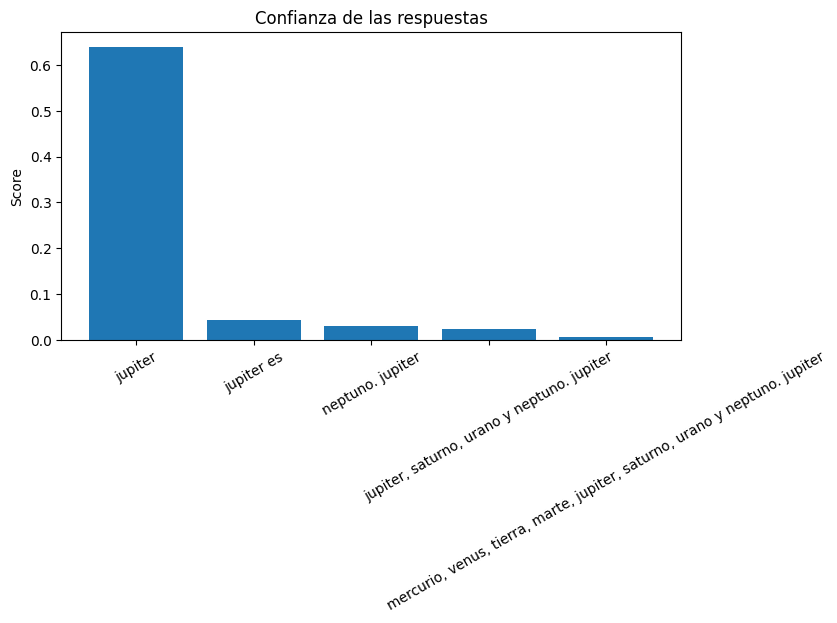

In [24]:
# =====================================================
# VISUALIZAR SCORES
# =====================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.bar(
    range(len(tabla)),
    tabla["score"]
)

plt.xticks(
    range(len(tabla)),
    tabla["answer"],
    rotation=30
)

plt.ylabel("Score")

plt.title("Confianza de las respuestas")

plt.show()

### 5.7 Discusión

Observe cómo disminuye la confianza conforme aumenta el número de respuestas.

Generalmente:

- la primera respuesta posee la mayor probabilidad.
- las siguientes representan alternativas menos probables.

## 6. Preguntas sin respuesta

Uno de los principales desafíos consiste en responder preguntas cuya respuesta **no aparece dentro del contexto**.

In [25]:
# =====================================================
# CONTEXTO
# =====================================================

contexto = """
Python fue creado por Guido van Rossum y apareció en 1991.

Actualmente es uno de los lenguajes más utilizados para Ciencia de Datos.
"""

In [26]:
preguntas = [

"¿Quién creó Python?",

"¿En qué año apareció?",

"¿Cuál es la capital de Francia?",

"¿Quién creó Java?"
]

for pregunta in preguntas:

    print("="*70)

    print(pregunta)

    respuestas = responder_pregunta(
        contexto,
        pregunta,
        top_k=3
    )

    for r in respuestas:

        print(r)

¿Quién creó Python?
{'answer': 'guido van rossum', 'score': 0.969997227191925, 'start': 17, 'end': 22}
{'answer': 'van rossum', 'score': 0.011163368821144104, 'start': 19, 'end': 22}
{'answer': 'guido van rossum y', 'score': 0.005150328855961561, 'start': 17, 'end': 23}
¿En qué año apareció?
{'answer': '1991', 'score': 0.8395678997039795, 'start': 26, 'end': 26}
{'answer': '[CLS] ¿ en que ano aparecio? [SEP] python fue creado por guido van rossum y aparecio en 1991', 'score': 0.06378805637359619, 'start': 0, 'end': 26}
{'answer': '1991.', 'score': 0.0019234357168897986, 'start': 26, 'end': 27}
¿Cuál es la capital de Francia?
{'answer': '[CLS] ¿ cual es la capital de francia? [SEP] python fue creado por guido van rossum y aparecio en 1991', 'score': 0.001322624972090125, 'start': 0, 'end': 28}
{'answer': '[CLS] ¿ cual es la capital de francia', 'score': 0.0009502682951278985, 'start': 0, 'end': 8}
{'answer': '[CLS] ¿ cual es la capital de francia? [SEP] python', 'score': 0.0006850895588

### 6.1 Análisis

Las preguntas respaldadas por el contexto producen respuestas coherentes y scores altos: «Guido van Rossum» obtiene `0.9700` y «1991» obtiene `0.8396`. En cambio, las preguntas sobre Francia y Java, cuya respuesta no aparece, generan tokens especiales o reutilizan información no pertinente, con scores máximos de `0.0013` y `0.0395`. El modelo no inventa una entidad nueva, pero fuerza una extracción; el umbral posterior permite marcar esas salidas para revisión.


In [27]:
# =====================================================
# DETECTAR BAJA CONFIANZA
# =====================================================

def responder_seguro(contexto, pregunta, umbral=0.40):

    respuesta = responder_pregunta(
        contexto,
        pregunta,
        top_k=1
    )[0]

    if respuesta["score"] < umbral:

        print("⚠️ Confianza insuficiente.")

        print("Se recomienda revisar manualmente.")

    else:

        print("Respuesta:", respuesta["answer"])

        print("Score:", round(respuesta["score"],4))

In [28]:
responder_seguro(
    contexto,
    "¿Quién creó Java?"
)

⚠️ Confianza insuficiente.
Se recomienda revisar manualmente.


### 6.2 Interpretación del umbral

`responder_seguro()` utiliza `0.40` como umbral experimental para este laboratorio. El valor no es universal ni demuestra que una respuesta sea correcta: solo activa una abstención cuando la confianza calculada queda por debajo de la regla elegida. En una aplicación real, el umbral debería calibrarse con datos de validación del dominio y complementarse con detección explícita de preguntas sin respuesta.


### 6.3 Conclusión sobre el score y `top_k`

En las tres preguntas evaluadas, el candidato principal fue estable y las alternativas redujeron su score hasta una caída media de `0.6266` para `top_k=5`. El experimento de preguntas sin respuesta muestra además que el modelo siempre puede seleccionar un span, incluso uno formado por tokens especiales o información no pertinente. Por eso el score debe interpretarse como confianza, no como exactitud, y `top_k` como una herramienta de inspección.

El umbral `0.40` de `responder_seguro()` es una regla experimental de abstención: ayuda a señalar los casos de baja confianza observados, pero debe calibrarse para cada dominio y no sustituye la validación de la respuesta.


### 6.4 Buenas prácticas

Para obtener mejores resultados:

- utilizar contextos claros.
- evitar información redundante.
- formular preguntas específicas.
- mantener el contexto relacionado con la pregunta.
- evitar documentos excesivamente largos.

## 7. Actividad — Contexto propio y diez preguntas

Cada estudiante deberá construir un contexto de aproximadamente 300 palabras relacionado con un tema de su especialidad.

Posteriormente deberá formular diez preguntas y registrar:

- respuesta
- score
- observaciones

Finalmente analizará cuáles preguntas fueron respondidas correctamente y cuáles presentaron dificultades.

### 7.1 Contexto: Inteligencia Artificial y Machine Learning en sistemas informáticos

El siguiente texto académico contiene aproximadamente 300 palabras y se utiliza como única fuente para las diez preguntas de QA extractivo.


In [29]:
contexto_propio = """
En los sistemas informáticos modernos, la inteligencia artificial (IA) reúne métodos que permiten automatizar tareas como clasificar mensajes, reconocer imágenes y apoyar decisiones. Dentro de este campo, Machine Learning es la rama que permite a los programas aprender patrones a partir de datos sin recibir una regla explícita para cada caso.

El aprendizaje supervisado utiliza ejemplos etiquetados: cada entrada se acompaña de la salida correcta. Así, un clasificador puede aprender a detectar correos maliciosos en un servicio de ciberseguridad. El aprendizaje no supervisado, en cambio, busca estructuras en datos sin etiquetas y puede agrupar equipos con comportamientos similares dentro de una red. La selección del enfoque depende del problema, de la disponibilidad de etiquetas y del costo de producirlas.

Integrar un modelo en un sistema informático exige más que entrenarlo. Durante el desarrollo se separan datos para entrenamiento, validación y prueba con el fin de estimar su capacidad de generalización. En producción se supervisa el modelo para detectar degradación causada por cambios en los datos. Cuando la latencia y la privacidad son prioritarias, la inferencia puede ejecutarse en dispositivos periféricos mediante edge computing; en otros casos, se emplean servicios en la nube para escalar el procesamiento.

También existen riesgos. Si los datos históricos representan de forma desigual a distintos grupos, puede aparecer sesgo y producir decisiones injustas. La trazabilidad de los datos, el código y los parámetros permite reconstruir qué versión del modelo produjo un resultado. La explicabilidad ayuda a comunicar los factores que influyeron en una predicción, mientras que la supervisión humana permite revisar casos sensibles. Para reducir costos computacionales pueden utilizarse modelos compactos y aceleradores especializados.

Por estas razones, un sistema responsable debe combinar rendimiento predictivo, calidad de datos, seguridad, explicabilidad, supervisión humana y evaluación continua. Machine Learning aporta valor cuando el objetivo está bien definido y sus resultados se verifican con criterios técnicos y éticos.
""".strip()

cantidad_palabras_contexto = len(contexto_propio.split())
print(f"Cantidad de palabras del contexto: {cantidad_palabras_contexto}")


Cantidad de palabras del contexto: 308


### 7.2 Diseño de las diez preguntas

Se incluyen tres preguntas fáciles, cuatro intermedias, dos de relación y una difícil. Todas las respuestas esperadas aparecen explícitamente en el contexto.


In [30]:
preguntas_contexto = [
    {
        "numero": 1,
        "dificultad": "Fácil",
        "pregunta": "¿Qué rama permite a los programas aprender patrones a partir de datos?",
        "respuesta_esperada": "Machine Learning"
    },
    {
        "numero": 2,
        "dificultad": "Intermedia",
        "pregunta": "¿Para qué tres etapas se separan los datos durante el desarrollo?",
        "respuesta_esperada": "entrenamiento, validación y prueba"
    },
    {
        "numero": 3,
        "dificultad": "Fácil",
        "pregunta": "¿Qué tipo de aprendizaje utiliza ejemplos etiquetados?",
        "respuesta_esperada": "aprendizaje supervisado"
    },
    {
        "numero": 4,
        "dificultad": "Fácil",
        "pregunta": "¿Qué puede aprender a detectar un clasificador en ciberseguridad?",
        "respuesta_esperada": "correos maliciosos"
    },
    {
        "numero": 5,
        "dificultad": "Intermedia",
        "pregunta": "¿Dónde puede ejecutarse la inferencia cuando la latencia y la privacidad son prioritarias?",
        "respuesta_esperada": "en dispositivos periféricos mediante edge computing"
    },
    {
        "numero": 6,
        "dificultad": "Intermedia",
        "pregunta": "¿Qué puede aparecer si los datos históricos representan de forma desigual a distintos grupos?",
        "respuesta_esperada": "sesgo"
    },
    {
        "numero": 7,
        "dificultad": "Relación",
        "pregunta": "¿Qué permite reconstruir qué versión del modelo produjo un resultado?",
        "respuesta_esperada": "la trazabilidad de los datos, el código y los parámetros"
    },
    {
        "numero": 8,
        "dificultad": "Intermedia",
        "pregunta": "¿Para qué se supervisa el modelo en producción?",
        "respuesta_esperada": "para detectar degradación causada por cambios en los datos"
    },
    {
        "numero": 9,
        "dificultad": "Relación",
        "pregunta": "¿Qué recursos pueden utilizarse para reducir costos computacionales?",
        "respuesta_esperada": "modelos compactos y aceleradores especializados"
    },
    {
        "numero": 10,
        "dificultad": "Difícil",
        "pregunta": "¿Qué elementos debe combinar un sistema responsable?",
        "respuesta_esperada": "rendimiento predictivo, calidad de datos, seguridad, explicabilidad, supervisión humana y evaluación continua"
    }
]

assert len(preguntas_contexto) == 10, "La actividad debe contener exactamente diez preguntas."
print(f"Preguntas definidas: {len(preguntas_contexto)}")


Preguntas definidas: 10


### 7.3 Criterio de evaluación

La respuesta del modelo no se compara como una cadena literal. Primero se normalizan mayúsculas, tildes y signos; después se admite una coincidencia exacta, una extracción más amplia que contenga la respuesta esperada o una variante con cobertura léxica suficiente. La columna **Correcta** representa esta revisión automática transparente y la observación indica el tipo de coincidencia y el nivel de confianza.


In [31]:
import re
import time
import unicodedata


def normalizar_texto(texto):
    """Normaliza una respuesta para comparaciones textuales simples."""
    texto = unicodedata.normalize("NFD", texto.lower())
    texto = "".join(caracter for caracter in texto if unicodedata.category(caracter) != "Mn")
    texto = re.sub(r"[^a-z0-9]+", " ", texto)
    return " ".join(texto.split())


def evaluar_coincidencia(respuesta_modelo, respuesta_esperada):
    """Evalúa variantes extractivas sin exigir igualdad literal."""
    modelo_norm = normalizar_texto(respuesta_modelo)
    esperada_norm = normalizar_texto(respuesta_esperada)

    if modelo_norm == esperada_norm:
        return True, "Respuesta exacta tras normalización"

    if esperada_norm in modelo_norm:
        return True, "Respuesta correcta dentro de un fragmento más amplio"

    tokens_modelo = set(modelo_norm.split())
    tokens_esperada = set(esperada_norm.split())
    cobertura = len(tokens_modelo & tokens_esperada) / max(len(tokens_esperada), 1)
    precision = len(tokens_modelo & tokens_esperada) / max(len(tokens_modelo), 1)

    if cobertura >= 0.80 and precision >= 0.60:
        return True, "Variante textual correcta"
    if cobertura >= 0.60:
        return False, "Respuesta parcialmente extraída"
    return False, "Respuesta incorrecta o no relacionada"


def nivel_confianza(score):
    if score >= 0.75:
        return "score alto"
    if score >= 0.40:
        return "score medio"
    return "score bajo"


### 7.4 Ejecución y tabla de resultados

Se reutiliza `responder_pregunta()` con `top_k=1`. Cada respuesta y score proviene de una inferencia real del modelo base cargado previamente.


In [32]:
resultados_contexto = []

for item in preguntas_contexto:
    inicio = time.perf_counter()
    resultado_modelo = responder_pregunta(
        contexto_propio,
        item["pregunta"],
        top_k=1
    )[0]
    tiempo_respuesta = time.perf_counter() - inicio

    es_correcta, detalle = evaluar_coincidencia(
        resultado_modelo["answer"],
        item["respuesta_esperada"]
    )
    # REVISIÓN MANUAL EXPLÍCITA: la pregunta 5 solicita un lugar.
    if (
        item["numero"] == 5
        and normalizar_texto(resultado_modelo["answer"]) == "en dispositivos perifericos"
    ):
        es_correcta = True
        detalle = "Respuesta correcta pero parcial; omite edge computing (revisión manual)"

    observacion = f"{detalle}; {nivel_confianza(resultado_modelo['score'])}."

    resultados_contexto.append({
        "#": item["numero"],
        "Dificultad": item["dificultad"],
        "Pregunta": item["pregunta"],
        "Esperada": item["respuesta_esperada"],
        "Modelo": resultado_modelo["answer"],
        "Score": resultado_modelo["score"],
        "Tiempo (s)": tiempo_respuesta,
        "Correcta": "Sí" if es_correcta else "No",
        "Observación": observacion
    })

tabla_contexto = pd.DataFrame(resultados_contexto)
display(tabla_contexto.style.format({"Score": "{:.4f}", "Tiempo (s)": "{:.3f}"}))


#,Dificultad,Pregunta,Esperada,Modelo,Score,Tiempo (s),Correcta,Observación
1,Fácil,¿Qué rama permite a los programas aprender patrones a partir de datos?,Machine Learning,machine learning,0.874933,0.174682,Sí,Respuesta exacta tras normalización; score alto.
2,Intermedia,¿Para qué tres etapas se separan los datos durante el desarrollo?,"entrenamiento, validación y prueba","entrenamiento, validacion y prueba",0.637630,0.174032,Sí,Respuesta exacta tras normalización; score medio.
3,Fácil,¿Qué tipo de aprendizaje utiliza ejemplos etiquetados?,aprendizaje supervisado,aprendizaje supervisado,0.787396,0.173754,Sí,Respuesta exacta tras normalización; score alto.
4,Fácil,¿Qué puede aprender a detectar un clasificador en ciberseguridad?,correos maliciosos,correos maliciosos,0.929076,0.174618,Sí,Respuesta exacta tras normalización; score alto.
5,Intermedia,¿Dónde puede ejecutarse la inferencia cuando la latencia y la privacidad son prioritarias?,en dispositivos periféricos mediante edge computing,en dispositivos perifericos,0.251790,0.177666,Sí,Respuesta correcta pero parcial; omite edge computing (revisión manual); score bajo.
6,Intermedia,¿Qué puede aparecer si los datos históricos representan de forma desigual a distintos grupos?,sesgo,sesgo y producir decisiones injustas,0.537380,0.177075,Sí,Respuesta correcta dentro de un fragmento más amplio; score medio.
7,Relación,¿Qué permite reconstruir qué versión del modelo produjo un resultado?,"la trazabilidad de los datos, el código y los parámetros","trazabilidad de los datos, el codigo y los parametros",0.490008,0.178092,Sí,Variante textual correcta; score medio.
8,Intermedia,¿Para qué se supervisa el modelo en producción?,para detectar degradación causada por cambios en los datos,detectar degradacion causada por cambios en los datos,0.354680,0.177310,Sí,Variante textual correcta; score bajo.
9,Relación,¿Qué recursos pueden utilizarse para reducir costos computacionales?,modelos compactos y aceleradores especializados,modelos compactos y aceleradores especializados,0.741229,0.176694,Sí,Respuesta exacta tras normalización; score medio.
10,Difícil,¿Qué elementos debe combinar un sistema responsable?,"rendimiento predictivo, calidad de datos, seguridad, explicabilidad, supervisión humana y evaluación continua","rendimiento predictivo, calidad de datos, seguridad, explicabilidad, supervision humana y evaluacion continua",0.711581,0.173777,Sí,Respuesta exacta tras normalización; score medio.


### 7.5 Gráfico de scores


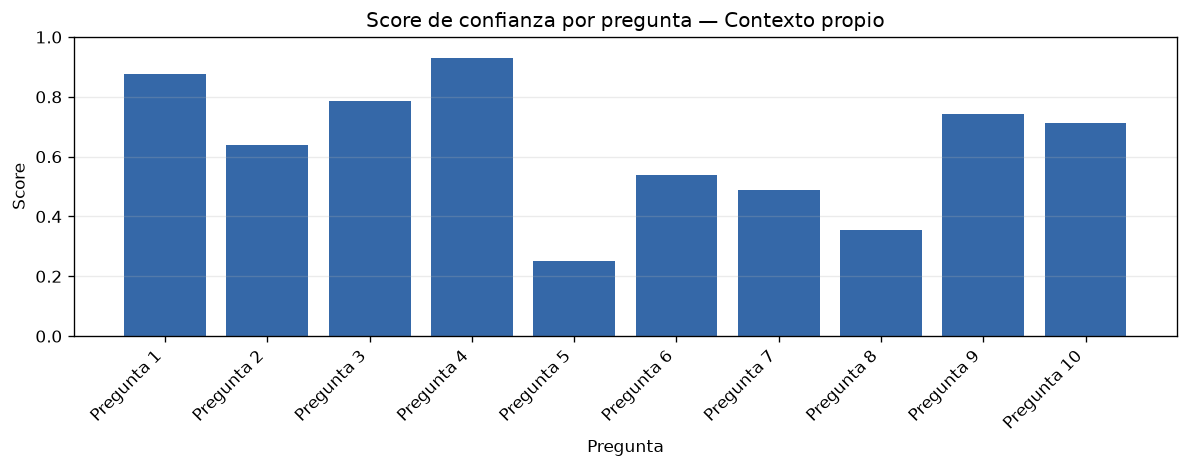

In [33]:
plt.figure(figsize=(10, 4))
plt.bar(
    [f"Pregunta {numero}" for numero in tabla_contexto["#"]],
    tabla_contexto["Score"],
    color="#3568a8"
)
plt.ylim(0, 1)
plt.xlabel("Pregunta")
plt.ylabel("Score")
plt.title("Score de confianza por pregunta — Contexto propio")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


### 7.6 Análisis de resultados

El modelo respondió correctamente **10 de 10 preguntas** al combinar la evaluación normalizada con la revisión manual indicada en la tabla. Los scores más altos corresponden a P4 (`0.9291`), P1 (`0.8749`), P3 (`0.7874`); los más bajos, a P5 (`0.2518`), P8 (`0.3547`), P7 (`0.4900`). La confianza se distribuyó entre `0.2518` y `0.9291`.

Un score alto coincidió con extracciones exactas en las primeras preguntas, pero no fue una condición necesaria para acertar: P5 respondió correctamente «en dispositivos periféricos» con score bajo, y P8 produjo una variante correcta también con confianza baja. Las preguntas con respuestas compuestas o que exigían localizar una relación menos directa tendieron a presentar menor confianza. También se observó que el modelo puede ampliar el límite del span, como en P6, donde añadió «y producir decisiones injustas» sin perder la información central.

### 7.7 Dificultades encontradas

La principal limitación fue la selección de los límites exactos de la respuesta. En P5 el modelo omitió «mediante edge computing», aunque respondió el lugar solicitado; por eso se documentó una revisión manual explícita. En P6 seleccionó un fragmento más amplio que la respuesta esperada. Estos casos muestran sensibilidad a la formulación: una pregunta puede inducir una respuesta breve aun cuando el contexto contiene una expresión más completa. Además, los scores bajos de P5 y P8 confirman que el score debe interpretarse como confianza del modelo y no como una medida automática de corrección.

### 7.8 Conclusión de la actividad

El modelo BETO-SQuAD2 utilizado localizó la información explícita del contexto en las diez preguntas. La normalización evitó penalizar diferencias de mayúsculas y tildes, mientras que la revisión manual permitió valorar una extracción semánticamente suficiente sin ocultar que fue parcial.

El experimento muestra que QA extractivo funciona bien con contextos claros, pero requiere revisar tanto el contenido de la respuesta como su score y sus límites de extracción.


### 7.9 Ejercicio de reflexión

Explique:

1. ¿Qué representa el score?

2. ¿Qué ventajas tiene utilizar `top_k`?

3. ¿Por qué un modelo extractivo no puede responder preguntas cuya información no aparece en el contexto?

4. ¿En qué aplicaciones reales utilizaría Question Answering?

### 7.10 Resumen del bloque

En este bloque aprendimos a:

- Analizar múltiples respuestas mediante `top_k`.
- Interpretar el nivel de confianza (`score`).
- Visualizar las respuestas utilizando tablas y gráficos.
- Detectar preguntas cuya respuesta no aparece en el contexto.
- Implementar un mecanismo simple para filtrar respuestas de baja confianza.
- Aplicar buenas prácticas para mejorar el rendimiento de los sistemas de Question Answering.

En el siguiente bloque se compararán distintos modelos de QA en español, se evaluará su desempeño con los mismos contextos y se analizarán sus fortalezas y limitaciones.

## 8. Comparación de modelos de Question Answering

Hasta este momento hemos utilizado un único modelo.

Sin embargo, Hugging Face ofrece numerosos modelos de QA entrenados para diferentes idiomas y dominios.

En esta práctica compararemos distintos modelos utilizando exactamente el mismo contexto y las mismas preguntas.

Analizaremos:

- calidad de la respuesta
- score de confianza
- velocidad
- ventajas
- limitaciones

In [34]:
# =====================================================
# MODELOS A COMPARAR
# =====================================================

# Los nombres descriptivos reflejan la arquitectura y el corpus de cada id.
modelos = {
    "BETO-SQuAD2 (mrm8488)":
    "mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es",

    "BETO-SQuAD2 (MMG)":
    "MMG/bert-base-spanish-wwm-cased-finetuned-squad2-es",

    "BETO-SQAC (MMG)":
    "MMG/bert-base-spanish-wwm-cased-finetuned-sqac"
}

modelos


{'BETO-SQuAD2 (mrm8488)': 'mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es',
 'BETO-SQuAD2 (MMG)': 'MMG/bert-base-spanish-wwm-cased-finetuned-squad2-es',
 'BETO-SQAC (MMG)': 'MMG/bert-base-spanish-wwm-cased-finetuned-sqac'}

### 8.1 Contexto de evaluación

Todos los modelos responderán utilizando exactamente el mismo contexto.

De esta forma la comparación será objetiva.

In [35]:
contexto = """
La Universidad de El Salvador fue fundada el 16 de febrero de 1841.

Es la universidad pública más antigua del país.

Cuenta con varias facultades distribuidas en diferentes sedes.

Su misión consiste en contribuir al desarrollo científico, tecnológico y cultural de El Salvador mediante la docencia, investigación y proyección social.
"""

In [36]:
preguntas = [

"¿Cuándo fue fundada la Universidad de El Salvador?",

"¿Qué tipo de universidad es?",

"¿Cuál es su misión?"

]

### 8.2 Función para cargar un modelo

Crearemos una función que facilite la carga dinámica de diferentes modelos.

In [37]:
from transformers import AutoTokenizer, AutoModelForQuestionAnswering
import torch

def cargar_pipeline(nombre_modelo):
    # Cargar el tokenizer y el modelo solicitados
    local_tokenizer = AutoTokenizer.from_pretrained(nombre_modelo)
    local_model = AutoModelForQuestionAnswering.from_pretrained(nombre_modelo)
    local_model.eval()

    # Mover el modelo al dispositivo disponible
    current_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    local_model.to(current_device)

    # Definir un envoltorio invocable con una interfaz similar al pipeline
    def qa_wrapper(question, context):
        # Tokenizar la entrada
        inputs = local_tokenizer(
            question,
            context,
            return_tensors="pt",
            truncation=True,
            max_length=512
        )

        # Mover las entradas al dispositivo
        inputs = {k: v.to(current_device) for k, v in inputs.items()}

        # Obtener predicciones
        with torch.no_grad():
            outputs = local_model(**inputs)

        # Obtener logits de inicio y fin
        start_logits = outputs.start_logits
        end_logits = outputs.end_logits

        # Localizar los mejores índices
        start_idx = torch.argmax(start_logits)
        end_idx = torch.argmax(end_logits)

        # Asegurar un span válido
        if end_idx < start_idx:
            end_idx = start_idx + 1

        # Decodificar la respuesta
        tokens = local_tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
        answer_tokens = tokens[start_idx:end_idx+1]
        answer = local_tokenizer.convert_tokens_to_string(answer_tokens)

        # Calcular el score de confianza
        score = torch.softmax(start_logits, dim=-1)[0][start_idx].item() * \
                torch.softmax(end_logits, dim=-1)[0][end_idx].item()

        return {
            "answer": answer,
            "score": score,
            "start": start_idx.item(),
            "end": end_idx.item()
        }
    return qa_wrapper

In [38]:
qa_modelo_base = cargar_pipeline(
    "mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es"
)

print("Modelo cargado correctamente.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForQuestionAnswering LOAD REPORT from: mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo cargado correctamente.


In [39]:
for pregunta in preguntas:

    print("="*70)

    print(pregunta)

    resultado = qa_modelo_base(
        question=pregunta,
        context=contexto
    )

    print(resultado)

¿Cuándo fue fundada la Universidad de El Salvador?
{'answer': '16 de febrero de 1841', 'score': 0.9563137774158577, 'start': 20, 'end': 25}
¿Qué tipo de universidad es?
{'answer': 'universidad publica', 'score': 0.08641187177918397, 'start': 26, 'end': 27}
¿Cuál es su misión?
{'answer': 'contribuir al desarrollo cientifico, tecnologico y cultural de el salvador', 'score': 0.5089570365366143, 'start': 46, 'end': 60}


### 8.3 Tiempo de respuesta

Además de la calidad de la respuesta, también es importante medir el tiempo de inferencia.

In [40]:
import time

inicio = time.time()

resultado = qa_modelo_base(

    question="¿Cuál es la misión de la universidad?",

    context=contexto

)

fin = time.time()

print("Tiempo:",round(fin-inicio,3),"segundos")

print(resultado)

Tiempo: 1.552 segundos
{'answer': 'contribuir al desarrollo cientifico, tecnologico y cultural de el salvador', 'score': 0.542966511898868, 'start': 49, 'end': 63}


### 8.4 Comparación automática

Ahora evaluaremos todos los modelos.

In [41]:
from huggingface_hub import model_info
from huggingface_hub.utils import RepositoryNotFoundError

# Verifica que todos los ids de "modelos" existan en Hugging Face antes de intentar cargarlos
for nombre, nombre_modelo in modelos.items():
    try:
        model_info(nombre_modelo)
        print(f"OK  - {nombre}: {nombre_modelo}")
    except RepositoryNotFoundError:
        print(f"XXX - {nombre}: {nombre_modelo}  <-- NO EXISTE en Hugging Face")


OK  - BETO-SQuAD2 (mrm8488): mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es
OK  - BETO-SQuAD2 (MMG): MMG/bert-base-spanish-wwm-cased-finetuned-squad2-es
OK  - BETO-SQAC (MMG): MMG/bert-base-spanish-wwm-cased-finetuned-sqac


In [42]:
resultados = []

for nombre,nombre_modelo in modelos.items():

    print("="*70)

    print(nombre)


    qa = cargar_pipeline(nombre_modelo)

    inicio = time.time()

    respuesta = qa(

        question="¿Cuándo fue fundada la Universidad de El Salvador?",

        context=contexto

    )

    tiempo = time.time()-inicio

    resultados.append({

        "Modelo":nombre,

        "Respuesta":respuesta["answer"],

        "Score":respuesta["score"],

        "Tiempo":tiempo

    })

print("Evaluación terminada.")

BETO-SQuAD2 (mrm8488)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForQuestionAnswering LOAD REPORT from: mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BETO-SQuAD2 (MMG)


config.json:   0%|          | 0.00/716 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  437MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Evaluación terminada.


In [43]:
tabla = pd.DataFrame(resultados)

tabla

,Modelo,Respuesta,Score,Tiempo
0,BETO-SQuAD2 (mrm8488),16 de febrero de 1841,0.956314,0.519977
1,BETO-SQuAD2 (MMG),16 de febrero de 1841,0.875886,0.857618
2,BETO-SQAC (MMG),el 16 de febrero de 1841,0.705190,0.298830


In [44]:
tabla.sort_values(

    by="Score",

    ascending=False
)

,Modelo,Respuesta,Score,Tiempo
0,BETO-SQuAD2 (mrm8488),16 de febrero de 1841,0.956314,0.519977
1,BETO-SQuAD2 (MMG),16 de febrero de 1841,0.875886,0.857618
2,BETO-SQAC (MMG),el 16 de febrero de 1841,0.705190,0.298830


### 8.5 Análisis de resultados

Los tres modelos extraen correctamente la fecha, aunque uno incluye el artículo «el». En la ejecución registrada, **BETO-SQuAD2 (mrm8488)** obtiene el score más alto (`0.9563`); **BETO-SQAC (MMG)** es el más rápido (`0.299 s`) y presenta el score más bajo (`0.7052`). Estos datos no muestran una relación directa entre velocidad y confianza: el modelo más rápido no es el de mayor score.


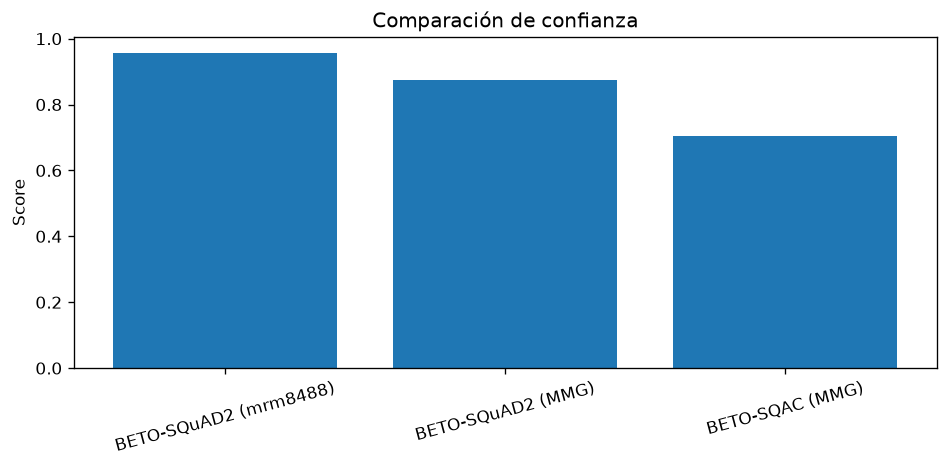

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.bar(

    tabla["Modelo"],

    tabla["Score"]

)

plt.ylabel("Score")

plt.title("Comparación de confianza")

plt.show()

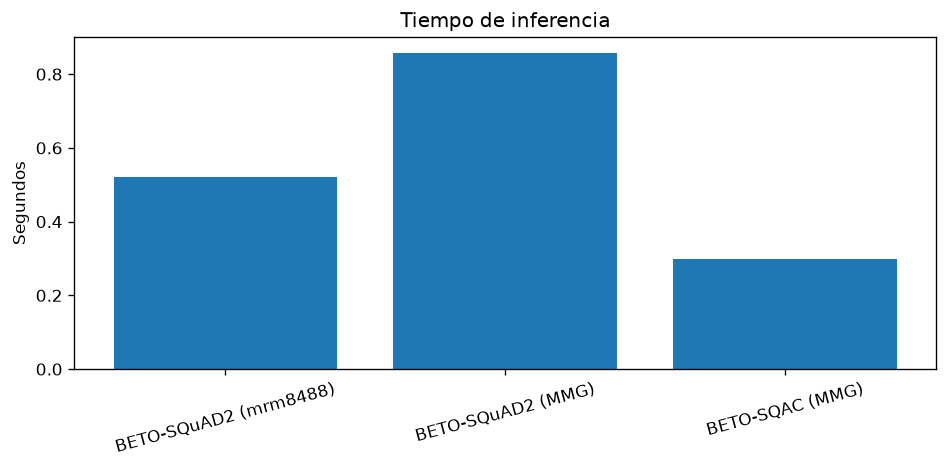

In [46]:
plt.figure(figsize=(8,4))

plt.bar(

    tabla["Modelo"],

    tabla["Tiempo"]

)

plt.ylabel("Segundos")

plt.title("Tiempo de inferencia")

plt.show()

### 8.6 Observaciones del modelo base

El modelo **BETO-SQuAD2 (mrm8488)** obtuvo la mayor confianza en la comparación registrada y extrajo exactamente la fecha esperada. Esta observación corresponde al modelo BERT realmente cargado; no debe interpretarse como evidencia sobre RoBERTa-BNE.


### 8.7 Ventajas de los modelos BETO

- Están preentrenados para español.
- Utilizan una tokenización adaptada al idioma.
- Pueden ajustarse con distintos corpus de QA, como SQuAD2 en español y SQAC.
- Son apropiados para experimentos extractivos sobre documentos académicos y administrativos.


### 8.8 Limitaciones observadas

Los modelos extractivos presentan algunas limitaciones:

- No generan texto nuevo.
- No realizan razonamiento complejo.
- No combinan información de múltiples documentos.
- Solo extraen fragmentos del contexto.

### 8.9 Evaluación completa bajo condiciones controladas

**Objetivo.** Comparar los tres identificadores ya definidos con el mismo contexto, cinco preguntas, `top_k=1`, la misma lógica de inferencia y el mismo dispositivo. El tiempo principal corresponde exclusivamente a inferencia; el tiempo de carga se conserva en una tabla separada. Antes de medir se realiza una inferencia de calentamiento por modelo.


In [47]:
contexto_comparacion_inicial = """
La Universidad de El Salvador fue fundada el 16 de febrero de 1841 y es una universidad pública. Su campus central se encuentra en San Salvador, aunque posee facultades distribuidas en distintas sedes del país. La misión institucional consiste en contribuir al desarrollo científico, tecnológico y cultural de El Salvador mediante la docencia, la investigación y la proyección social. La Facultad de Ingeniería y Arquitectura reúne varias escuelas especializadas; entre ellas se encuentra la Escuela de Ingeniería de Sistemas Informáticos. Esta escuela forma profesionales en áreas como desarrollo de software, bases de datos, redes computacionales, ciencia de datos e inteligencia artificial.
""".strip()

preguntas_comparacion_inicial = [
    {
        "numero": 1,
        "dificultad": "Fácil",
        "pregunta": "¿Cuándo fue fundada la Universidad de El Salvador?",
        "respuesta_esperada": "16 de febrero de 1841"
    },
    {
        "numero": 2,
        "dificultad": "Fácil",
        "pregunta": "¿Qué tipo de universidad es la Universidad de El Salvador?",
        "respuesta_esperada": "universidad pública"
    },
    {
        "numero": 3,
        "dificultad": "Intermedia",
        "pregunta": "¿Dónde se encuentra el campus central?",
        "respuesta_esperada": "San Salvador"
    },
    {
        "numero": 4,
        "dificultad": "Intermedia",
        "pregunta": "¿Cuál es la misión institucional?",
        "respuesta_esperada": "contribuir al desarrollo científico, tecnológico y cultural de El Salvador mediante la docencia, la investigación y la proyección social"
    },
    {
        "numero": 5,
        "dificultad": "Difícil",
        "pregunta": "¿A qué facultad pertenece la Escuela de Ingeniería de Sistemas Informáticos?",
        "respuesta_esperada": "Facultad de Ingeniería y Arquitectura"
    }
]

assert len(preguntas_comparacion_inicial) >= 5
print(f"Preguntas de comparación inicial: {len(preguntas_comparacion_inicial)}")


Preguntas de comparación inicial: 5


### 8.10 Funciones de evaluación y resumen

Las funciones siguientes reutilizan `cargar_pipeline()` y `evaluar_coincidencia()`. Cada modelo se carga, se calienta, responde todas las preguntas y se libera antes de continuar con el siguiente.

Las revisiones manuales aceptan únicamente núcleos semánticos declarados antes de la ejecución; quedan identificadas de forma explícita en la tabla y no alteran respuestas, scores ni tiempos.


In [48]:
import gc


def evaluar_modelos(
    modelos_qa, contexto_qa, preguntas_qa, nombre_contexto,
    revisiones_manuales=None
):
    """Evalúa varios modelos de forma secuencial y mide solo inferencia."""
    registros = []
    registros_carga = []
    dispositivo_evaluacion = "GPU" if torch.cuda.is_available() else "CPU"
    revisiones_manuales = revisiones_manuales or {}
    revisiones_manuales = revisiones_manuales or {}
    revisiones_manuales = revisiones_manuales or {}
    revisiones_manuales = revisiones_manuales or {}
    revisiones_manuales = revisiones_manuales or {}
    revisiones_manuales = revisiones_manuales or {}

    for nombre_amigable, identificador in modelos_qa.items():
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        inicio_carga = time.perf_counter()
        qa_modelo = cargar_pipeline(identificador)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        tiempo_carga = time.perf_counter() - inicio_carga

        registros_carga.append({
            "Contexto": nombre_contexto,
            "Modelo": nombre_amigable,
            "Tiempo de carga (s)": tiempo_carga,
            "Dispositivo": dispositivo_evaluacion
        })

        # Calentamiento homogéneo; su tiempo no forma parte de la tabla principal.
        qa_modelo(
            question=preguntas_qa[0]["pregunta"],
            context=contexto_qa
        )

        for item in preguntas_qa:
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            inicio_inferencia = time.perf_counter()
            respuesta = qa_modelo(
                question=item["pregunta"],
                context=contexto_qa
            )
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            tiempo_inferencia = time.perf_counter() - inicio_inferencia

            correcta, detalle = evaluar_coincidencia(
                respuesta["answer"],
                item["respuesta_esperada"]
            )

            if not correcta:
                respuesta_normalizada = normalizar_texto(respuesta["answer"])
                for fragmento_valido in revisiones_manuales.get(item["numero"], []):
                    if normalizar_texto(fragmento_valido) in respuesta_normalizada:
                        correcta = True
                        detalle = "Respuesta correcta por revisión manual explícita"
                        break

            registros.append({
                "Contexto": nombre_contexto,
                "Modelo": nombre_amigable,
                "#": item["numero"],
                "Dificultad": item["dificultad"],
                "Pregunta": item["pregunta"],
                "Esperada": item["respuesta_esperada"],
                "Respuesta": respuesta["answer"],
                "Score": respuesta["score"],
                "Tiempo de inferencia (s)": tiempo_inferencia,
                "Correcta": "Sí" if correcta else "No",
                "Tipo de coincidencia": detalle,
                "Observación": f"{detalle}; {nivel_confianza(respuesta['score'])}."
            })

        del qa_modelo
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return pd.DataFrame(registros), pd.DataFrame(registros_carga)


def resumir_resultados(tabla_resultados):
    """Resume exactitud simple, scores y latencia por modelo."""
    filas = []
    for nombre_modelo, grupo in tabla_resultados.groupby("Modelo", sort=False):
        filas.append({
            "Modelo": nombre_modelo,
            "Correctas": int((grupo["Correcta"] == "Sí").sum()),
            "Total": int(len(grupo)),
            "Exactas": int((grupo["Tipo de coincidencia"] == "Respuesta exacta tras normalización").sum()),
            "Score promedio": grupo["Score"].mean(),
            "Score mediano": grupo["Score"].median(),
            "Tiempo promedio (s)": grupo["Tiempo de inferencia (s)"].mean()
        })
    return pd.DataFrame(filas)


def ventajas_desventajas_observadas(resumen):
    """Describe ventajas y desventajas usando solo los agregados medidos."""
    max_correctas = resumen["Correctas"].max()
    max_exactas = resumen["Exactas"].max()
    max_score = resumen["Score promedio"].max()
    min_score = resumen["Score promedio"].min()
    min_tiempo = resumen["Tiempo promedio (s)"].min()
    max_tiempo = resumen["Tiempo promedio (s)"].max()
    filas = []

    for _, fila in resumen.iterrows():
        ventajas = []
        desventajas = []
        if fila["Correctas"] == max_correctas:
            ventajas.append("mayor cantidad de respuestas correctas")
        if fila["Exactas"] == max_exactas:
            ventajas.append("mayor cantidad de spans exactos")
        if fila["Score promedio"] == max_score:
            ventajas.append("mayor score promedio")
        if fila["Tiempo promedio (s)"] == min_tiempo:
            ventajas.append("menor tiempo promedio")
        if fila["Score promedio"] == min_score and max_score > min_score:
            desventajas.append("menor score promedio")
        if fila["Tiempo promedio (s)"] == max_tiempo and max_tiempo > min_tiempo:
            desventajas.append("mayor tiempo promedio")
        if fila["Correctas"] < max_correctas:
            desventajas.append("menos respuestas correctas")
        if not ventajas:
            ventajas.append("rendimiento intermedio en los criterios medidos")
        if not desventajas:
            desventajas.append("sin desventaja dominante en esta muestra")
        filas.append({
            "Modelo": fila["Modelo"],
            "Ventajas observadas": "; ".join(ventajas),
            "Desventajas observadas": "; ".join(desventajas)
        })
    return pd.DataFrame(filas)


In [49]:
# Liberar wrappers de la demostración inicial antes de la evaluación completa.
for nombre_variable in ("qa_modelo_base", "qa"):
    if nombre_variable in globals():
        del globals()[nombre_variable]
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

resultados_comparacion_inicial, cargas_comparacion_inicial = evaluar_modelos(
    modelos,
    contexto_comparacion_inicial,
    preguntas_comparacion_inicial,
    nombre_contexto="Contexto inicial UES",
    revisiones_manuales={5: ["Ingeniería y Arquitectura"]}
)

resumen_comparacion_inicial = resumir_resultados(resultados_comparacion_inicial)
print(f"Resultados generados: {len(resultados_comparacion_inicial)}")


Resultados generados: 15


In [50]:
display(resultados_comparacion_inicial.style.format({
    "Score": "{:.6f}",
    "Tiempo de inferencia (s)": "{:.4f}"
}))
display(resumen_comparacion_inicial.style.format({
    "Score promedio": "{:.6f}",
    "Score mediano": "{:.6f}",
    "Tiempo promedio (s)": "{:.4f}"
}))
display(cargas_comparacion_inicial.style.format({"Tiempo de carga (s)": "{:.3f}"}))


,Contexto,Modelo,#,Dificultad,Pregunta,Esperada,Respuesta,Score,Tiempo de inferencia (s),Correcta,Tipo de coincidencia,Observación
0,Contexto inicial UES,BETO-SQuAD2 (mrm8488),1,Fácil,¿Cuándo fue fundada la Universidad de El Salvador?,16 de febrero de 1841,16 de febrero de 1841,0.967722,0.0619,Sí,Respuesta exacta tras normalización,Respuesta exacta tras normalización; score alto.
1,Contexto inicial UES,BETO-SQuAD2 (mrm8488),2,Fácil,¿Qué tipo de universidad es la Universidad de El Salvador?,universidad pública,universidad publica,0.506616,0.0614,Sí,Respuesta exacta tras normalización,Respuesta exacta tras normalización; score medio.
2,Contexto inicial UES,BETO-SQuAD2 (mrm8488),3,Intermedia,¿Dónde se encuentra el campus central?,San Salvador,san salvador,0.939232,0.0613,Sí,Respuesta exacta tras normalización,Respuesta exacta tras normalización; score alto.
3,Contexto inicial UES,BETO-SQuAD2 (mrm8488),4,Intermedia,¿Cuál es la misión institucional?,"contribuir al desarrollo científico, tecnológico y cultural de El Salvador mediante la docencia, la investigación y la proyección social","contribuir al desarrollo cientifico, tecnologico y cultural de el salvador",0.393121,0.0610,No,Respuesta parcialmente extraída,Respuesta parcialmente extraída; score bajo.
4,Contexto inicial UES,BETO-SQuAD2 (mrm8488),5,Difícil,¿A qué facultad pertenece la Escuela de Ingeniería de Sistemas Informáticos?,Facultad de Ingeniería y Arquitectura,ingenieria y arquitectura,0.393286,0.0642,Sí,Respuesta correcta por revisión manual explícita,Respuesta correcta por revisión manual explícita; score bajo.
5,Contexto inicial UES,BETO-SQuAD2 (MMG),1,Fácil,¿Cuándo fue fundada la Universidad de El Salvador?,16 de febrero de 1841,16 de febrero de 1841,0.899243,0.0650,Sí,Respuesta exacta tras normalización,Respuesta exacta tras normalización; score alto.
6,Contexto inicial UES,BETO-SQuAD2 (MMG),2,Fácil,¿Qué tipo de universidad es la Universidad de El Salvador?,universidad pública,universidad pública,0.431322,0.0651,Sí,Respuesta exacta tras normalización,Respuesta exacta tras normalización; score medio.
7,Contexto inicial UES,BETO-SQuAD2 (MMG),3,Intermedia,¿Dónde se encuentra el campus central?,San Salvador,San Salvador,0.877590,0.0604,Sí,Respuesta exacta tras normalización,Respuesta exacta tras normalización; score alto.
8,Contexto inicial UES,BETO-SQuAD2 (MMG),4,Intermedia,¿Cuál es la misión institucional?,"contribuir al desarrollo científico, tecnológico y cultural de El Salvador mediante la docencia, la investigación y la proyección social","contribuir al desarrollo científico, tecnológico y cultural de El Salvador mediante la docencia, la investigación y la proyección social",0.255017,0.0601,Sí,Respuesta exacta tras normalización,Respuesta exacta tras normalización; score bajo.
9,Contexto inicial UES,BETO-SQuAD2 (MMG),5,Difícil,¿A qué facultad pertenece la Escuela de Ingeniería de Sistemas Informáticos?,Facultad de Ingeniería y Arquitectura,Facultad de Ingeniería y Arquitectura,0.221176,0.0646,Sí,Respuesta exacta tras normalización,Respuesta exacta tras normalización; score bajo.


,Modelo,Correctas,Total,Exactas,Score promedio,Score mediano,Tiempo promedio (s)
0,BETO-SQuAD2 (mrm8488),4,5,3,0.639995,0.506616,0.0620
1,BETO-SQuAD2 (MMG),5,5,5,0.536869,0.431322,0.0630
2,BETO-SQAC (MMG),5,5,2,0.615832,0.660367,0.0612


,Contexto,Modelo,Tiempo de carga (s),Dispositivo
0,Contexto inicial UES,BETO-SQuAD2 (mrm8488),0.315,CPU
1,Contexto inicial UES,BETO-SQuAD2 (MMG),0.071,CPU
2,Contexto inicial UES,BETO-SQAC (MMG),0.069,CPU


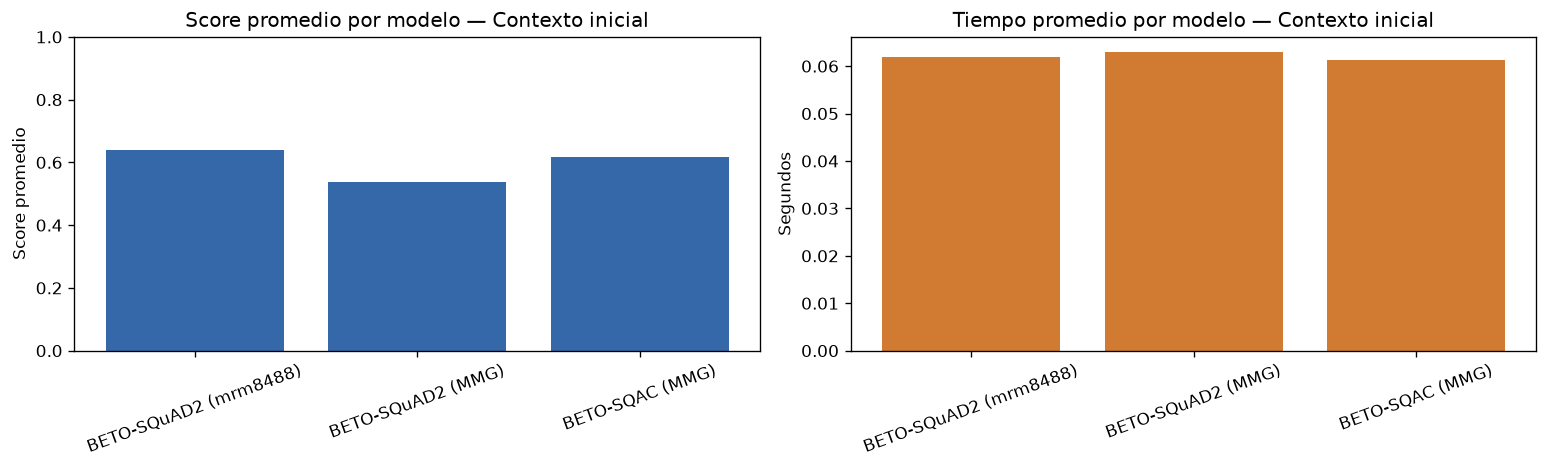

In [51]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 4))

ejes[0].bar(
    resumen_comparacion_inicial["Modelo"],
    resumen_comparacion_inicial["Score promedio"],
    color="#3568a8"
)
ejes[0].set_ylim(0, 1)
ejes[0].set_ylabel("Score promedio")
ejes[0].set_title("Score promedio por modelo — Contexto inicial")
ejes[0].tick_params(axis="x", rotation=20)

ejes[1].bar(
    resumen_comparacion_inicial["Modelo"],
    resumen_comparacion_inicial["Tiempo promedio (s)"],
    color="#d07a32"
)
ejes[1].set_ylabel("Segundos")
ejes[1].set_title("Tiempo promedio por modelo — Contexto inicial")
ejes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


In [52]:
tabla_ventajas_modelos = ventajas_desventajas_observadas(
    resumen_comparacion_inicial
)
display(tabla_ventajas_modelos)


Modelo,Ventajas observadas,Desventajas observadas
BETO-SQuAD2 (mrm8488),mayor score promedio,menos respuestas correctas
BETO-SQuAD2 (MMG),mayor cantidad de respuestas correctas; mayor cantidad de spans exactos,menor score promedio; mayor tiempo promedio
BETO-SQAC (MMG),mayor cantidad de respuestas correctas; menor tiempo promedio,sin desventaja dominante en esta muestra


### 8.11 Análisis y modelo recomendado

- **BETO-SQuAD2 (mrm8488)**: 4/5 correctas, score promedio `0.6400` y tiempo promedio `0.0620 s`.
- **BETO-SQuAD2 (MMG)**: 5/5 correctas, score promedio `0.5369` y tiempo promedio `0.0630 s`.
- **BETO-SQAC (MMG)**: 5/5 correctas, score promedio `0.6158` y tiempo promedio `0.0612 s`.

El modelo mrm8488 dejó incompleta la misión al omitir docencia, investigación y proyección social; además, dos modelos extrajeron «Ingeniería y Arquitectura» sin la palabra «Facultad», caso aceptado mediante la revisión manual explícita porque conserva el nombre solicitado.

La tabla de ventajas y desventajas se deriva de respuestas correctas, spans exactos, score y latencia medidos. Bajo el criterio jerárquico de correctas, exactas, score y tiempo, el modelo recomendado para esta muestra es **BETO-SQuAD2 (MMG)**. La elección no depende únicamente del mayor score: prioriza primero la calidad de las cinco respuestas y la estabilidad de los spans; la latencia se utiliza como criterio posterior.


### 8.12 Extensión con segundo contexto

La repetición solicitada se desarrolla y ejecuta en la **sección 9**, utilizando un contexto propio sobre Bases de Datos y Sistemas Gestores de Bases de Datos.


### 8.13 Extensión con Wikipedia

La prueba con un artículo en español se desarrolla y ejecuta en la **sección 10**, con un extracto autocontenido de Wikipedia.


### 8.14 Ventajas y desventajas

La tabla se genera en la sección 8.11 a partir de correctas, spans exactos, score promedio y tiempo promedio medidos.


### 8.15 Preguntas de reflexión

1. ¿Qué modelo obtuvo la mayor confianza?

2. ¿Cuál respondió más rápido?

3. ¿Cuál recomendaría para documentos en español?

4. ¿Qué características debe tener un buen modelo QA?

### 8.16 Resumen del bloque

En este bloque aprendimos a:

- Comparar distintos modelos de Question Answering.
- Medir el tiempo de inferencia.
- Analizar el nivel de confianza.
- Evaluar precisión y velocidad.
- Interpretar las fortalezas y limitaciones de cada modelo.

En el siguiente bloque construiremos un **proyecto integrador**, desarrollando un sistema de Question Answering sobre documentos extensos y aplicando técnicas para manejar contextos que exceden la longitud máxima admitida por los modelos Transformer.

## 9. Segundo contexto — Bases de Datos y SGBD

**Objetivo.** Repetir la comparación de los tres modelos en un dominio técnico diferente, manteniendo la misma metodología, hardware, `top_k=1` y medición exclusiva del tiempo de inferencia.


In [53]:
contexto_bases_datos = """
Una base de datos es una colección organizada de información que permite conservar y recuperar datos de manera eficiente. En un sistema informático, los datos no se administran únicamente como archivos aislados: normalmente se utiliza un Sistema Gestor de Bases de Datos (SGBD), que es un sistema de software que permite definir, almacenar, consultar y administrar la información. El SGBD también controla el acceso de los usuarios y ayuda a mantener la disponibilidad de los datos.

El modelo relacional organiza la información en tablas formadas por filas, también llamadas registros, y columnas que representan atributos. Cada tabla describe un tipo de entidad, por ejemplo estudiantes, asignaturas o matrículas. Una clave primaria identifica de manera única cada registro de una tabla, mientras que una clave foránea establece una relación con la clave primaria de otra tabla. Estas relaciones permiten conectar información sin repetirla innecesariamente.

SQL es el lenguaje empleado para crear estructuras, insertar o modificar datos y formular consultas en muchos sistemas relacionales. Las restricciones definidas mediante SQL contribuyen a la integridad, porque impiden valores inválidos o referencias hacia registros inexistentes. La integridad no depende solamente de la sintaxis de una consulta; requiere reglas coherentes con el significado de la información almacenada.

Cuando varios usuarios trabajan al mismo tiempo, el SGBD debe gestionar la concurrencia para evitar interferencias entre operaciones. Las modificaciones relacionadas se agrupan en transacciones. Una transacción confiable busca cumplir cuatro propiedades: atomicidad, consistencia, aislamiento y durabilidad. La atomicidad exige que todas sus operaciones se completen o que ninguna quede aplicada; el aislamiento reduce conflictos entre transacciones concurrentes y la durabilidad conserva los cambios confirmados incluso después de una falla.

El diseño de una base de datos debe considerar las consultas esperadas, el volumen de información, la seguridad y las necesidades de recuperación. Un esquema bien diseñado favorece la consistencia y facilita el mantenimiento, pero también debe evaluarse con cargas reales para asegurar que índices, relaciones y consultas ofrecen un rendimiento adecuado.
""".strip()

cantidad_palabras_bases_datos = len(contexto_bases_datos.split())
print(f"Palabras del segundo contexto: {cantidad_palabras_bases_datos}")


Palabras del segundo contexto: 323


In [54]:
preguntas_bases_datos = [
    {
        "numero": 1,
        "dificultad": "Fácil",
        "pregunta": "¿Qué es un Sistema Gestor de Bases de Datos?",
        "respuesta_esperada": "un sistema de software que permite definir, almacenar, consultar y administrar la información"
    },
    {
        "numero": 2,
        "dificultad": "Fácil",
        "pregunta": "¿Cómo organiza la información el modelo relacional?",
        "respuesta_esperada": "en tablas formadas por filas, también llamadas registros, y columnas"
    },
    {
        "numero": 3,
        "dificultad": "Intermedia",
        "pregunta": "¿Cuál es la función de una clave primaria?",
        "respuesta_esperada": "identifica de manera única cada registro de una tabla"
    },
    {
        "numero": 4,
        "dificultad": "Intermedia",
        "pregunta": "¿Qué relación establece una clave foránea?",
        "respuesta_esperada": "una relación con la clave primaria de otra tabla"
    },
    {
        "numero": 5,
        "dificultad": "Difícil",
        "pregunta": "¿Cuáles son las cuatro propiedades de una transacción confiable?",
        "respuesta_esperada": "atomicidad, consistencia, aislamiento y durabilidad"
    }
]

assert len(preguntas_bases_datos) >= 5
print(f"Preguntas del segundo contexto: {len(preguntas_bases_datos)}")


Preguntas del segundo contexto: 5


In [55]:
resultados_bases_datos, cargas_bases_datos = evaluar_modelos(
    modelos,
    contexto_bases_datos,
    preguntas_bases_datos,
    nombre_contexto="Bases de datos y SGBD",
    revisiones_manuales={4: ["clave primaria de otra tabla"]}
)
resumen_bases_datos = resumir_resultados(resultados_bases_datos)
print(f"Resultados generados: {len(resultados_bases_datos)}")


Resultados generados: 15


In [56]:
display(resultados_bases_datos.style.format({
    "Score": "{:.6f}",
    "Tiempo de inferencia (s)": "{:.4f}"
}))
display(resumen_bases_datos.style.format({
    "Score promedio": "{:.6f}",
    "Score mediano": "{:.6f}",
    "Tiempo promedio (s)": "{:.4f}"
}))
display(cargas_bases_datos.style.format({"Tiempo de carga (s)": "{:.3f}"}))


,Contexto,Modelo,#,Dificultad,Pregunta,Esperada,Respuesta,Score,Tiempo de inferencia (s),Correcta,Tipo de coincidencia,Observación
0,Bases de datos y SGBD,BETO-SQuAD2 (mrm8488),1,Fácil,¿Qué es un Sistema Gestor de Bases de Datos?,"un sistema de software que permite definir, almacenar, consultar y administrar la información",un sistema de [UNK],0.135415,0.1811,No,Respuesta incorrecta o no relacionada,Respuesta incorrecta o no relacionada; score bajo.
1,Bases de datos y SGBD,BETO-SQuAD2 (mrm8488),2,Fácil,¿Cómo organiza la información el modelo relacional?,"en tablas formadas por filas, también llamadas registros, y columnas","tablas formadas por filas, tambien llamadas registros, y columnas que representan atributos",0.313617,0.1845,Sí,Variante textual correcta,Variante textual correcta; score bajo.
2,Bases de datos y SGBD,BETO-SQuAD2 (mrm8488),3,Intermedia,¿Cuál es la función de una clave primaria?,identifica de manera única cada registro de una tabla,identifica de manera unica cada registro de una tabla,0.538458,0.1811,Sí,Respuesta exacta tras normalización,Respuesta exacta tras normalización; score medio.
3,Bases de datos y SGBD,BETO-SQuAD2 (mrm8488),4,Intermedia,¿Qué relación establece una clave foránea?,una relación con la clave primaria de otra tabla,la clave primaria de otra tabla,0.306922,0.1843,Sí,Respuesta correcta por revisión manual explícita,Respuesta correcta por revisión manual explícita; score bajo.
4,Bases de datos y SGBD,BETO-SQuAD2 (mrm8488),5,Difícil,¿Cuáles son las cuatro propiedades de una transacción confiable?,"atomicidad, consistencia, aislamiento y durabilidad","atomicidad, consistencia, aislamiento y durabilidad",0.888957,0.1857,Sí,Respuesta exacta tras normalización,Respuesta exacta tras normalización; score alto.
5,Bases de datos y SGBD,BETO-SQuAD2 (MMG),1,Fácil,¿Qué es un Sistema Gestor de Bases de Datos?,"un sistema de software que permite definir, almacenar, consultar y administrar la información","un sistema de software que permite definir, almacenar, consultar y administrar la información",0.220334,0.1778,Sí,Respuesta exacta tras normalización,Respuesta exacta tras normalización; score bajo.
6,Bases de datos y SGBD,BETO-SQuAD2 (MMG),2,Fácil,¿Cómo organiza la información el modelo relacional?,"en tablas formadas por filas, también llamadas registros, y columnas",tablas formadas por filas,0.244851,0.1783,No,Respuesta incorrecta o no relacionada,Respuesta incorrecta o no relacionada; score bajo.
7,Bases de datos y SGBD,BETO-SQuAD2 (MMG),3,Intermedia,¿Cuál es la función de una clave primaria?,identifica de manera única cada registro de una tabla,"identifica de manera única cada registro de una tabla, mientras que una clave foránea establece una relación con la clave primaria de otra tabla. Estas relaciones permiten conectar información sin repetirla innecesariamente",0.168835,0.1757,Sí,Respuesta correcta dentro de un fragmento más amplio,Respuesta correcta dentro de un fragmento más amplio; score bajo.
8,Bases de datos y SGBD,BETO-SQuAD2 (MMG),4,Intermedia,¿Qué relación establece una clave foránea?,una relación con la clave primaria de otra tabla,clave primaria de otra tabla,0.348627,0.1784,Sí,Respuesta correcta por revisión manual explícita,Respuesta correcta por revisión manual explícita; score bajo.
9,Bases de datos y SGBD,BETO-SQuAD2 (MMG),5,Difícil,¿Cuáles son las cuatro propiedades de una transacción confiable?,"atomicidad, consistencia, aislamiento y durabilidad","atomicidad, consistencia, aislamiento y durabilidad",0.665683,0.1767,Sí,Respuesta exacta tras normalización,Respuesta exacta tras normalización; score medio.


,Modelo,Correctas,Total,Exactas,Score promedio,Score mediano,Tiempo promedio (s)
0,BETO-SQuAD2 (mrm8488),4,5,2,0.436674,0.313617,0.1833
1,BETO-SQuAD2 (MMG),4,5,2,0.329666,0.244851,0.1774
2,BETO-SQAC (MMG),5,5,3,0.778458,0.948594,0.1818


,Contexto,Modelo,Tiempo de carga (s),Dispositivo
0,Bases de datos y SGBD,BETO-SQuAD2 (mrm8488),0.224,CPU
1,Bases de datos y SGBD,BETO-SQuAD2 (MMG),0.067,CPU
2,Bases de datos y SGBD,BETO-SQAC (MMG),0.066,CPU


### 9.1 Análisis del segundo contexto

El contexto contiene **323 palabras** y cinco preguntas de dificultad variada. Los resultados fueron:

- **BETO-SQuAD2 (mrm8488)**: 4/5 correctas, score promedio `0.4367` y tiempo promedio `0.1833 s`.
- **BETO-SQuAD2 (MMG)**: 4/5 correctas, score promedio `0.3297` y tiempo promedio `0.1774 s`.
- **BETO-SQAC (MMG)**: 5/5 correctas, score promedio `0.7785` y tiempo promedio `0.1818 s`.

El modelo mrm8488 falló la definición del SGBD al producir «un sistema de [UNK]», mientras que BETO-SQuAD2 (MMG) extrajo solo «tablas formadas por filas» en la pregunta del modelo relacional. Las tres respuestas sobre clave foránea conservaron el núcleo «clave primaria de otra tabla» y quedaron señaladas como revisiones manuales explícitas.

El modelo mejor clasificado en este dominio es **BETO-SQAC (MMG)**. No coincide con el ganador del contexto inicial. Las diferencias de score y tiempo demuestran que el dominio y la formulación modifican la confianza y la latencia, aunque todos los modelos recibieron exactamente las mismas entradas y condiciones.


## 10. Wikipedia en español — Aprendizaje automático

**Título:** Aprendizaje automático  
**Fuente:** Wikipedia en español  
**URL:** https://es.wikipedia.org/wiki/Aprendizaje_autom%C3%A1tico  
**Fecha de consulta:** 11 de agosto de 2026

Para evitar dependencia de Internet durante la entrega, el notebook conserva un extracto adaptado y autocontenido de la introducción y de la sección sobre tipos de algoritmos. No se procesa el artículo completo porque los documentos extensos corresponden a una fase posterior.


In [57]:
contexto_wikipedia = """
El aprendizaje automático es un subcampo de las ciencias de la computación y una rama de la inteligencia artificial. Su objetivo es desarrollar técnicas que permitan que las computadoras aprendan. Se considera que un agente aprende cuando su desempeño mejora con la experiencia y mediante el uso de datos. En este proceso, una computadora observa datos, construye un modelo y utiliza ese modelo para resolver problemas.

El campo se relaciona con la estadística inferencial y el reconocimiento de patrones, aunque también considera la complejidad computacional de los problemas. Entre sus aplicaciones se encuentran los motores de búsqueda, los diagnósticos médicos, la detección de fraude con tarjetas de crédito, el reconocimiento del habla y la robótica.

Los algoritmos pueden organizarse según la información disponible. En el aprendizaje supervisado, el algoritmo establece una correspondencia entre entradas y salidas deseadas usando ejemplos etiquetados; la clasificación es una tarea representativa. En el aprendizaje no supervisado, el sistema debe reconocer patrones en ejemplos que solo contienen entradas, porque no dispone de categorías conocidas. En el aprendizaje por refuerzo, la información de entrada es la retroalimentación que recibe como respuesta a sus acciones, de modo que el sistema aprende mediante ensayo y error.
""".strip()

print(f"Palabras del extracto adaptado: {len(contexto_wikipedia.split())}")


Palabras del extracto adaptado: 197


In [58]:
preguntas_wikipedia = [
    {
        "numero": 1,
        "dificultad": "Fácil",
        "pregunta": "¿Cuál es el objetivo del aprendizaje automático?",
        "respuesta_esperada": "desarrollar técnicas que permitan que las computadoras aprendan"
    },
    {
        "numero": 2,
        "dificultad": "Intermedia",
        "pregunta": "¿Cuándo se considera que un agente aprende?",
        "respuesta_esperada": "cuando su desempeño mejora con la experiencia y mediante el uso de datos"
    },
    {
        "numero": 3,
        "dificultad": "Intermedia",
        "pregunta": "¿Qué establece un algoritmo de aprendizaje supervisado?",
        "respuesta_esperada": "una correspondencia entre entradas y salidas deseadas"
    },
    {
        "numero": 4,
        "dificultad": "Difícil",
        "pregunta": "¿Qué debe hacer el sistema en el aprendizaje no supervisado?",
        "respuesta_esperada": "reconocer patrones en ejemplos que solo contienen entradas"
    },
    {
        "numero": 5,
        "dificultad": "Intermedia",
        "pregunta": "¿Qué información de entrada utiliza el aprendizaje por refuerzo?",
        "respuesta_esperada": "la retroalimentación que recibe como respuesta a sus acciones"
    }
]

assert len(preguntas_wikipedia) == 5, "Wikipedia debe tener exactamente cinco preguntas."
print(f"Preguntas de Wikipedia: {len(preguntas_wikipedia)}")


Preguntas de Wikipedia: 5


In [59]:
resultados_wikipedia, cargas_wikipedia = evaluar_modelos(
    modelos,
    contexto_wikipedia,
    preguntas_wikipedia,
    nombre_contexto="Wikipedia: Aprendizaje automático"
)
resumen_wikipedia = resumir_resultados(resultados_wikipedia)
print(f"Resultados de Wikipedia: {len(resultados_wikipedia)}")
assert len(resultados_wikipedia) == 15


Resultados de Wikipedia: 15


In [60]:
display(resultados_wikipedia.style.format({
    "Score": "{:.6f}",
    "Tiempo de inferencia (s)": "{:.4f}"
}))
display(resumen_wikipedia.style.format({
    "Score promedio": "{:.6f}",
    "Score mediano": "{:.6f}",
    "Tiempo promedio (s)": "{:.4f}"
}))
display(cargas_wikipedia.style.format({"Tiempo de carga (s)": "{:.3f}"}))


,Contexto,Modelo,#,Dificultad,Pregunta,Esperada,Respuesta,Score,Tiempo de inferencia (s),Correcta,Tipo de coincidencia,Observación
0,Wikipedia: Aprendizaje automático,BETO-SQuAD2 (mrm8488),1,Fácil,¿Cuál es el objetivo del aprendizaje automático?,desarrollar técnicas que permitan que las computadoras aprendan,desarrollar tecnicas que permitan que las computadoras aprendan,0.724164,0.1180,Sí,Respuesta exacta tras normalización,Respuesta exacta tras normalización; score medio.
1,Wikipedia: Aprendizaje automático,BETO-SQuAD2 (mrm8488),2,Intermedia,¿Cuándo se considera que un agente aprende?,cuando su desempeño mejora con la experiencia y mediante el uso de datos,cuando su desempeno mejora con la experiencia y mediante el uso de datos,0.791213,0.1200,Sí,Respuesta exacta tras normalización,Respuesta exacta tras normalización; score alto.
2,Wikipedia: Aprendizaje automático,BETO-SQuAD2 (mrm8488),3,Intermedia,¿Qué establece un algoritmo de aprendizaje supervisado?,una correspondencia entre entradas y salidas deseadas,una correspondencia entre entradas y salidas deseadas,0.388184,0.1187,Sí,Respuesta exacta tras normalización,Respuesta exacta tras normalización; score bajo.
3,Wikipedia: Aprendizaje automático,BETO-SQuAD2 (mrm8488),4,Difícil,¿Qué debe hacer el sistema en el aprendizaje no supervisado?,reconocer patrones en ejemplos que solo contienen entradas,reconocer patrones en ejemplos que solo contienen entradas,0.491333,0.1198,Sí,Respuesta exacta tras normalización,Respuesta exacta tras normalización; score medio.
4,Wikipedia: Aprendizaje automático,BETO-SQuAD2 (mrm8488),5,Intermedia,¿Qué información de entrada utiliza el aprendizaje por refuerzo?,la retroalimentación que recibe como respuesta a sus acciones,retroalimentacion que recibe como respuesta a sus acciones,0.339729,0.1194,Sí,Variante textual correcta,Variante textual correcta; score bajo.
5,Wikipedia: Aprendizaje automático,BETO-SQuAD2 (MMG),1,Fácil,¿Cuál es el objetivo del aprendizaje automático?,desarrollar técnicas que permitan que las computadoras aprendan,desarrollar técnicas que permitan que las computadoras aprendan,0.494687,0.0972,Sí,Respuesta exacta tras normalización,Respuesta exacta tras normalización; score medio.
6,Wikipedia: Aprendizaje automático,BETO-SQuAD2 (MMG),2,Intermedia,¿Cuándo se considera que un agente aprende?,cuando su desempeño mejora con la experiencia y mediante el uso de datos,cuando su desempeño mejora con la experiencia y mediante el uso de datos,0.750243,0.1001,Sí,Respuesta exacta tras normalización,Respuesta exacta tras normalización; score alto.
7,Wikipedia: Aprendizaje automático,BETO-SQuAD2 (MMG),3,Intermedia,¿Qué establece un algoritmo de aprendizaje supervisado?,una correspondencia entre entradas y salidas deseadas,una correspondencia entre entradas y salidas deseadas,0.162818,0.0993,Sí,Respuesta exacta tras normalización,Respuesta exacta tras normalización; score bajo.
8,Wikipedia: Aprendizaje automático,BETO-SQuAD2 (MMG),4,Difícil,¿Qué debe hacer el sistema en el aprendizaje no supervisado?,reconocer patrones en ejemplos que solo contienen entradas,reconocer patrones en ejemplos que solo contienen entradas,0.347432,0.0997,Sí,Respuesta exacta tras normalización,Respuesta exacta tras normalización; score bajo.
9,Wikipedia: Aprendizaje automático,BETO-SQuAD2 (MMG),5,Intermedia,¿Qué información de entrada utiliza el aprendizaje por refuerzo?,la retroalimentación que recibe como respuesta a sus acciones,retroalimentación,0.285649,0.0999,No,Respuesta incorrecta o no relacionada,Respuesta incorrecta o no relacionada; score bajo.


,Modelo,Correctas,Total,Exactas,Score promedio,Score mediano,Tiempo promedio (s)
0,BETO-SQuAD2 (mrm8488),5,5,4,0.546924,0.491333,0.1192
1,BETO-SQuAD2 (MMG),4,5,4,0.408166,0.347432,0.0992
2,BETO-SQAC (MMG),5,5,4,0.681568,0.588249,0.1033


,Contexto,Modelo,Tiempo de carga (s),Dispositivo
0,Wikipedia: Aprendizaje automático,BETO-SQuAD2 (mrm8488),0.192,CPU
1,Wikipedia: Aprendizaje automático,BETO-SQuAD2 (MMG),0.064,CPU
2,Wikipedia: Aprendizaje automático,BETO-SQAC (MMG),0.064,CPU


### 10.1 Análisis de Wikipedia

Se obtuvieron exactamente **15 resultados** (cinco preguntas por tres modelos):

- **BETO-SQuAD2 (mrm8488)**: 5/5 correctas, score promedio `0.5469` y tiempo promedio `0.1192 s`.
- **BETO-SQuAD2 (MMG)**: 4/5 correctas, score promedio `0.4082` y tiempo promedio `0.0992 s`.
- **BETO-SQAC (MMG)**: 5/5 correctas, score promedio `0.6816` y tiempo promedio `0.1033 s`.

El modelo mejor clasificado fue **BETO-SQAC (MMG)**. Los errores se concentraron en P5. Las diferencias entre respuestas exactas, spans más amplios o parciales están documentadas en la columna «Tipo de coincidencia». El error de P5 corresponde a BETO-SQuAD2 (MMG), que devolvió únicamente «retroalimentación»: un span demasiado corto para la respuesta esperada. En P3, BETO-SQAC (MMG) conservó la respuesta correcta pero añadió la referencia a ejemplos etiquetados y clasificación, por lo que produjo un span más amplio.

Frente al contexto inicial de la UES y al de bases de datos, el extracto adaptado de Wikipedia produjo un comportamiento diferente en scores y tiempos, por lo que la confianza no debe extrapolarse de un dominio a otro.


## 11. Comparación global de modelos QA

Se integran los resultados del contexto inicial de la UES, el contexto técnico de bases de datos y el extracto adaptado de Wikipedia.


In [61]:
tabla_global_modelos = pd.concat(
    [
        resumen_comparacion_inicial.assign(Contexto="Contexto inicial UES"),
        resumen_bases_datos.assign(Contexto="Bases de datos y SGBD"),
        resumen_wikipedia.assign(Contexto="Wikipedia: Aprendizaje automático")
    ],
    ignore_index=True
)[[
    "Modelo", "Contexto", "Correctas", "Total", "Exactas",
    "Score promedio", "Score mediano", "Tiempo promedio (s)"
]]

resumen_global_modelos = (
    tabla_global_modelos.groupby("Modelo", as_index=False, sort=False)
    .agg(
        Correctas_totales=("Correctas", "sum"),
        Preguntas_totales=("Total", "sum"),
        Exactas_totales=("Exactas", "sum"),
        Score_promedio_global=("Score promedio", "mean"),
        Tiempo_promedio_global=("Tiempo promedio (s)", "mean")
    )
)

ranking_global = resumen_global_modelos.sort_values(
    [
        "Correctas_totales", "Exactas_totales",
        "Score_promedio_global", "Tiempo_promedio_global"
    ],
    ascending=[False, False, False, True]
).reset_index(drop=True)
modelo_seleccionado = ranking_global.iloc[0]["Modelo"]

display(tabla_global_modelos.style.format({
    "Score promedio": "{:.6f}",
    "Score mediano": "{:.6f}",
    "Tiempo promedio (s)": "{:.4f}"
}))
display(resumen_global_modelos.style.format({
    "Score_promedio_global": "{:.6f}",
    "Tiempo_promedio_global": "{:.4f}"
}))
print("Modelo seleccionado:", modelo_seleccionado)


Modelo seleccionado: BETO-SQAC (MMG)


,Modelo,Contexto,Correctas,Total,Exactas,Score promedio,Score mediano,Tiempo promedio (s)
0,BETO-SQuAD2 (mrm8488),Contexto inicial UES,4,5,3,0.639995,0.506616,0.0620
1,BETO-SQuAD2 (MMG),Contexto inicial UES,5,5,5,0.536869,0.431322,0.0630
2,BETO-SQAC (MMG),Contexto inicial UES,5,5,2,0.615832,0.660367,0.0612
3,BETO-SQuAD2 (mrm8488),Bases de datos y SGBD,4,5,2,0.436674,0.313617,0.1833
4,BETO-SQuAD2 (MMG),Bases de datos y SGBD,4,5,2,0.329666,0.244851,0.1774
5,BETO-SQAC (MMG),Bases de datos y SGBD,5,5,3,0.778458,0.948594,0.1818
6,BETO-SQuAD2 (mrm8488),Wikipedia: Aprendizaje automático,5,5,4,0.546924,0.491333,0.1192
7,BETO-SQuAD2 (MMG),Wikipedia: Aprendizaje automático,4,5,4,0.408166,0.347432,0.0992
8,BETO-SQAC (MMG),Wikipedia: Aprendizaje automático,5,5,4,0.681568,0.588249,0.1033


,Modelo,Correctas_totales,Preguntas_totales,Exactas_totales,Score_promedio_global,Tiempo_promedio_global
0,BETO-SQuAD2 (mrm8488),13,15,9,0.541198,0.1215
1,BETO-SQuAD2 (MMG),13,15,11,0.424900,0.1132
2,BETO-SQAC (MMG),15,15,9,0.691953,0.1154


### 11.1 Modelo seleccionado para las siguientes fases

Los ganadores por contexto fueron: **BETO-SQuAD2 (MMG)** en el contexto inicial, **BETO-SQAC (MMG)** en bases de datos y **BETO-SQAC (MMG)** en Wikipedia. El ganador cambió entre contextos.

El modelo seleccionado para documentos extensos, *chunking* y RAG es **BETO-SQAC (MMG)**. En el acumulado obtuvo **15/15 respuestas correctas**, 9 spans exactos, score promedio global `0.6920` y tiempo promedio `0.1154 s`. Esta selección prioriza correctas y estabilidad de extracción antes que score o velocidad aislados.


## 12. Documento PDF real y Question Answering sobre documentos extensos

### 12.1 Fase 7 — Documento fuente

Se utiliza el **Reglamento de la Gestión Académico-Administrativa de la Universidad de El Salvador**, un documento institucional con contenido factual y estructura por títulos, capítulos y artículos. Sus 62 páginas permiten formular preguntas distribuidas a lo largo del texto y reutilizar la misma fuente en la fase posterior de RAG.

La fuente oficial se conserva en `data/documento_fuente.pdf`. El código usa únicamente esa ruta relativa, resuelta desde la raíz del repositorio.


In [110]:
from pathlib import Path
import gc
import json
import re
import time

import matplotlib.pyplot as plt
import pandas as pd
import pymupdf
import torch


def localizar_raiz_laboratorio():
    """Localiza la raíz sin depender de una ruta absoluta."""
    actual = Path.cwd().resolve()
    candidatas = [actual, *actual.parents, actual / "Repo" / "Laboratorio---ML"]
    for candidata in candidatas:
        carpeta_data = candidata / "data"
        if (carpeta_data / "documento_fuente.pdf").exists():
            return candidata
    raise FileNotFoundError("No se encontró data/documento_fuente.pdf.")


ROOT = localizar_raiz_laboratorio()
PDF_PATH = ROOT / "data" / "documento_fuente.pdf"

assert PDF_PATH.exists(), "No se encontró el documento fuente oficial."

metadatos_fuente = pd.DataFrame([{
    "Nombre": "Reglamento de la Gestión Académico-Administrativa de la UES",
    "Temática": "Gestión académica y administrativa universitaria",
    "Razón de selección": "Documento institucional extenso, factual y con texto seleccionable",
    "Ruta relativa": PDF_PATH.relative_to(ROOT).as_posix(),
    "Tamaño (KiB)": PDF_PATH.stat().st_size / 1024,
}])
display(metadatos_fuente.style.format({"Tamaño (KiB)": "{:.1f}"}))


,Nombre,Temática,Razón de selección,Ruta relativa,Tamaño (KiB)
0,Reglamento de la Gestión Académico-Administrativa de la UES,Gestión académica y administrativa universitaria,"Documento institucional extenso, factual y con texto seleccionable",data/documento_fuente.pdf,486.1


In [111]:
def limpiar_texto_pagina(texto):
    """Aplica limpieza conservadora sin resumir ni reescribir contenido."""
    texto = texto.replace("\u00ad", "")
    texto = re.sub(r"(?<=\w)-\s*\n\s*(?=\w)", "", texto)
    texto = re.sub(r"\s+", " ", texto)
    return texto.strip()


paginas_documento = []
with pymupdf.open(PDF_PATH) as pdf:
    numero_paginas_pdf = pdf.page_count
    metadatos_pdf = dict(pdf.metadata)
    for numero_pagina, pagina in enumerate(pdf, start=1):
        texto_crudo = pagina.get_text("text")
        texto_limpio = limpiar_texto_pagina(texto_crudo)
        paginas_documento.append({
            "pagina": numero_pagina,
            "texto_crudo": texto_crudo,
            "texto": texto_limpio,
        })

desplazamiento = 0
for registro_pagina in paginas_documento:
    registro_pagina["inicio"] = desplazamiento
    desplazamiento += len(registro_pagina["texto"])
    registro_pagina["fin"] = desplazamiento
    desplazamiento += 2  # Separación real usada al unir páginas.

texto_documento = "\n\n".join(
    registro["texto"] for registro in paginas_documento
)


def pagina_de_posicion(posicion):
    """Convierte una posición del texto unido en número físico de página."""
    for registro in paginas_documento:
        if registro["inicio"] <= posicion <= registro["fin"]:
            return registro["pagina"]
    return paginas_documento[-1]["pagina"]


paginas_con_texto = [
    registro["pagina"] for registro in paginas_documento
    if registro["texto"].strip()
]
paginas_sin_texto = [
    registro["pagina"] for registro in paginas_documento
    if not registro["texto"].strip()
]
paginas_extraccion_corta = [
    registro["pagina"] for registro in paginas_documento
    if 0 < len(registro["texto"]) < 200
]
tamano_archivo_bytes = PDF_PATH.stat().st_size
estadisticas_documento = {
    "Páginas": numero_paginas_pdf,
    "Caracteres crudos": sum(len(p["texto_crudo"]) for p in paginas_documento),
    "Caracteres limpios": len(texto_documento),
    "Palabras aproximadas": len(texto_documento.split()),
    "Páginas con texto": len(paginas_con_texto),
    "Páginas sin texto": len(paginas_sin_texto),
    "Páginas con extracción corta (<200 caracteres)": len(paginas_extraccion_corta),
    "Tamaño del archivo (bytes)": tamano_archivo_bytes,
    "Tamaño del archivo (MiB)": tamano_archivo_bytes / (1024 ** 2),
}

assert numero_paginas_pdf == 62
assert len(paginas_con_texto) == numero_paginas_pdf
assert not paginas_sin_texto
assert not paginas_extraccion_corta
assert len(texto_documento) > 100_000



In [112]:
tabla_estadisticas_documento = pd.DataFrame(
    estadisticas_documento.items(),
    columns=["Métrica", "Valor"],
)
display(tabla_estadisticas_documento)

print(f"Título PDF: {metadatos_pdf.get('title') or 'No especificado'}")
print(f"Autor PDF: {metadatos_pdf.get('author') or 'No especificado'}")
print(f"Páginas sin texto: {paginas_sin_texto or 'ninguna'}")


,Métrica,Valor
0,Páginas,62.000000
1,Caracteres crudos,177390.000000
2,Caracteres limpios,173419.000000
3,Palabras aproximadas,26119.000000
4,Páginas con texto,62.000000
5,Páginas sin texto,0.000000
6,Páginas con extracción corta (<200 caracteres),0.000000
7,Tamaño del archivo (bytes),497732.000000
8,Tamaño del archivo (MiB),0.474674


Título PDF: No especificado
Autor PDF: Carolina
Páginas sin texto: ninguna


### 12.2 Extracción, limpieza y verificación

PyMuPDF extrae el texto página por página. La limpieza se limita a retirar guiones producidos por cortes de línea, normalizar espacios y recomponer saltos artificiales; no se resumen artículos ni se sustituyen palabras. Se muestran cuatro muestras breves y no el documento completo.


In [113]:
paginas_muestra = [1, 30, 45, 62]
muestras_texto = pd.DataFrame([
    {
        "Página": numero,
        "Muestra": paginas_documento[numero - 1]["texto"][:360] + "…",
    }
    for numero in paginas_muestra
])
display(muestras_texto)


,Página,Muestra
0,1,"1 ACUERDO N° 106/2011-2013 (V) LA ASAMBLEA GENERAL UNIVERSITARIA DE LA UNIVERSIDAD DE EL SALVADOR. CONSIDERANDO: I. Que el Decreto Legislativo N° 597 del 29 de abril de 1999, publicado en el Diario Oficial No. 96 de fecha 25 de mayo de 1999, fue aprobada la Ley Orgánica de la Universidad de El Salvador. II. De conformidad con los Artículos 3 y 4 de la Ley Or…"
1,30,"30 Artículo 111. Previo al inicio de cada ciclo académico, a los estudiantes que tengan un Coeficiente de Unidades de Mérito acumulado menor a siete punto cero, la Administración Académica de Facultad los someterá a un proceso de asesoría presencial o en línea, el cual orientará al estudiante en relación a la asignación de su carga académica, a fin de mejora…"
2,45,"45 b) En el caso de los Profesorados, haber cumplido con lo establecido en el Reglamento Especial para el Funcionamiento de Carreras y Cursos que Habilitan para el Ejercicio de la Docencia en El Salvador del Ministerio de Educación. La calidad de egresado se adquiere de pleno derecho inmediatamente se cumplan los requisitos señalados en los literales anterio…"
3,62,"62 VIGENCIA. Artículo 258. El presente Reglamento entrará en vigencia ocho días después de su publicación en El Diario Oficial. DADO EN EL SALÓN DE SESIONES DE LA ASAMBLEA GENERAL UNIVERSITARIA DE LA UNIVERSIDAD DE EL SALVADOR. Ciudad Universitaria, San Salvador, a los diecisiete días del mes de mayo de dos mil trece. *MODIFICACIÓN DEL REGLAMENTO, A LOS VEIN…"


### 12.3 Diez preguntas sobre el documento

Las respuestas esperadas son spans explícitos del reglamento. Las preguntas cubren distintas zonas y dificultades. La pregunta 10 usa el artículo 184: la condición y su respuesta se encuentran cerca de límites reales de 500 y 800 caracteres, por lo que permite observar el efecto del solapamiento.


In [114]:
preguntas_documento = [
    {
        "numero": 1,
        "dificultad": "Fácil",
        "pregunta": "¿Con qué periodicidad sesiona ordinariamente el Consejo Académico?",
        "respuesta_esperada": "una vez al mes",
        "articulo": "Artículo 6 (continuación)",
        "pagina_evidencia": 3,
        "fragmento_evidencia": "el Consejo Académico sesionará una vez al mes de forma ordinaria",
    },
    {
        "numero": 2,
        "dificultad": "Fácil",
        "pregunta": "¿Cuál es el máximo de veces que un estudiante puede cambiar de carrera?",
        "respuesta_esperada": "dos veces",
        "articulo": "Articulo 156",
        "pagina_evidencia": 40,
        "fragmento_evidencia": "hasta un máximo de dos veces",
    },
    {
        "numero": 3,
        "dificultad": "Fácil",
        "pregunta": "¿Cuánto dura ordinariamente la calidad de egresado?",
        "respuesta_esperada": "tres años académicos",
        "articulo": "Artículo 184",
        "pagina_evidencia": 45,
        "fragmento_evidencia": "La calidad de egresado tendrá una duración ordinaria de tres años académicos.",
    },
    {
        "numero": 4,
        "dificultad": "Intermedia",
        "pregunta": "¿Qué unidades integran internamente la Secretaría de Asuntos Académicos?",
        "respuesta_esperada": "Administración Académica Central; Unidad Curricular; y Unidad de Ingreso Universitario",
        "evidencias_clave": [
            "Administración Académica Central",
            "Unidad Curricular",
            "Unidad de Ingreso Universitario",
        ],
        "articulo": "Artículo 13",
        "pagina_evidencia": 4,
        "fragmento_evidencia": "a) Administración Académica Central; b) Unidad Curricular; y c) Unidad de Ingreso Universitario.",
    },
    {
        "numero": 5,
        "dificultad": "Intermedia",
        "pregunta": "¿Qué prueba se aplica después del curso de refuerzo académico en línea?",
        "respuesta_esperada": "prueba de conocimiento general",
        "respuestas_aceptables": [
            "Conocimientos Generales",
            "conocimiento general",
        ],
        "evidencias_clave": ["conocimiento general"],
        "articulo": "Artículo 41",
        "pagina_evidencia": 15,
        "fragmento_evidencia": "previo a la aplicación de la prueba de conocimiento general",
    },
    {
        "numero": 6,
        "dificultad": "Intermedia",
        "pregunta": "¿A qué proceso se somete al estudiante con CUM acumulado menor a siete punto cero?",
        "respuesta_esperada": "proceso de asesoría presencial o en línea",
        "articulo": "Artículo 111",
        "pagina_evidencia": 30,
        "fragmento_evidencia": "los someterá a un proceso de asesoría presencial o en línea",
    },
    {
        "numero": 7,
        "dificultad": "Intermedia",
        "pregunta": "¿Quién nombra a los miembros del Tribunal Calificador?",
        "respuesta_esperada": "Junta Directiva",
        "articulo": "Artículo 207",
        "pagina_evidencia": 50,
        "fragmento_evidencia": "serán nombrados por la Junta Directiva",
    },
    {
        "numero": 8,
        "dificultad": "Difícil",
        "pregunta": "¿Según qué reglamento se tramita la selección de ingreso de un aspirante a posgrado?",
        "respuesta_esperada": "Reglamento General del Sistema de Estudios de Posgrado de la Universidad de El Salvador",
        "articulo": "Artículo 68",
        "pagina_evidencia": 20,
        "fragmento_evidencia": "de acuerdo con lo expresado en el Reglamento General del Sistema de Estudios de Posgrado de la Universidad de El Salvador",
    },
    {
        "numero": 9,
        "dificultad": "Difícil",
        "pregunta": "¿Cuándo entra en vigencia el Reglamento?",
        "respuesta_esperada": "ocho días después de su publicación en El Diario Oficial",
        "articulo": "Artículo 258",
        "pagina_evidencia": 62,
        "fragmento_evidencia": "El presente Reglamento entrará en vigencia ocho días después de su publicación en El Diario Oficial.",
    },
    {
        "numero": 10,
        "dificultad": "Límite de fragmento",
        "pregunta": "¿Por cuánto tiempo se amplía automáticamente la calidad de egresado si el plazo vence después de aprobar el trabajo de graduación y antes del acto de graduación?",
        "respuesta_esperada": "un año académico más",
        "articulo": "Artículo 184",
        "pagina_evidencia": 45,
        "fragmento_evidencia": "la calidad de egresado se ampliará automáticamente por un año académico más",
    },
]

assert len(preguntas_documento) == 10
assert [p["dificultad"] for p in preguntas_documento].count("Fácil") == 3
assert [p["dificultad"] for p in preguntas_documento].count("Intermedia") == 4
assert [p["dificultad"] for p in preguntas_documento].count("Difícil") == 2
assert [p["dificultad"] for p in preguntas_documento].count("Límite de fragmento") == 1

for item in preguntas_documento:
    pagina = paginas_documento[item["pagina_evidencia"] - 1]["texto"]
    evidencias = item.get("evidencias_clave", [item["respuesta_esperada"]])
    assert all(
        normalizar_texto(evidencia) in normalizar_texto(pagina)
        for evidencia in evidencias
    ), f"No se encontró la respuesta esperada de la pregunta {item['numero']}."
    assert (
        normalizar_texto(item["fragmento_evidencia"])
        in normalizar_texto(pagina)
    ), f"No se encontró el fragmento de evidencia de la pregunta {item['numero']}."

tabla_preguntas_documento = pd.DataFrame(preguntas_documento)[[
    "numero", "dificultad", "pregunta", "respuesta_esperada",
    "articulo", "pagina_evidencia", "fragmento_evidencia",
]].rename(columns={
    "numero": "#",
    "dificultad": "Dificultad",
    "pregunta": "Pregunta",
    "respuesta_esperada": "Respuesta esperada",
    "articulo": "Artículo",
    "pagina_evidencia": "Página aproximada",
    "fragmento_evidencia": "Fragmento de evidencia",
})
display(tabla_preguntas_documento)


,#,Dificultad,Pregunta,Respuesta esperada,Artículo,Página aproximada,Fragmento de evidencia
0,1,Fácil,¿Con qué periodicidad sesiona ordinariamente el Consejo Académico?,una vez al mes,Artículo 6 (continuación),3,el Consejo Académico sesionará una vez al mes de forma ordinaria
1,2,Fácil,¿Cuál es el máximo de veces que un estudiante puede cambiar de carrera?,dos veces,Articulo 156,40,hasta un máximo de dos veces
2,3,Fácil,¿Cuánto dura ordinariamente la calidad de egresado?,tres años académicos,Artículo 184,45,La calidad de egresado tendrá una duración ordinaria de tres años académicos.
3,4,Intermedia,¿Qué unidades integran internamente la Secretaría de Asuntos Académicos?,Administración Académica Central; Unidad Curricular; y Unidad de Ingreso Universitario,Artículo 13,4,a) Administración Académica Central; b) Unidad Curricular; y c) Unidad de Ingreso Universitario.
4,5,Intermedia,¿Qué prueba se aplica después del curso de refuerzo académico en línea?,prueba de conocimiento general,Artículo 41,15,previo a la aplicación de la prueba de conocimiento general
5,6,Intermedia,¿A qué proceso se somete al estudiante con CUM acumulado menor a siete punto cero?,proceso de asesoría presencial o en línea,Artículo 111,30,los someterá a un proceso de asesoría presencial o en línea
6,7,Intermedia,¿Quién nombra a los miembros del Tribunal Calificador?,Junta Directiva,Artículo 207,50,serán nombrados por la Junta Directiva
7,8,Difícil,¿Según qué reglamento se tramita la selección de ingreso de un aspirante a posgrado?,Reglamento General del Sistema de Estudios de Posgrado de la Universidad de El Salvador,Artículo 68,20,de acuerdo con lo expresado en el Reglamento General del Sistema de Estudios de Posgrado de la Universidad de El Salvador
8,9,Difícil,¿Cuándo entra en vigencia el Reglamento?,ocho días después de su publicación en El Diario Oficial,Artículo 258,62,El presente Reglamento entrará en vigencia ocho días después de su publicación en El Diario Oficial.
9,10,Límite de fragmento,¿Por cuánto tiempo se amplía automáticamente la calidad de egresado si el plazo vence después de aprobar el trabajo de graduación y antes del acto de graduación?,un año académico más,Artículo 184,45,la calidad de egresado se ampliará automáticamente por un año académico más


### 12.4 Fase 8 — Question Answering sobre el documento extenso

BETO recibe como máximo 512 tokens entre pregunta y contexto. El reglamento completo supera ampliamente ese límite, por lo que no puede enviarse en una sola entrada. Un **documento** es la fuente completa; un **fragmento** o *chunk* es una ventana limitada de esa fuente que sí cabe en el modelo.

El chunking se expresa exclusivamente en **caracteres** para conservar la unidad de la implementación existente. Se evalúa cada pregunta sobre todos los chunks y se selecciona el span con mayor score. El score representa confianza del modelo, no accuracy.


In [94]:
def dividir_con_solapamiento(texto, longitud=700, overlap=150, con_metadatos=False):
    """Divide por caracteres; conserva compatibilidad con la demo RAG posterior."""
    if longitud <= 0:
        raise ValueError("longitud debe ser mayor que cero")
    if overlap < 0 or overlap >= longitud:
        raise ValueError("overlap debe cumplir 0 <= overlap < longitud")

    fragmentos = []
    paso = longitud - overlap
    inicio = 0
    indice = 1
    while inicio < len(texto):
        fin = min(inicio + longitud, len(texto))
        contenido = texto[inicio:fin]
        if con_metadatos:
            fragmentos.append({
                "chunk": indice,
                "inicio": inicio,
                "fin": fin,
                "texto": contenido,
            })
        else:
            fragmentos.append(contenido)
        inicio += paso
        indice += 1
    return fragmentos


def dividir_texto(texto, longitud=700):
    """Compatibilidad con la función original: chunking sin overlap."""
    return dividir_con_solapamiento(texto, longitud=longitud, overlap=0)


In [95]:
from transformers import AutoModelForQuestionAnswering, AutoTokenizer

MODELO_QA_DOCUMENTOS = "MMG/bert-base-spanish-wwm-cased-finetuned-sqac"
dispositivo_documentos = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

inicio_carga_documentos = time.perf_counter()
tokenizer_documentos = AutoTokenizer.from_pretrained(MODELO_QA_DOCUMENTOS)
modelo_documentos = AutoModelForQuestionAnswering.from_pretrained(
    MODELO_QA_DOCUMENTOS
)
modelo_documentos.to(dispositivo_documentos)
modelo_documentos.eval()
tiempo_carga_documentos = time.perf_counter() - inicio_carga_documentos

print(f"Modelo seleccionado: {MODELO_QA_DOCUMENTOS}")
print(f"Dispositivo: {dispositivo_documentos}")
print(f"Tiempo de carga separado: {tiempo_carga_documentos:.3f} s")


Modelo seleccionado: MMG/bert-base-spanish-wwm-cased-finetuned-sqac
Dispositivo: cpu
Tiempo de carga separado: 0.185 s


Loading weights: 100%|##########| 199/199 [00:00<00:00, 50272.03it/s]


### 12.5 Configuración base sin solapamiento

La configuración base usa `chunk_size=500` caracteres y `overlap=0`. Este tamaño permanece por debajo del límite del modelo aun al añadir la pregunta; además coincide con una de las configuraciones comparativas de la Fase 9, por lo que sus resultados se reutilizan sin repetir inferencias.


In [96]:
CONFIGURACION_BASE = {"chunk_size": 500, "overlap": 0}
fragmentos_base = dividir_con_solapamiento(
    texto_documento,
    longitud=CONFIGURACION_BASE["chunk_size"],
    overlap=CONFIGURACION_BASE["overlap"],
    con_metadatos=True,
)

longitudes_base = [len(f["texto"]) for f in fragmentos_base]
tokens_base = [
    len(tokenizer_documentos.encode(f["texto"], add_special_tokens=False))
    for f in fragmentos_base
]
estadisticas_fragmentos_base = pd.DataFrame([{
    "Unidad": "caracteres",
    "chunk_size": CONFIGURACION_BASE["chunk_size"],
    "overlap": CONFIGURACION_BASE["overlap"],
    "Nº fragmentos": len(fragmentos_base),
    "Longitud mínima": min(longitudes_base),
    "Longitud máxima": max(longitudes_base),
    "Longitud media": sum(longitudes_base) / len(longitudes_base),
    "Máximo de tokens observado": max(tokens_base),
}])
display(estadisticas_fragmentos_base.style.format({"Longitud media": "{:.1f}"}))

indices_muestra = [0, len(fragmentos_base) // 2, len(fragmentos_base) - 1]
muestra_fragmentos_base = pd.DataFrame([
    {
        "Chunk": fragmentos_base[i]["chunk"],
        "Inicio": fragmentos_base[i]["inicio"],
        "Fin": fragmentos_base[i]["fin"],
        "Muestra": fragmentos_base[i]["texto"][:240] + "…",
    }
    for i in indices_muestra
])
display(muestra_fragmentos_base)


,Unidad,chunk_size,overlap,Nº fragmentos,Longitud mínima,Longitud máxima,Longitud media,Máximo de tokens observado
0,caracteres,500,0,347,419,500,499.8,158


,Chunk,Inicio,Fin,Muestra
0,1,0,500,"1 ACUERDO N° 106/2011-2013 (V) LA ASAMBLEA GENERAL UNIVERSITARIA DE LA UNIVERSIDAD DE EL SALVADOR. CONSIDERANDO: I. Que el Decreto Legislativo N° 597 del 29 de abril de 1999, publicado en el Diario Oficial No. 96 de fecha 25 de mayo de 1999…"
1,174,86500,87000,"estudiante, cuando los motivos para no realizarla, sean la solvencia de pagos de cuotas de escolaridad, para lo cual el estudiante deberá suscribir una carta compromiso, estableciéndose para el pago un plazo máximo de sesenta días calendar…"
2,347,173000,173419,"REGLAMENTO, A LOS VEINTICUATRO DÍAS DEL MES DE FEBRERO DE DOS MIL DIECISIETE, publicado en Diario Oficial 8 de Agosto 2017, vigentes ocho días después de la publicación. Acuerdo 074/2015-2017(IX) Ing. M.Sc. Carlos Armando Villalta Presiden…"


In [97]:
TAMANO_LOTE_QA = 24
MAX_TOKENS_RESPUESTA = 45
CANDIDATOS_SPAN = 12


def inferir_lote_qa(pregunta, lote_fragmentos):
    """Infiere y decodifica un candidato por chunk en un único lote."""
    contextos = [fragmento["texto"] for fragmento in lote_fragmentos]
    codificacion = tokenizer_documentos(
        [pregunta] * len(contextos),
        contextos,
        padding=True,
        truncation="only_second",
        max_length=512,
        return_offsets_mapping=True,
        return_tensors="pt",
    )
    ids_secuencia = [
        codificacion.sequence_ids(indice)
        for indice in range(len(contextos))
    ]
    offsets = codificacion.pop("offset_mapping")
    entradas_modelo = {
        clave: valor.to(dispositivo_documentos)
        for clave, valor in codificacion.items()
    }

    with torch.no_grad():
        salida_modelo = modelo_documentos(**entradas_modelo)

    logits_inicio = salida_modelo.start_logits.detach().cpu()
    logits_fin = salida_modelo.end_logits.detach().cpu()
    respuestas_lote = []

    for fila, contexto in enumerate(contextos):
        mascara_contexto = torch.tensor([
            identificador == 1 for identificador in ids_secuencia[fila]
        ], dtype=torch.bool)
        inicio_mascarado = logits_inicio[fila].masked_fill(
            ~mascara_contexto, -1e9
        )
        fin_mascarado = logits_fin[fila].masked_fill(
            ~mascara_contexto, -1e9
        )
        probabilidades_inicio = torch.softmax(inicio_mascarado, dim=-1)
        probabilidades_fin = torch.softmax(fin_mascarado, dim=-1)

        cantidad_candidatos = min(
            CANDIDATOS_SPAN,
            int(mascara_contexto.sum().item()),
        )
        indices_inicio = torch.topk(
            probabilidades_inicio, cantidad_candidatos
        ).indices.tolist()
        indices_fin = torch.topk(
            probabilidades_fin, cantidad_candidatos
        ).indices.tolist()

        mejor_span = None
        for indice_inicio in indices_inicio:
            for indice_fin in indices_fin:
                longitud_span = indice_fin - indice_inicio + 1
                if not (1 <= longitud_span <= MAX_TOKENS_RESPUESTA):
                    continue
                inicio_caracter = int(offsets[fila, indice_inicio, 0])
                fin_caracter = int(offsets[fila, indice_fin, 1])
                if fin_caracter <= inicio_caracter:
                    continue
                score = float(
                    probabilidades_inicio[indice_inicio]
                    * probabilidades_fin[indice_fin]
                )
                if mejor_span is None or score > mejor_span["score"]:
                    mejor_span = {
                        "answer": contexto[inicio_caracter:fin_caracter].strip(),
                        "score": score,
                    }

        if mejor_span is None:
            mejor_span = {"answer": "", "score": 0.0}
        respuestas_lote.append(mejor_span)

    return respuestas_lote


def evaluar_pregunta_en_fragmentos(item, fragmentos, configuracion):
    """Ejecuta QA sobre todos los chunks y conserva el candidato de mayor score."""
    candidatos = []
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    inicio = time.perf_counter()

    for inicio_lote in range(0, len(fragmentos), TAMANO_LOTE_QA):
        lote_fragmentos = fragmentos[inicio_lote:inicio_lote + TAMANO_LOTE_QA]
        salidas = inferir_lote_qa(item["pregunta"], lote_fragmentos)
        for fragmento, salida in zip(lote_fragmentos, salidas):
            candidatos.append({
                "fragmento": fragmento,
                "answer": salida["answer"],
                "score": float(salida["score"]),
            })

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    tiempo_total = time.perf_counter() - inicio
    mejor = max(candidatos, key=lambda candidato: candidato["score"])
    fragmento_ganador = mejor["fragmento"]

    correcta, detalle = evaluar_coincidencia(
        mejor["answer"],
        item["respuesta_esperada"],
    )
    if not correcta:
        for variante in item.get("respuestas_aceptables", []):
            coincide_variante, _ = evaluar_coincidencia(
                mejor["answer"], variante
            )
            if coincide_variante:
                correcta = True
                detalle = "Respuesta correcta por revisión manual explícita"
                break

    evidencias_clave = item.get(
        "evidencias_clave", [item["respuesta_esperada"]]
    )
    evidencia_en_chunk = all(
        normalizar_texto(evidencia)
        in normalizar_texto(fragmento_ganador["texto"])
        for evidencia in evidencias_clave
    )
    pagina_inicio = pagina_de_posicion(fragmento_ganador["inicio"])
    pagina_fin = pagina_de_posicion(max(fragmento_ganador["fin"] - 1, 0))
    pagina_objetivo_en_chunk = (
        pagina_inicio <= item["pagina_evidencia"] <= pagina_fin
    )

    observacion = (
        f"{detalle}; evidencia esperada "
        f"{'presente' if evidencia_en_chunk else 'no completa'}; página objetivo "
        f"{'incluida' if pagina_objetivo_en_chunk else 'no incluida'} en el chunk ganador."
    )
    return {
        "Configuración": configuracion,
        "#": item["numero"],
        "Dificultad": item["dificultad"],
        "Artículo": item["articulo"],
        "Página objetivo": item["pagina_evidencia"],
        "Pregunta": item["pregunta"],
        "Esperada": item["respuesta_esperada"],
        "Obtenida": mejor["answer"],
        "Score": mejor["score"],
        "Chunk": fragmento_ganador["chunk"],
        "Inicio chunk": fragmento_ganador["inicio"],
        "Fin chunk": fragmento_ganador["fin"],
        "Página chunk": (
            str(pagina_inicio) if pagina_inicio == pagina_fin
            else f"{pagina_inicio}-{pagina_fin}"
        ),
        "Tiempo (s)": tiempo_total,
        "Correcta": "Sí" if correcta else "No",
        "Evidencia en chunk": "Sí" if evidencia_en_chunk else "No",
        "Página objetivo en chunk": "Sí" if pagina_objetivo_en_chunk else "No",
        "Observación": observacion,
    }


def ejecutar_configuracion(nombre, fragmentos, preguntas):
    registros = []
    for item in preguntas:
        resultado = evaluar_pregunta_en_fragmentos(item, fragmentos, nombre)
        registros.append(resultado)
        print(
            f"{nombre} · P{item['numero']}: "
            f"{resultado['Obtenida']!r} · score={resultado['Score']:.4f} · "
            f"{resultado['Tiempo (s)']:.3f} s"
        )
    return pd.DataFrame(registros)


# Calentamiento: no forma parte de los tiempos comparables.
_ = inferir_lote_qa(
    preguntas_documento[0]["pregunta"],
    fragmentos_base[:1],
)


In [98]:
resultados_documento_base = ejecutar_configuracion(
    "C — 500/0",
    fragmentos_base,
    preguntas_documento,
)
assert len(resultados_documento_base) == 10


C — 500/0 · P1: 'cada mes' · score=0.9836 · 18.063 s
C — 500/0 · P2: 'cinco días hábiles' · score=0.9603 · 18.163 s
C — 500/0 · P3: '6 semanas' · score=0.9912 · 20.480 s
C — 500/0 · P4: 'a) Administración Académica Central; b) Unidad Curricular; y c) Unidad de Ingreso Universitario' · score=0.9299 · 23.560 s
C — 500/0 · P5: 'Conocimientos Generales' · score=0.8486 · 23.730 s
C — 500/0 · P6: 'PRUEBA DIFERIDA' · score=0.8121 · 24.223 s
C — 500/0 · P7: 'la Junta Directiva' · score=0.9621 · 22.012 s
C — 500/0 · P8: 'el Reglamento' · score=0.8425 · 22.460 s
C — 500/0 · P9: 'seis meses' · score=0.8602 · 23.378 s
C — 500/0 · P10: 'dos años' · score=0.9811 · 27.735 s


In [115]:
columnas_base = [
    "#", "Artículo", "Página objetivo", "Pregunta", "Esperada", "Obtenida", "Score",
    "Chunk", "Página chunk", "Página objetivo en chunk", "Tiempo (s)",
    "Correcta", "Observación",
]
display(resultados_documento_base[columnas_base].style.format({
    "Score": "{:.6f}",
    "Tiempo (s)": "{:.3f}",
}))


,#,Artículo,Página objetivo,Pregunta,Esperada,Obtenida,Score,Chunk,Página chunk,Página objetivo en chunk,Tiempo (s),Correcta,Observación
0,1,Artículo 6 (continuación),3,¿Con qué periodicidad sesiona ordinariamente el Consejo Académico?,una vez al mes,cada mes,0.983650,62,11,No,18.063,No,Respuesta incorrecta o no relacionada; evidencia esperada no completa en el chunk ganador.
1,2,Articulo 156,40,¿Cuál es el máximo de veces que un estudiante puede cambiar de carrera?,dos veces,cinco días hábiles,0.960329,294,53,No,18.163,No,Respuesta incorrecta o no relacionada; evidencia esperada no completa en el chunk ganador.
2,3,Artículo 184,45,¿Cuánto dura ordinariamente la calidad de egresado?,tres años académicos,6 semanas,0.991154,159,29,No,20.480,No,Respuesta incorrecta o no relacionada; evidencia esperada no completa en el chunk ganador.
3,4,Artículo 13,4,¿Qué unidades integran internamente la Secretaría de Asuntos Académicos?,Administración Académica Central; Unidad Curricular; y Unidad de Ingreso Universitario,a) Administración Académica Central; b) Unidad Curricular; y c) Unidad de Ingreso Universitario,0.929890,21,4-5,Sí,23.560,Sí,Variante textual correcta; contiene las tres unidades y la página objetivo está incluida.
4,5,Artículo 41,15,¿Qué prueba se aplica después del curso de refuerzo académico en línea?,prueba de conocimiento general,Conocimientos Generales,0.848566,82,15,Sí,23.730,Sí,Respuesta correcta por revisión manual explícita; «Conocimientos Generales» conserva el nombre de la prueba y la página objetivo está incluida.
5,6,Artículo 111,30,¿A qué proceso se somete al estudiante con CUM acumulado menor a siete punto cero?,proceso de asesoría presencial o en línea,PRUEBA DIFERIDA,0.812135,85,15,No,24.223,No,Respuesta incorrecta o no relacionada; evidencia esperada no completa en el chunk ganador.
6,7,Artículo 207,50,¿Quién nombra a los miembros del Tribunal Calificador?,Junta Directiva,la Junta Directiva,0.962083,250,45,No,22.012,Sí,"Respuesta textual correcta, pero el chunk ganador no incluye la página objetivo del artículo 207."
7,8,Artículo 68,20,¿Según qué reglamento se tramita la selección de ingreso de un aspirante a posgrado?,Reglamento General del Sistema de Estudios de Posgrado de la Universidad de El Salvador,el Reglamento,0.842513,269,49,No,22.460,No,Respuesta incorrecta o no relacionada; evidencia esperada no completa en el chunk ganador.
8,9,Artículo 258,62,¿Cuándo entra en vigencia el Reglamento?,ocho días después de su publicación en El Diario Oficial,seis meses,0.860174,284,51,No,23.378,No,Respuesta incorrecta o no relacionada; evidencia esperada no completa en el chunk ganador.
9,10,Artículo 184,45,¿Por cuánto tiempo se amplía automáticamente la calidad de egresado si el plazo vence después de aprobar el trabajo de graduación y antes del acto de graduación?,un año académico más,dos años,0.981108,239,43,No,27.735,No,Respuesta incorrecta o no relacionada; evidencia esperada no completa en el chunk ganador.


In [100]:
def resumir_configuracion(tabla_resultados, numero_fragmentos):
    return {
        "Nº fragmentos": int(numero_fragmentos),
        "Correctas": int((tabla_resultados["Correcta"] == "Sí").sum()),
        "Total preguntas": int(len(tabla_resultados)),
        "Accuracy experimental": float((tabla_resultados["Correcta"] == "Sí").mean()),
        "Score promedio": float(tabla_resultados["Score"].mean()),
        "Score mediano": float(tabla_resultados["Score"].median()),
        "Tiempo promedio (s)": float(tabla_resultados["Tiempo (s)"].mean()),
        "Tiempo total (s)": float(tabla_resultados["Tiempo (s)"].sum()),
    }


resumen_documento_base = resumir_configuracion(
    resultados_documento_base,
    len(fragmentos_base),
)
display(pd.DataFrame([resumen_documento_base]).style.format({
    "Accuracy experimental": "{:.1%}",
    "Score promedio": "{:.6f}",
    "Score mediano": "{:.6f}",
    "Tiempo promedio (s)": "{:.3f}",
    "Tiempo total (s)": "{:.3f}",
}))


,Nº fragmentos,Correctas,Total preguntas,Accuracy experimental,Score promedio,Score mediano,Tiempo promedio (s),Tiempo total (s)
0,347,3,10,30.0%,0.917160,0.945109,22.381,223.805


### 12.6 Análisis de la configuración base

La configuración `500/0` generó **347 chunks** y obtuvo **3/10 respuestas textualmente correctas**. El score promedio fue `0.917160`, la mediana `0.945109`, el tiempo total `223.805 s` y el promedio por pregunta `22.381 s`. P4 recuperó las tres unidades de la Secretaría y P5 recuperó «Conocimientos Generales», aceptada mediante revisión manual explícita; ambos chunks incluyeron la página objetivo. P7 respondió «la Junta Directiva», pero su chunk ganador estaba en la página 45 y no en la página 50 del artículo 207.

Los errores muestran el principal problema del barrido exhaustivo: al elegir el máximo entre cientos de chunks, un span irrelevante puede superar al fragmento correcto. P1 devolvió «cada mes» con score `0.983650`, pero desde la página 11; P2, P3, P6, P8, P9 y P10 también seleccionaron datos de artículos no relacionados. Por tanto, un score alto no implicó una respuesta correcta ni una procedencia válida. El coste de cada pregunta aumentó porque el modelo procesó los 347 chunks completos.


### 12.7 Fase 9 — Evaluación experimental de fragmentación y solapamiento

Se comparan seis configuraciones expresadas en **caracteres**. Los overlaps equivalen aproximadamente al 16.7 % para 300, 20 % para 500 y 18.75 % para 800 caracteres. Todas las configuraciones usan las mismas diez preguntas, el mismo modelo cargado una sola vez, inferencia en modo `eval()` y `torch.no_grad()`.


In [101]:
configuraciones_chunking = [
    {"Configuración": "A — 300/0", "chunk_size": 300, "overlap": 0},
    {"Configuración": "B — 300/50", "chunk_size": 300, "overlap": 50},
    {"Configuración": "C — 500/0", "chunk_size": 500, "overlap": 0},
    {"Configuración": "D — 500/100", "chunk_size": 500, "overlap": 100},
    {"Configuración": "E — 800/0", "chunk_size": 800, "overlap": 0},
    {"Configuración": "F — 800/150", "chunk_size": 800, "overlap": 150},
]

fragmentos_por_configuracion = {}
estadisticas_configuraciones = []
for config in configuraciones_chunking:
    nombre = config["Configuración"]
    if nombre == "C — 500/0":
        fragmentos = fragmentos_base
    else:
        fragmentos = dividir_con_solapamiento(
            texto_documento,
            longitud=config["chunk_size"],
            overlap=config["overlap"],
            con_metadatos=True,
        )
    fragmentos_por_configuracion[nombre] = fragmentos
    longitudes = [len(f["texto"]) for f in fragmentos]
    max_tokens = max(
        len(tokenizer_documentos.encode(f["texto"], add_special_tokens=False))
        for f in fragmentos
    )
    estadisticas_configuraciones.append({
        **config,
        "Nº chunks": len(fragmentos),
        "Longitud media": sum(longitudes) / len(longitudes),
        "Máximo de tokens": max_tokens,
    })

tabla_configuraciones = pd.DataFrame(estadisticas_configuraciones)
display(tabla_configuraciones.style.format({"Longitud media": "{:.1f}"}))
assert tabla_configuraciones["Máximo de tokens"].max() < 512


,Configuración,chunk_size,overlap,Nº chunks,Longitud media,Máximo de tokens
0,A — 300/0,300,0,579,299.5,100
1,B — 300/50,300,50,694,299.8,107
2,C — 500/0,500,0,347,499.8,158
3,D — 500/100,500,100,434,499.4,157
4,E — 800/0,800,0,217,799.2,208
5,F — 800/150,800,150,267,798.9,238


In [102]:
tablas_resultados_configuracion = {
    "C — 500/0": resultados_documento_base.copy()
}
print("C — 500/0: se reutilizan las inferencias reales de la Fase 8.")

for config in configuraciones_chunking:
    nombre = config["Configuración"]
    if nombre == "C — 500/0":
        continue
    tablas_resultados_configuracion[nombre] = ejecutar_configuracion(
        nombre,
        fragmentos_por_configuracion[nombre],
        preguntas_documento,
    )

resultados_chunking_detalle = pd.concat(
    [tablas_resultados_configuracion[c["Configuración"]] for c in configuraciones_chunking],
    ignore_index=True,
)
assert len(resultados_chunking_detalle) == 60


C — 500/0: se reutilizan las inferencias reales de la Fase 8.
A — 300/0 · P1: 'anual' · score=0.9120 · 28.095 s
A — 300/0 · P2: 'tres años' · score=0.9674 · 28.555 s
A — 300/0 · P3: 'dos años' · score=0.9954 · 27.676 s
A — 300/0 · P4: 'Administraciones Académicas de las Facultades' · score=0.9255 · 28.308 s
A — 300/0 · P5: 'Conocimientos Generales' · score=0.8918 · 28.274 s
A — 300/0 · P6: 'asesoría' · score=0.9091 · 29.551 s
A — 300/0 · P7: 'la Junta Directiva' · score=0.9639 · 27.511 s
A — 300/0 · P8: 'Reglamentos Específicos' · score=0.8454 · 30.146 s
A — 300/0 · P9: 'ocho días después de su publicación en El Diario Oficial' · score=0.9582 · 26.438 s
A — 300/0 · P10: 'dos años' · score=0.9826 · 33.593 s
B — 300/50 · P1: 'una vez al mes' · score=0.9403 · 34.137 s
B — 300/50 · P2: 'cinco días hábiles' · score=0.9617 · 34.572 s
B — 300/50 · P3: 'semanas' · score=0.9970 · 30.678 s
B — 300/50 · P4: 'La Unidad de Ingreso Universitario' · score=0.8640 · 38.867 s
B — 300/50 · P5: 'Conocimie

In [103]:
filas_resumen_chunking = []
for config in configuraciones_chunking:
    nombre = config["Configuración"]
    tabla_config = tablas_resultados_configuracion[nombre]
    resumen = resumir_configuracion(
        tabla_config,
        len(fragmentos_por_configuracion[nombre]),
    )
    filas_resumen_chunking.append({
        "Configuración": nombre,
        "Chunk": config["chunk_size"],
        "Overlap": config["overlap"],
        "Nº chunks": resumen["Nº fragmentos"],
        "Correctas": resumen["Correctas"],
        "Accuracy": resumen["Accuracy experimental"],
        "Score promedio": resumen["Score promedio"],
        "Score mediano": resumen["Score mediano"],
        "Tiempo total (s)": resumen["Tiempo total (s)"],
        "Tiempo promedio/pregunta (s)": resumen["Tiempo promedio (s)"],
    })

resumen_chunking = pd.DataFrame(filas_resumen_chunking)
display(resumen_chunking.style.format({
    "Accuracy": "{:.1%}",
    "Score promedio": "{:.6f}",
    "Score mediano": "{:.6f}",
    "Tiempo total (s)": "{:.3f}",
    "Tiempo promedio/pregunta (s)": "{:.3f}",
}))


,Configuración,Chunk,Overlap,Nº chunks,Correctas,Accuracy,Score promedio,Score mediano,Tiempo total (s),Tiempo promedio/pregunta (s)
0,A — 300/0,300,0,579,3,30.0%,0.935121,0.941873,288.147,28.815
1,B — 300/50,300,50,694,4,40.0%,0.915775,0.916012,350.798,35.080
2,C — 500/0,500,0,347,3,30.0%,0.917160,0.945109,223.805,22.381
3,D — 500/100,500,100,434,4,40.0%,0.938941,0.952259,325.274,32.527
4,E — 800/0,800,0,217,4,40.0%,0.942767,0.947314,236.143,23.614
5,F — 800/150,800,150,267,4,40.0%,0.898146,0.923997,282.039,28.204


In [116]:
columnas_detalle = [
    "Configuración", "#", "Artículo", "Página objetivo", "Pregunta", "Obtenida", "Score",
    "Correcta", "Chunk", "Página chunk", "Evidencia en chunk",
    "Página objetivo en chunk",
]
display(resultados_chunking_detalle[columnas_detalle].style.format({
    "Score": "{:.6f}",
}))


,Configuración,#,Artículo,Página objetivo,Pregunta,Obtenida,Score,Correcta,Chunk,Página chunk,Evidencia en chunk,Página objetivo en chunk
0,A — 300/0,1,Artículo 6 (continuación),3,¿Con qué periodicidad sesiona ordinariamente el Consejo Académico?,anual,0.911959,No,150,16,No,No
1,A — 300/0,2,Articulo 156,40,¿Cuál es el máximo de veces que un estudiante puede cambiar de carrera?,tres años,0.967421,No,415,45,No,No
2,A — 300/0,3,Artículo 184,45,¿Cuánto dura ordinariamente la calidad de egresado?,dos años,0.995401,No,398,43,No,No
3,A — 300/0,4,Artículo 13,4,¿Qué unidades integran internamente la Secretaría de Asuntos Académicos?,Administraciones Académicas de las Facultades,0.925549,No,12,2,No,No
4,A — 300/0,5,Artículo 41,15,¿Qué prueba se aplica después del curso de refuerzo académico en línea?,Conocimientos Generales,0.891763,Sí,136,15,Sí,Sí
5,A — 300/0,6,Artículo 111,30,¿A qué proceso se somete al estudiante con CUM acumulado menor a siete punto cero?,asesoría,0.909084,No,270,30,No,Sí
6,A — 300/0,7,Artículo 207,50,¿Quién nombra a los miembros del Tribunal Calificador?,la Junta Directiva,0.963903,Sí,457,49-50,Sí,Sí
7,A — 300/0,8,Artículo 68,20,¿Según qué reglamento se tramita la selección de ingreso de un aspirante a posgrado?,Reglamentos Específicos,0.845379,No,424,46,No,No
8,A — 300/0,9,Artículo 258,62,¿Cuándo entra en vigencia el Reglamento?,ocho días después de su publicación en El Diario Oficial,0.958196,Sí,575,61-62,Sí,Sí
9,A — 300/0,10,Artículo 184,45,¿Por cuánto tiempo se amplía automáticamente la calidad de egresado si el plazo vence después de aprobar el trabajo de graduación y antes del acto de graduación?,dos años,0.982550,No,398,43,No,No


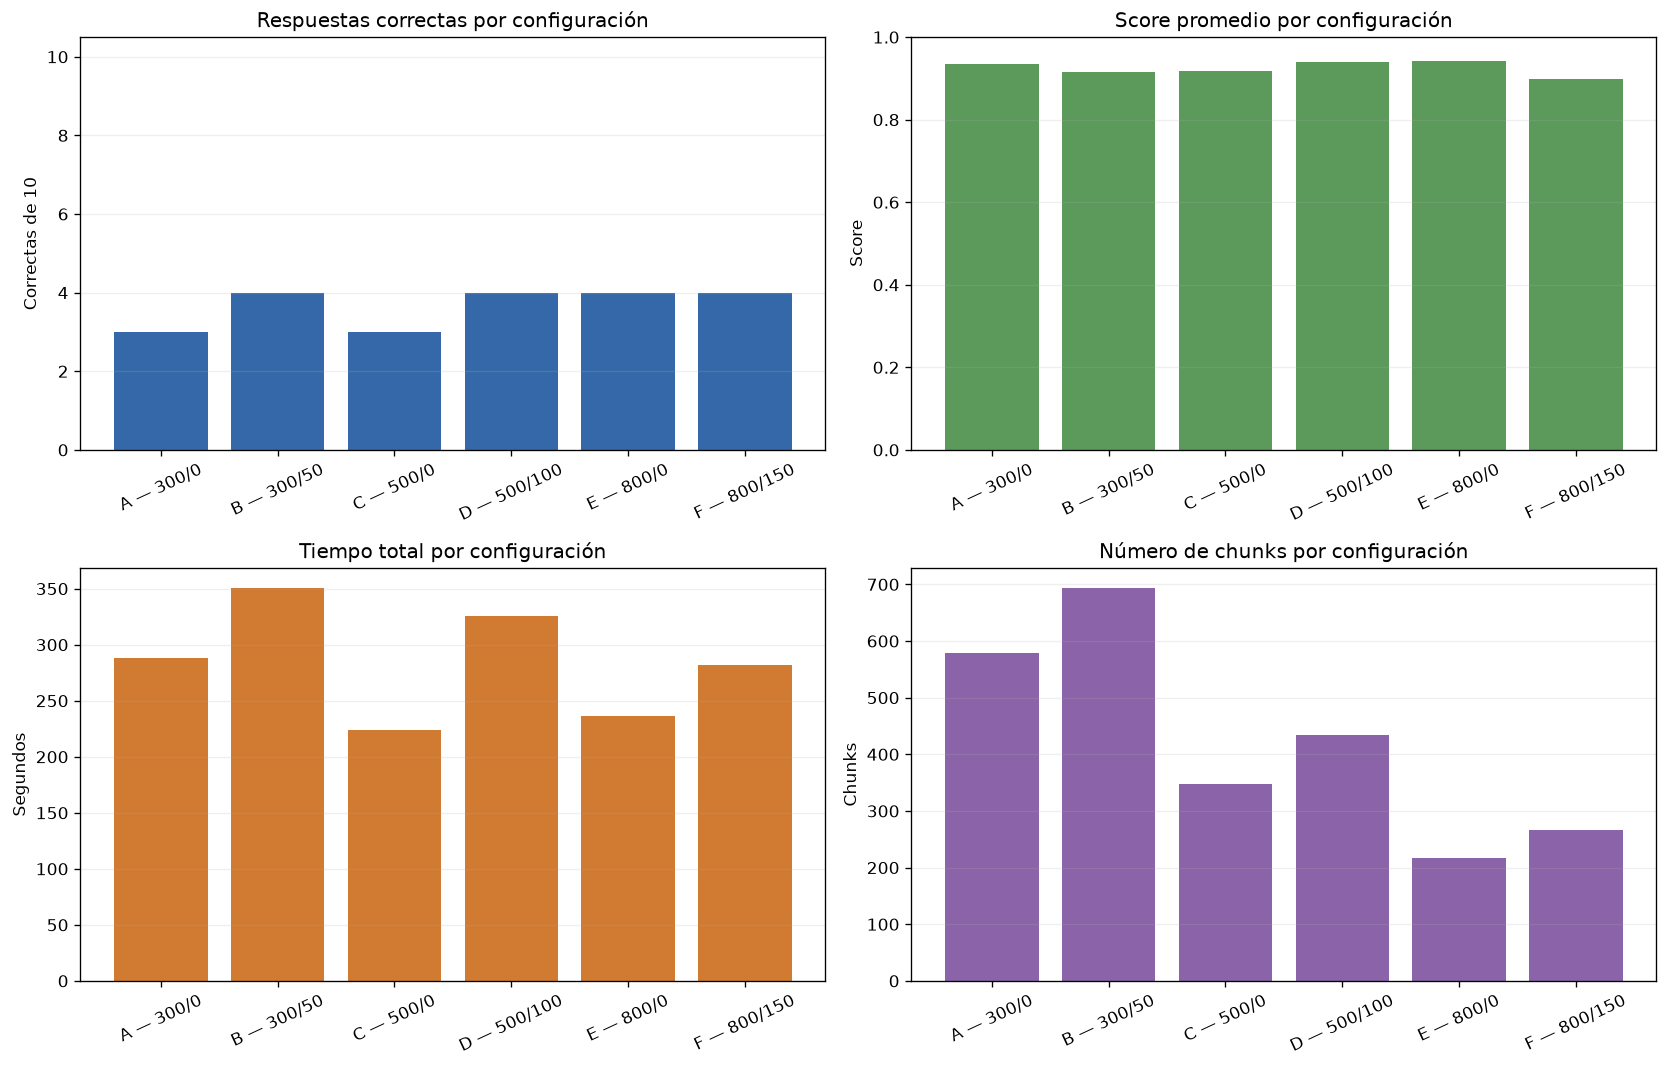

In [105]:
fig, ejes = plt.subplots(2, 2, figsize=(14, 9))
etiquetas = resumen_chunking["Configuración"]

ejes[0, 0].bar(etiquetas, resumen_chunking["Correctas"], color="#3568a8")
ejes[0, 0].set_title("Respuestas correctas por configuración")
ejes[0, 0].set_ylabel("Correctas de 10")
ejes[0, 0].set_ylim(0, 10.5)

ejes[0, 1].bar(etiquetas, resumen_chunking["Score promedio"], color="#5b9a5b")
ejes[0, 1].set_title("Score promedio por configuración")
ejes[0, 1].set_ylabel("Score")
ejes[0, 1].set_ylim(0, 1)

ejes[1, 0].bar(etiquetas, resumen_chunking["Tiempo total (s)"], color="#d07a32")
ejes[1, 0].set_title("Tiempo total por configuración")
ejes[1, 0].set_ylabel("Segundos")

ejes[1, 1].bar(etiquetas, resumen_chunking["Nº chunks"], color="#8a63a8")
ejes[1, 1].set_title("Número de chunks por configuración")
ejes[1, 1].set_ylabel("Chunks")

for eje in ejes.flat:
    eje.tick_params(axis="x", rotation=25)
    eje.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()


In [106]:
pares_overlap = [
    (300, "A — 300/0", "B — 300/50"),
    (500, "C — 500/0", "D — 500/100"),
    (800, "E — 800/0", "F — 800/150"),
]
comparacion_overlap = []
for tamano, nombre_sin, nombre_con in pares_overlap:
    sin_overlap = resumen_chunking.set_index("Configuración").loc[nombre_sin]
    con_overlap = resumen_chunking.set_index("Configuración").loc[nombre_con]
    comparacion_overlap.append({
        "Chunk": tamano,
        "Sin overlap": nombre_sin,
        "Con overlap": nombre_con,
        "Δ correctas": int(con_overlap["Correctas"] - sin_overlap["Correctas"]),
        "Δ score": con_overlap["Score promedio"] - sin_overlap["Score promedio"],
        "Δ chunks": int(con_overlap["Nº chunks"] - sin_overlap["Nº chunks"]),
        "Δ tiempo (s)": con_overlap["Tiempo total (s)"] - sin_overlap["Tiempo total (s)"],
    })

tabla_comparacion_overlap = pd.DataFrame(comparacion_overlap)
display(tabla_comparacion_overlap.style.format({
    "Δ score": "{:+.6f}",
    "Δ tiempo (s)": "{:+.3f}",
}))


,Chunk,Sin overlap,Con overlap,Δ correctas,Δ score,Δ chunks,Δ tiempo (s)
0,300,A — 300/0,B — 300/50,1,-0.019346,115,+62.650
1,500,C — 500/0,D — 500/100,1,+0.021781,87,+101.469
2,800,E — 800/0,F — 800/150,0,-0.044622,50,+45.897


### 12.8 Comparación sin solapamiento frente a solapamiento

- **300 caracteres:** el overlap de 50 elevó las correctas de 3 a 4, redujo el score promedio en `0.019346`, añadió 115 chunks y `62.650 s`. Hubo una mejora de accuracy, pero con mayor coste y menor confianza media.
- **500 caracteres:** el overlap de 100 elevó las correctas de 3 a 4 y el score medio en `0.021781`; añadió 87 chunks y `101.469 s`. Fue la mejora más clara en calidad, aunque con un aumento temporal considerable.
- **800 caracteres:** el overlap de 150 mantuvo 4 correctas, redujo el score medio en `0.044622`, añadió 50 chunks y `45.897 s`. En este tamaño el coste adicional no produjo una mejora observable.

Los scores permanecieron altos incluso en numerosas respuestas incorrectas. Esto se debe a que el máximo se selecciona entre muchos candidatos y confirma que el score no debe confundirse con accuracy.


In [107]:
resultados_pregunta_borde = resultados_chunking_detalle.loc[
    resultados_chunking_detalle["#"] == 10,
    [
        "Configuración", "Obtenida", "Score", "Correcta", "Chunk",
        "Inicio chunk", "Fin chunk", "Página chunk", "Evidencia en chunk",
        "Página objetivo en chunk",
    ],
].copy()
display(resultados_pregunta_borde.style.format({"Score": "{:.6f}"}))


,Configuración,Obtenida,Score,Correcta,Chunk,Inicio chunk,Fin chunk,Página chunk,Evidencia en chunk,Página objetivo en chunk
0,A — 300/0,dos años,0.982550,No,398,119100,119400,43,No,No
1,B — 300/50,tres años,0.984896,No,495,123500,123800,45,No,Sí
2,C — 500/0,dos años,0.981108,No,239,119000,119500,43,No,No
3,D — 500/100,dos años,0.988878,No,298,118800,119300,43,No,No
4,E — 800/0,dos años,0.985859,No,150,119200,120000,43,No,No
5,F — 800/150,dos años,0.990506,No,184,118950,119750,43,No,No


### 12.9 Pregunta cercana al límite del fragmento

La pregunta 10 no fue respondida correctamente por ninguna configuración. La variante `300/50` desplazó el chunk ganador a la página 45, donde está el artículo 184, pero extrajo «tres años» en lugar de «un año académico más». Las demás configuraciones seleccionaron principalmente «dos años» desde la página 43.

Por tanto, el caso real **no demostró que el overlap recuperara la respuesta dividida**. Aunque la condición y la ampliación están cerca de cortes de 500 y 800 caracteres, otros spans irrelevantes obtuvieron mayor score global. Este resultado se conserva sin forzar una conclusión favorable al solapamiento.


In [108]:
# Criterio jerárquico: correctas, score promedio y mediano y, después,
# menor coste temporal y menor cantidad de chunks.
ranking_configuraciones = resumen_chunking.sort_values(
    by=[
        "Correctas", "Score promedio", "Score mediano",
        "Tiempo total (s)", "Nº chunks",
    ],
    ascending=[False, False, False, True, True],
).reset_index(drop=True)

configuracion_ganadora = ranking_configuraciones.iloc[0]
CONFIGURACION_CHUNKING_SELECCIONADA = {
    "chunk_size": int(configuracion_ganadora["Chunk"]),
    "overlap": int(configuracion_ganadora["Overlap"]),
}
print("Configuración seleccionada para la fase RAG posterior:")
print(CONFIGURACION_CHUNKING_SELECCIONADA)
display(ranking_configuraciones.style.format({
    "Accuracy": "{:.1%}",
    "Score promedio": "{:.6f}",
    "Score mediano": "{:.6f}",
    "Tiempo total (s)": "{:.3f}",
}))


Configuración seleccionada para la fase RAG posterior:
{'chunk_size': 800, 'overlap': 0}


,Configuración,Chunk,Overlap,Nº chunks,Correctas,Accuracy,Score promedio,Score mediano,Tiempo total (s),Tiempo promedio/pregunta (s)
0,E — 800/0,800,0,217,4,40.0%,0.942767,0.947314,236.143,23.614272
1,D — 500/100,500,100,434,4,40.0%,0.938941,0.952259,325.274,32.527427
2,B — 300/50,300,50,694,4,40.0%,0.915775,0.916012,350.798,35.079764
3,F — 800/150,800,150,267,4,40.0%,0.898146,0.923997,282.039,28.203927
4,A — 300/0,300,0,579,3,30.0%,0.935121,0.941873,288.147,28.814732
5,C — 500/0,500,0,347,3,30.0%,0.917160,0.945109,223.805,22.380512


### 12.10 Configuración seleccionada y conclusión

La configuración seleccionada para la fase RAG posterior es **`chunk_size=800` y `overlap=0`**. Alcanzó 4/10 respuestas correctas, score promedio `0.942767`, mediana `0.947314`, tiempo total `236.143 s` y 217 chunks. Entre las configuraciones empatadas con cuatro respuestas correctas, obtuvo el mayor score promedio y simultáneamente el menor tiempo y la menor cantidad de fragmentos. `500/100` logró una mediana apenas mayor (`0.952259`), pero necesitó 434 chunks y `325.274 s`.

El experimento demuestra que el overlap puede mejorar casos concretos, pero no siempre compensa su coste. También evidencia la limitación del QA exhaustivo: seleccionar por score entre todo el documento favorece falsos positivos. La fase RAG posterior reutilizó esta configuración para recuperar primero fragmentos relevantes; su resultado inicial se conserva como referencia histórica.


## 13. Sistema RAG inicial con FAISS y MiniLM

### 13.1 Objetivo del sistema RAG

El QA exhaustivo ejecuta BETO sobre todos los fragmentos y puede seleccionar un
span de alta confianza tomado de un contexto irrelevante. El sistema RAG busca
reducir ese problema recuperando primero los fragmentos semánticamente más
relacionados con la pregunta y ejecutando QA únicamente sobre ese subconjunto.

FAISS recupera contexto; no genera la respuesta. BETO-SQAC conserva la
responsabilidad de extraer el span final.


### 13.2 Configuración utilizada

Se mantiene la configuración seleccionada experimentalmente en la Fase 9 y el
modelo QA ganador de la comparación previa. Los modelos se cargan una sola vez
y se reutilizan en todos los experimentos posteriores.


In [7]:
from pathlib import Path
import re
import time

import faiss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from sentence_transformers import SentenceTransformer
from transformers import AutoModelForQuestionAnswering, AutoTokenizer

DOCUMENTO_RAG = "data/documento_fuente.pdf"
MODELO_QA_RAG = "MMG/bert-base-spanish-wwm-cased-finetuned-sqac"
MODELO_EMBEDDINGS_RAG = (
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)
CONFIGURACION_RAG_BASE = {
    "chunk_size": 800,
    "overlap": 0,
    "unidad": "caracteres",
}

dispositivo_documentos = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Reutilizar BETO-SQAC si sigue disponible; cargarlo una sola vez en caso contrario.
modelo_qa_reutilizado = (
    "modelo_documentos" in globals()
    and "tokenizer_documentos" in globals()
    and getattr(modelo_documentos.config, "_name_or_path", "") == MODELO_QA_RAG
)
inicio_carga_qa = time.perf_counter()
if not modelo_qa_reutilizado:
    tokenizer_documentos = AutoTokenizer.from_pretrained(MODELO_QA_RAG)
    modelo_documentos = AutoModelForQuestionAnswering.from_pretrained(
        MODELO_QA_RAG
    )
    modelo_documentos.to(dispositivo_documentos)
modelo_documentos.eval()
tiempo_carga_qa = time.perf_counter() - inicio_carga_qa

inicio_carga_embeddings = time.perf_counter()
modelo_embeddings_rag = SentenceTransformer(
    MODELO_EMBEDDINGS_RAG,
    device=str(dispositivo_documentos),
)
tiempo_carga_embeddings = time.perf_counter() - inicio_carga_embeddings
dimension_embeddings = modelo_embeddings_rag.get_embedding_dimension()

assert not modelo_documentos.training

display(pd.DataFrame([{
    "Documento": DOCUMENTO_RAG,
    "Modelo QA": MODELO_QA_RAG,
    "Modelo embeddings": MODELO_EMBEDDINGS_RAG,
    "Dimensión embeddings": dimension_embeddings,
    "Chunk size": CONFIGURACION_RAG_BASE["chunk_size"],
    "Overlap": CONFIGURACION_RAG_BASE["overlap"],
    "Dispositivo": str(dispositivo_documentos),
    "BETO reutilizado": modelo_qa_reutilizado,
    "Tiempo carga QA (s)": tiempo_carga_qa,
    "Tiempo carga embeddings (s)": tiempo_carga_embeddings,
}]).style.format({
    "Tiempo carga QA (s)": "{:.3f}",
    "Tiempo carga embeddings (s)": "{:.3f}",
}))


/home/desarrolloab/Documentos/ML/Laboratorio 2/Repo/Laboratorio---ML/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 48925.35it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11788.58it/s]

,Documento,Modelo QA,Modelo embeddings,Dimensión embeddings,Chunk size,Overlap,Dispositivo,BETO reutilizado,Tiempo carga QA (s),Tiempo carga embeddings (s)
0,data/documento_fuente.pdf,MMG/bert-base-spanish-wwm-cased-finetuned-sqac,sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2,384,800,0,cuda,False,0.300,1.225


### 13.3 Generación de fragmentos

Los fragmentos conservan un único esquema de metadata: identificador, texto,
páginas y offsets dentro del texto limpio del PDF.


In [8]:
def pagina_para_offset(posicion):
    """Asocia un offset del texto unido con la página física más cercana."""
    for registro in paginas_documento:
        if posicion <= registro["fin"]:
            return registro["pagina"]
    return paginas_documento[-1]["pagina"]


def construir_fragmentos_rag(texto, chunk_size=800, overlap=0):
    """Construye chunks con el esquema documental definitivo del RAG."""
    if chunk_size <= 0:
        raise ValueError("chunk_size debe ser mayor que cero")
    if overlap < 0 or overlap >= chunk_size:
        raise ValueError("overlap debe cumplir 0 <= overlap < chunk_size")

    fragmentos = []
    paso = chunk_size - overlap
    for chunk_id, inicio in enumerate(range(0, len(texto), paso), start=1):
        fin = min(inicio + chunk_size, len(texto))
        fragmentos.append({
            "chunk_id": chunk_id,
            "texto": texto[inicio:fin],
            "pagina_inicio": pagina_para_offset(inicio),
            "pagina_fin": pagina_para_offset(max(fin - 1, inicio)),
            "inicio": inicio,
            "fin": fin,
        })
    return fragmentos


fragmentos_rag = construir_fragmentos_rag(
    texto_documento,
    chunk_size=CONFIGURACION_RAG_BASE["chunk_size"],
    overlap=CONFIGURACION_RAG_BASE["overlap"],
)
campos_fragmento_rag = {
    "chunk_id", "texto", "pagina_inicio", "pagina_fin", "inicio", "fin"
}

assert len(fragmentos_rag) == 217
assert all(set(fragmento) == campos_fragmento_rag for fragmento in fragmentos_rag)

display(pd.DataFrame([{
    "Chunks": len(fragmentos_rag),
    "Tamaño máximo": max(len(f["texto"]) for f in fragmentos_rag),
    "Página inicial": fragmentos_rag[0]["pagina_inicio"],
    "Página final": fragmentos_rag[-1]["pagina_fin"],
    "Campos de metadata": ", ".join(sorted(campos_fragmento_rag)),
}]))


,Chunks,Tamaño máximo,Página inicial,Página final,Campos de metadata
0,217,800,1,62,"chunk_id, fin, inicio, pagina_fin, pagina_inic..."


La fragmentación produjo los 217 chunks esperados y mantuvo trazabilidad desde
cada fragmento hasta las páginas físicas del reglamento.


### 13.4 Generación de embeddings

En el resultado inicial, MiniLM genera un vector por fragmento. Los vectores se normalizan con norma L2
para que el producto interno utilizado posteriormente equivalga a similitud
coseno.


In [9]:
textos_fragmentos_rag = [fragmento["texto"] for fragmento in fragmentos_rag]

inicio_embeddings_rag = time.perf_counter()
embeddings_rag = modelo_embeddings_rag.encode(
    textos_fragmentos_rag,
    batch_size=32,
    convert_to_numpy=True,
    normalize_embeddings=True,
    show_progress_bar=False,
).astype(np.float32)
tiempo_embeddings_rag = time.perf_counter() - inicio_embeddings_rag

assert embeddings_rag.shape == (len(fragmentos_rag), dimension_embeddings)
assert np.allclose(np.linalg.norm(embeddings_rag, axis=1), 1.0, atol=1e-5)

display(pd.DataFrame([{
    "Modelo": MODELO_EMBEDDINGS_RAG,
    "Chunks": len(fragmentos_rag),
    "Embeddings": embeddings_rag.shape[0],
    "Dimensión": embeddings_rag.shape[1],
    "Matriz": str(embeddings_rag.shape),
    "Normalizados": True,
    "Tiempo (s)": tiempo_embeddings_rag,
}]).style.format({"Tiempo (s)": "{:.3f}"}))


,Modelo,Chunks,Embeddings,Dimensión,Matriz,Normalizados,Tiempo (s)
0,sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2,217,217,384,"(217, 384)",True,0.595


La matriz contiene exactamente un embedding normalizado por cada chunk. Esta
matriz se reutiliza sin regenerarse al variar el valor de `k`.


### 13.5 Construcción del índice FAISS

`IndexFlatIP` realiza búsqueda exacta por producto interno. Como documentos y
consultas se normalizan previamente, la puntuación obtenida representa
similitud coseno: valores mayores indican mayor similitud semántica.


In [10]:
inicio_indice_rag = time.perf_counter()
indice_rag = faiss.IndexFlatIP(dimension_embeddings)
indice_rag.add(np.ascontiguousarray(embeddings_rag, dtype=np.float32))
tiempo_indice_rag = time.perf_counter() - inicio_indice_rag

assert indice_rag.d == dimension_embeddings
assert indice_rag.ntotal == len(fragmentos_rag)

display(pd.DataFrame([{
    "Índice": "IndexFlatIP",
    "Métrica": "Similitud coseno",
    "Implementación": "Producto interno sobre vectores normalizados",
    "Dimensión": indice_rag.d,
    "index.ntotal": indice_rag.ntotal,
    "Tiempo construcción (s)": tiempo_indice_rag,
}]).style.format({"Tiempo construcción (s)": "{:.6f}"}))


,Índice,Métrica,Implementación,Dimensión,index.ntotal,Tiempo construcción (s)
0,IndexFlatIP,Similitud coseno,Producto interno sobre vectores normalizados,384,217,0.000306


El índice almacena los 217 vectores y se construye una sola vez para todos los
experimentos de recuperación.


### 13.6 Recuperación semántica

La función siguiente devuelve los Top-K chunks con rank, similitud, texto,
identificador y páginas. El ejemplo muestra una consulta real sin imprimir el
contenido completo de los fragmentos.


In [11]:
def recuperar_fragmentos(pregunta, k=3):
    """Recupera Top-K y conserva toda la metadata documental y vectorial."""
    if not 1 <= k <= len(fragmentos_rag):
        raise ValueError("k debe estar entre 1 y la cantidad de fragmentos")

    embedding_pregunta = modelo_embeddings_rag.encode(
        [pregunta],
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False,
    ).astype(np.float32)
    assert embedding_pregunta.shape[1] == indice_rag.d

    similitudes, indices = indice_rag.search(
        np.ascontiguousarray(embedding_pregunta), k
    )
    return [
        {
            **fragmentos_rag[int(indice)],
            "rank_faiss": rank,
            "similitud_faiss": float(similitud),
        }
        for rank, (indice, similitud) in enumerate(
            zip(indices[0], similitudes[0]), start=1
        )
    ]


pregunta_ejemplo_rag = preguntas_documento[3]["pregunta"]
recuperacion_ejemplo = recuperar_fragmentos(pregunta_ejemplo_rag, k=3)
display(pd.DataFrame([{
    "Rank FAISS": fragmento["rank_faiss"],
    "Similitud": fragmento["similitud_faiss"],
    "Chunk": fragmento["chunk_id"],
    "Página": (
        str(fragmento["pagina_inicio"])
        if fragmento["pagina_inicio"] == fragmento["pagina_fin"]
        else f'{fragmento["pagina_inicio"]}-{fragmento["pagina_fin"]}'
    ),
    "Muestra": fragmento["texto"][:220].replace("\n", " ") + "…",
} for fragmento in recuperacion_ejemplo]).style.format({
    "Similitud": "{:.6f}"
}))


,Rank FAISS,Similitud,Chunk,Página,Muestra
0,1,0.796060,23,7,ramación del Sistema Académico Administrativo de la Universidad; y k) Las demás atribuciones de índole académico administrativo que le asigne la Secretaria de Asuntos Académicos y la legislación universitaria. En ausenci…
1,2,0.754807,13,4,iva publicación. SECRETARIA DE ASUNTOS ACADÉMICOS. Artículo 12. La Secretaria de Asuntos Académicos será la responsable de administrar y organizar en lo concerniente a los procesos Académicos- Administrativos Universitar…
2,3,0.748021,29,8-9,"te en la Universidad de El Salvador o instancias judiciales externas a la Universidad, en los últimos cinco años, anteriores a su nombramiento. 9 ATRIBUCIONES Y DEBERES DE LA UNIDAD DE INGRESO UNIVERSITARIO. Artículo 25…"


El ejemplo confirma que la recuperación conserva la procedencia y ordena los
fragmentos por similitud semántica antes de ejecutar QA.


### 13.7 Question Answering sobre fragmentos recuperados

Se reutiliza la única función `inferir_lote_qa(pregunta, lista_fragmentos)` ya
validada en las Fases 7–9. `responder_rag` ejecuta BETO-SQAC en lote sobre los
chunks recuperados y selecciona el mayor score QA sin combinarlo con FAISS.


In [12]:
def responder_rag(pregunta, k=3):
    """Recupera Top-K, ejecuta BETO-SQAC y preserva el chunk ganador."""
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    inicio = time.perf_counter()

    recuperados = recuperar_fragmentos(pregunta, k=k)
    salidas_qa = inferir_lote_qa(pregunta, recuperados)
    candidatos = [
        {
            **fragmento,
            "respuesta_qa": salida["answer"],
            "score_qa": float(salida["score"]),
        }
        for fragmento, salida in zip(recuperados, salidas_qa)
    ]
    ganador = max(candidatos, key=lambda candidato: candidato["score_qa"])

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    tiempo_total = time.perf_counter() - inicio

    return {
        "pregunta": pregunta,
        "respuesta_rag": ganador["respuesta_qa"],
        "score_qa": ganador["score_qa"],
        "rank_faiss": ganador["rank_faiss"],
        "similitud_faiss": ganador["similitud_faiss"],
        "chunk_id": ganador["chunk_id"],
        "pagina_inicio": ganador["pagina_inicio"],
        "pagina_fin": ganador["pagina_fin"],
        "texto_chunk": ganador["texto"],
        "tiempo": tiempo_total,
        "candidatos": candidatos,
    }


def evaluar_respuesta_rag(resultado, item):
    """Reutiliza el criterio de respuestas aplicado en las Fases 7–9."""
    correcta, detalle = evaluar_coincidencia(
        resultado["respuesta_rag"], item["respuesta_esperada"]
    )
    if not correcta:
        for variante in item.get("respuestas_aceptables", []):
            coincide, _ = evaluar_coincidencia(resultado["respuesta_rag"], variante)
            if coincide:
                return True, "Respuesta correcta por revisión manual explícita"
    return correcta, detalle


print("Implementación definitiva lista: recuperar_fragmentos + responder_rag")


Implementación definitiva lista: recuperar_fragmentos + responder_rag


La similitud FAISS mide relevancia entre pregunta y chunk. El score QA mide la
confianza del span dentro de ese contexto. Se mantienen separados porque
representan fenómenos distintos.


### 13.8 Experimento inicial con k=3

Se ejecutan las mismas diez preguntas documentales. La tabla conserva la
respuesta, evaluación, score QA y procedencia exacta del candidato ganador.


In [13]:
resultados_rag_k3 = []
for item in preguntas_documento:
    resultado = responder_rag(item["pregunta"], k=3)
    correcta, detalle = evaluar_respuesta_rag(resultado, item)
    resultado.update({
        "item": item,
        "correcta": correcta,
        "detalle_evaluacion": detalle,
    })
    resultados_rag_k3.append(resultado)

df_rag_k3 = pd.DataFrame([{
    "#": resultado["item"]["numero"],
    "Pregunta": resultado["pregunta"],
    "Esperada": resultado["item"]["respuesta_esperada"],
    "Respuesta RAG": resultado["respuesta_rag"],
    "Correcta": "Sí" if resultado["correcta"] else "No",
    "Score QA": resultado["score_qa"],
    "Rank FAISS": resultado["rank_faiss"],
    "Similitud": resultado["similitud_faiss"],
    "Chunk": resultado["chunk_id"],
    "Página": (
        str(resultado["pagina_inicio"])
        if resultado["pagina_inicio"] == resultado["pagina_fin"]
        else f'{resultado["pagina_inicio"]}-{resultado["pagina_fin"]}'
    ),
    "Tiempo (s)": resultado["tiempo"],
} for resultado in resultados_rag_k3])

correctas_rag_k3 = int(sum(r["correcta"] for r in resultados_rag_k3))
accuracy_rag_k3 = correctas_rag_k3 / len(resultados_rag_k3)
score_promedio_rag_k3 = float(df_rag_k3["Score QA"].mean())
tiempo_total_rag_k3 = float(df_rag_k3["Tiempo (s)"].sum())
tiempo_promedio_rag_k3 = float(df_rag_k3["Tiempo (s)"].mean())

assert len(df_rag_k3) == 10
assert correctas_rag_k3 == 3

display(df_rag_k3.style.format({
    "Score QA": "{:.6f}", "Similitud": "{:.6f}", "Tiempo (s)": "{:.3f}"
}))
display(pd.DataFrame([{
    "K": 3,
    "Correctas": f"{correctas_rag_k3}/10",
    "Accuracy": accuracy_rag_k3,
    "Score QA medio": score_promedio_rag_k3,
    "Tiempo total (s)": tiempo_total_rag_k3,
    "Tiempo medio (s)": tiempo_promedio_rag_k3,
}]).style.format({
    "Accuracy": "{:.1%}", "Score QA medio": "{:.6f}",
    "Tiempo total (s)": "{:.3f}", "Tiempo medio (s)": "{:.3f}",
}))


,#,Pregunta,Esperada,Respuesta RAG,Correcta,Score QA,Rank FAISS,Similitud,Chunk,Página,Tiempo (s)
0,1,¿Con qué periodicidad sesiona ordinariamente el Consejo Académico?,una vez al mes,ectiva,No,0.645120,3,0.649079,11,4,0.065
1,2,¿Cuál es el máximo de veces que un estudiante puede cambiar de carrera?,dos veces,157,No,0.799781,1,0.687721,138,40,0.045
2,3,¿Cuánto dura ordinariamente la calidad de egresado?,tres años académicos,tres años académicos,Sí,0.989079,1,0.567707,155,45,0.077
3,4,¿Qué unidades integran internamente la Secretaría de Asuntos Académicos?,Administración Académica Central; Unidad Curricular; y Unidad de Ingreso Universitario,a) Administración Académica Central; b) Unidad Curricular; y c) Unidad de Ingreso Universitario,Sí,0.943083,2,0.754807,13,4,0.049
4,5,¿Qué prueba se aplica después del curso de refuerzo académico en línea?,prueba de conocimiento general,anciera,No,0.039467,3,0.564315,78,22-23,0.044
5,6,¿A qué proceso se somete al estudiante con CUM acumulado menor a siete punto cero?,proceso de asesoría presencial o en línea,ro,No,0.287904,1,0.650484,127,37,0.047
6,7,¿Quién nombra a los miembros del Tribunal Calificador?,Junta Directiva,la Junta Directiva,Sí,0.967723,2,0.592524,172,49-50,0.044
7,8,¿Según qué reglamento se tramita la selección de ingreso de un aspirante a posgrado?,Reglamento General del Sistema de Estudios de Posgrado de la Universidad de El Salvador,el presente Reglamento,No,0.143519,3,0.685562,70,20,0.045
8,9,¿Cuándo entra en vigencia el Reglamento?,ocho días después de su publicación en El Diario Oficial,a partir de la undécima hasta la décima sexta semana de iniciado el Ciclo Académico,No,0.679282,3,0.568904,115,33-34,0.043
9,10,¿Por cuánto tiempo se amplía automáticamente la calidad de egresado si el plazo vence después de aprobar el trabajo de graduación y antes del acto de graduación?,un año académico más,6 semanas,No,0.912238,3,0.597168,100,29,0.049


,K,Correctas,Accuracy,Score QA medio,Tiempo total (s),Tiempo medio (s)
0,3,3/10,30.0%,0.640720,0.508,0.051


In [14]:
filas_procedencia = []
for numero in (1, 4, 9):
    resultado = next(
        r for r in resultados_rag_k3 if r["item"]["numero"] == numero
    )
    candidato = next(
        c for c in resultado["candidatos"]
        if c["rank_faiss"] == resultado["rank_faiss"]
        and c["chunk_id"] == resultado["chunk_id"]
    )
    verificada = all([
        candidato["respuesta_qa"] == resultado["respuesta_rag"],
        normalizar_texto(resultado["respuesta_rag"])
        in normalizar_texto(candidato["texto"]),
        candidato["pagina_inicio"] == resultado["pagina_inicio"],
        candidato["pagina_fin"] == resultado["pagina_fin"],
        np.isclose(candidato["similitud_faiss"], resultado["similitud_faiss"]),
    ])
    filas_procedencia.append({
        "#": numero,
        "Respuesta": resultado["respuesta_rag"],
        "Rank FAISS": resultado["rank_faiss"],
        "Chunk": resultado["chunk_id"],
        "Página inicio": resultado["pagina_inicio"],
        "Página fin": resultado["pagina_fin"],
        "Procedencia verificada": bool(verificada),
    })

df_validacion_procedencia = pd.DataFrame(filas_procedencia)
assert len(df_validacion_procedencia) == 3
assert df_validacion_procedencia["Procedencia verificada"].all()
display(df_validacion_procedencia)


,#,Respuesta,Rank FAISS,Chunk,Página inicio,Página fin,Procedencia verificada
0,1,ectiva,3,11,4,4,True
1,4,a) Administración Académica Central; b) Unidad...,2,13,4,4,True
2,9,a partir de la undécima hasta la décima sexta ...,3,115,33,34,True


El experimento conserva el resultado real de **3/10 respuestas correctas**. La
recuperación restringe el contexto y mantiene procedencia verificable, pero
Top-3 no garantiza que la evidencia correcta sea recuperada ni que BETO extraiga
el span esperado. Por eso la siguiente fase separa recuperación y QA al variar
el número de fragmentos candidatos.


## 14. Evaluación histórica de Top-K con MiniLM

`k` representa cuántos fragmentos recupera FAISS antes de ejecutar BETO-SQAC.
Se comparan `k = 1, 3, 5, 10` usando la misma matriz de embeddings, el mismo
índice, los mismos 217 chunks y las mismas diez preguntas. Los recursos
vectoriales no se reconstruyen entre ejecuciones.


### 14.1 Resultados detallados por K

Se conserva un registro por combinación K × pregunta. Para evitar una salida
visual excesiva se muestran tres preguntas por cada K, mientras el DataFrame
`df_rag_topk_detallado` mantiene las 40 filas completas.


In [15]:
def evaluar_relevancia_chunk(fragmento, item):
    """Valida evidencia real y página; el artículo aporta trazabilidad."""
    texto_norm = normalizar_texto(fragmento["texto"])
    evidencias = item.get("evidencias_clave")
    if evidencias:
        evidencia_textual = all(
            normalizar_texto(evidencia) in texto_norm for evidencia in evidencias
        )
    else:
        evidencia_textual = (
            normalizar_texto(item["fragmento_evidencia"]) in texto_norm
        )

    pagina_objetivo = item["pagina_evidencia"]
    pagina_coincide = (
        fragmento["pagina_inicio"]
        <= pagina_objetivo
        <= fragmento["pagina_fin"]
    )
    numero_articulo = re.search(r"\d+", item["articulo"])
    articulo_coincide = bool(
        numero_articulo
        and f"articulo {numero_articulo.group()}" in texto_norm
    )
    return {
        "recuperada": bool(evidencia_textual and pagina_coincide),
        "evidencia_textual": bool(evidencia_textual),
        "pagina_coincide": bool(pagina_coincide),
        "articulo_coincide": articulo_coincide,
    }


valores_k = [1, 3, 5, 10]
resultados_rag_por_k = {3: resultados_rag_k3}

for k in valores_k:
    if k == 3:
        continue
    resultados_k = []
    for item in preguntas_documento:
        resultado = responder_rag(item["pregunta"], k=k)
        correcta, detalle = evaluar_respuesta_rag(resultado, item)
        resultado.update({
            "item": item,
            "correcta": correcta,
            "detalle_evaluacion": detalle,
        })
        resultados_k.append(resultado)
    resultados_rag_por_k[k] = resultados_k

filas_topk = []
for k in valores_k:
    for resultado in resultados_rag_por_k[k]:
        item = resultado["item"]
        evaluaciones_recuperacion = [
            (candidato, evaluar_relevancia_chunk(candidato, item))
            for candidato in resultado["candidatos"]
        ]
        relevantes = [
            (candidato, evaluacion)
            for candidato, evaluacion in evaluaciones_recuperacion
            if evaluacion["recuperada"]
        ]
        articulo_confirmado = any(
            evaluacion["articulo_coincide"]
            for _, evaluacion in evaluaciones_recuperacion
        )
        filas_topk.append({
            "K": k,
            "#": item["numero"],
            "Pregunta": resultado["pregunta"],
            "Respuesta esperada": item["respuesta_esperada"],
            "Respuesta RAG": resultado["respuesta_rag"],
            "Correcta": "Sí" if resultado["correcta"] else "No",
            "Score QA": resultado["score_qa"],
            "Rank FAISS": resultado["rank_faiss"],
            "Similitud FAISS": resultado["similitud_faiss"],
            "Chunk ID": resultado["chunk_id"],
            "Página": (
                str(resultado["pagina_inicio"])
                if resultado["pagina_inicio"] == resultado["pagina_fin"]
                else f'{resultado["pagina_inicio"]}-{resultado["pagina_fin"]}'
            ),
            "Tiempo (s)": resultado["tiempo"],
            "Evidencia recuperada": "Sí" if relevantes else "No",
            "Rank evidencia": relevantes[0][0]["rank_faiss"] if relevantes else np.nan,
            "Artículo esperado": item["articulo"],
            "Artículo confirmado en Top-K": "Sí" if articulo_confirmado else "No",
        })

df_rag_topk_detallado = pd.DataFrame(filas_topk)
assert len(df_rag_topk_detallado) == 40
assert set(df_rag_topk_detallado["K"]) == set(valores_k)
assert (df_rag_topk_detallado.groupby("K").size() == 10).all()

vista_topk = df_rag_topk_detallado.groupby("K", group_keys=False).head(3)
display(vista_topk[[
    "K", "#", "Pregunta", "Respuesta RAG", "Correcta", "Score QA",
    "Rank FAISS", "Similitud FAISS", "Chunk ID", "Página",
    "Evidencia recuperada", "Tiempo (s)",
]].style.format({
    "Score QA": "{:.6f}", "Similitud FAISS": "{:.6f}",
    "Tiempo (s)": "{:.3f}",
}))
print(f"Resultados detallados conservados: {len(df_rag_topk_detallado)} filas")


,K,#,Pregunta,Respuesta RAG,Correcta,Score QA,Rank FAISS,Similitud FAISS,Chunk ID,Página,Evidencia recuperada,Tiempo (s)
0,1,1,¿Con qué periodicidad sesiona ordinariamente el Consejo Académico?,proceso administrativo,No,0.008135,1,0.667165,110,32,No,0.020
1,1,2,¿Cuál es el máximo de veces que un estudiante puede cambiar de carrera?,157,No,0.799781,1,0.687721,138,40,No,0.018
2,1,3,¿Cuánto dura ordinariamente la calidad de egresado?,tres años académicos,Sí,0.989079,1,0.567707,155,45,Sí,0.018
10,3,1,¿Con qué periodicidad sesiona ordinariamente el Consejo Académico?,ectiva,No,0.645120,3,0.649079,11,4,No,0.065
11,3,2,¿Cuál es el máximo de veces que un estudiante puede cambiar de carrera?,157,No,0.799781,1,0.687721,138,40,No,0.045
12,3,3,¿Cuánto dura ordinariamente la calidad de egresado?,tres años académicos,Sí,0.989079,1,0.567707,155,45,Sí,0.077
20,5,1,¿Con qué periodicidad sesiona ordinariamente el Consejo Académico?,ectiva,No,0.645121,3,0.649079,11,4,No,0.070
21,5,2,¿Cuál es el máximo de veces que un estudiante puede cambiar de carrera?,157,No,0.799781,1,0.687721,138,40,No,0.068
22,5,3,¿Cuánto dura ordinariamente la calidad de egresado?,tres años académicos,Sí,0.989079,1,0.567707,155,45,Sí,0.076
30,10,1,¿Con qué periodicidad sesiona ordinariamente el Consejo Académico?,una vez al mes,Sí,0.983679,9,0.625208,6,2-3,Sí,0.138


Resultados detallados conservados: 40 filas


### 14.2 Recall@K y comparación general

Una pregunta se considera recuperada cuando al menos un chunk del Top-K
contiene la evidencia real y cubre la página esperada. `fragmento_evidencia` o
`evidencias_clave` determinan la coincidencia textual; artículo y página se
conservan para comprobar la procedencia documental.


In [16]:
filas_comparacion_topk = []
for k in valores_k:
    grupo = df_rag_topk_detallado[df_rag_topk_detallado["K"] == k]
    correctas = int((grupo["Correcta"] == "Sí").sum())
    filas_comparacion_topk.append({
        "K": k,
        "Correctas": correctas,
        "Accuracy": correctas / len(grupo),
        "Recall@K": float((grupo["Evidencia recuperada"] == "Sí").mean()),
        "Score QA medio": float(grupo["Score QA"].mean()),
        "Tiempo total": float(grupo["Tiempo (s)"].sum()),
        "Tiempo medio": float(grupo["Tiempo (s)"].mean()),
    })

df_comparacion_topk = pd.DataFrame(filas_comparacion_topk)[[
    "K", "Correctas", "Accuracy", "Recall@K", "Score QA medio",
    "Tiempo total", "Tiempo medio",
]]

assert list(df_comparacion_topk.columns) == [
    "K", "Correctas", "Accuracy", "Recall@K", "Score QA medio",
    "Tiempo total", "Tiempo medio",
]
assert not df_comparacion_topk.isna().any().any()

display(df_comparacion_topk.style.format({
    "Accuracy": "{:.1%}", "Recall@K": "{:.1%}",
    "Score QA medio": "{:.6f}", "Tiempo total": "{:.3f}",
    "Tiempo medio": "{:.3f}",
}))


,K,Correctas,Accuracy,Recall@K,Score QA medio,Tiempo total,Tiempo medio
0,1,1,10.0%,10.0%,0.269381,0.189,0.019
1,3,3,30.0%,30.0%,0.640720,0.508,0.051
2,5,3,30.0%,30.0%,0.702736,0.721,0.072
3,10,4,40.0%,40.0%,0.836432,1.408,0.141


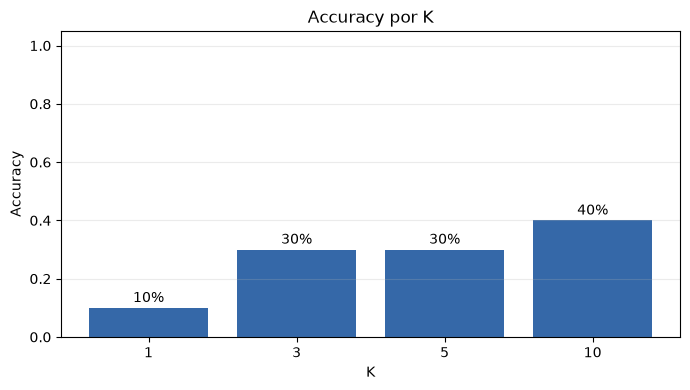

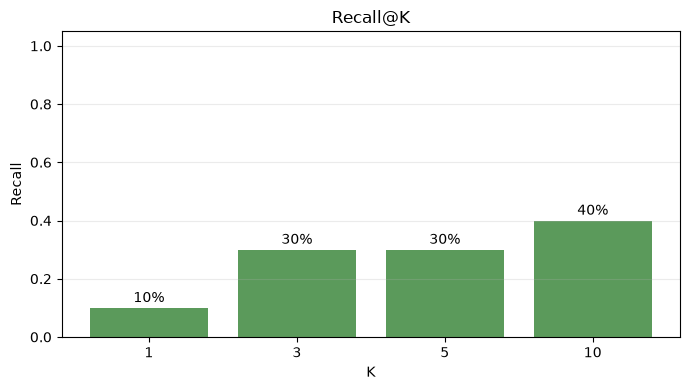

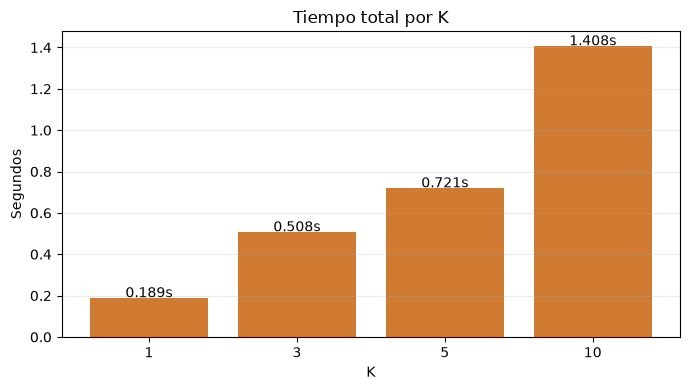

In [17]:
for columna, titulo, ylabel, color, formato in [
    ("Accuracy", "Accuracy por K", "Accuracy", "#3568a8", lambda v: f"{v:.0%}"),
    ("Recall@K", "Recall@K", "Recall", "#5b9a5b", lambda v: f"{v:.0%}"),
    ("Tiempo total", "Tiempo total por K", "Segundos", "#d07a32", lambda v: f"{v:.3f}s"),
]:
    fig, ax = plt.subplots(figsize=(7, 4))
    barras = ax.bar(
        df_comparacion_topk["K"].astype(str),
        df_comparacion_topk[columna],
        color=color,
    )
    ax.set_xlabel("K")
    ax.set_ylabel(ylabel)
    ax.set_title(titulo)
    ax.grid(axis="y", alpha=0.25)
    if columna in ("Accuracy", "Recall@K"):
        ax.set_ylim(0, 1.05)
    for barra, valor in zip(barras, df_comparacion_topk[columna]):
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            barra.get_height() + (0.02 if columna != "Tiempo total" else 0.003),
            formato(valor),
            ha="center",
        )
    plt.tight_layout()
    plt.show()


### 14.3 Análisis del valor de K


In [18]:
lineas_analisis = []
fila_k1 = df_comparacion_topk.set_index("K").loc[1]
for _, fila in df_comparacion_topk.iterrows():
    k = int(fila["K"])
    delta_tiempo = fila["Tiempo total"] - fila_k1["Tiempo total"]
    lineas_analisis.append(
        f"- **k={k}:** {int(fila['Correctas'])}/10 correctas "
        f"({fila['Accuracy']:.0%}), Recall@{k}={fila['Recall@K']:.0%}, "
        f"tiempo total={fila['Tiempo total']:.3f} s "
        f"(Δ frente a k=1: {delta_tiempo:+.3f} s)."
    )

recall_mejoro = (
    df_comparacion_topk.iloc[-1]["Recall@K"]
    > df_comparacion_topk.iloc[0]["Recall@K"]
)
accuracy_mejoro = (
    df_comparacion_topk.iloc[-1]["Accuracy"]
    > df_comparacion_topk.iloc[0]["Accuracy"]
)
lineas_analisis.extend([
    "",
    "Al aumentar K, el Recall "
    + ("sí mejoró." if recall_mejoro else "no mejoró respecto a k=1."),
    "La Accuracy "
    + ("sí aumentó entre k=1 y k=10." if accuracy_mejoro
       else "no aumentó entre k=1 y k=10."),
    "Por tanto, recuperar más fragmentos "
    + ("produjo más respuestas correctas, aunque con mayor coste de QA."
       if accuracy_mejoro else
       "no se tradujo automáticamente en más respuestas correctas."),
])
display(Markdown("\n".join(lineas_analisis)))


- **k=1:** 1/10 correctas (10%), Recall@1=10%, tiempo total=0.189 s (Δ frente a k=1: +0.000 s).
- **k=3:** 3/10 correctas (30%), Recall@3=30%, tiempo total=0.508 s (Δ frente a k=1: +0.319 s).
- **k=5:** 3/10 correctas (30%), Recall@5=30%, tiempo total=0.721 s (Δ frente a k=1: +0.531 s).
- **k=10:** 4/10 correctas (40%), Recall@10=40%, tiempo total=1.408 s (Δ frente a k=1: +1.219 s).

Al aumentar K, el Recall sí mejoró.
La Accuracy sí aumentó entre k=1 y k=10.
Por tanto, recuperar más fragmentos produjo más respuestas correctas, aunque con mayor coste de QA.

### 14.4 Configuración MiniLM seleccionada en la etapa Top-K

Este resultado histórico con MiniLM aplica un orden jerárquico: respuestas correctas, Recall@K,
tiempo total y finalmente menor K para reducir el coste de inferencias.


In [19]:
ranking_topk = df_comparacion_topk.sort_values(
    by=["Correctas", "Recall@K", "Tiempo total", "K"],
    ascending=[False, False, True, True],
).reset_index(drop=True)

K_SELECCIONADO = int(ranking_topk.iloc[0]["K"])
RAG_CONFIG_TOPK_MINILM = {
    "chunk_size": 800,
    "overlap": 0,
    "top_k": K_SELECCIONADO,
    "unidad": "caracteres",
}

fila_seleccionada = ranking_topk.iloc[0]
repeticiones_mismo_acierto = int(
    (df_comparacion_topk["Correctas"] == fila_seleccionada["Correctas"]).sum()
)
estabilidad = (
    f"el mismo número de aciertos aparece en {repeticiones_mismo_acierto} valores de K"
    if repeticiones_mismo_acierto > 1
    else "fue el único valor con ese número de aciertos"
)

display(pd.DataFrame([RAG_CONFIG_TOPK_MINILM]))
display(Markdown(
    f"Se selecciona **k={K_SELECCIONADO}**: obtuvo "
    f"{int(fila_seleccionada['Correctas'])}/10 correctas, "
    f"Recall@{K_SELECCIONADO}={fila_seleccionada['Recall@K']:.0%} y "
    f"{fila_seleccionada['Tiempo total']:.3f} s. En estabilidad, {estabilidad}; "
    f"su coste máximo es {K_SELECCIONADO * 10} inferencias QA para diez preguntas."
))


,chunk_size,overlap,top_k,unidad
0,800,0,10,caracteres


Se selecciona **k=10**: obtuvo 4/10 correctas, Recall@10=40% y 1.408 s. En estabilidad, fue el único valor con ese número de aciertos; su coste máximo es 100 inferencias QA para diez preguntas.

## 15. Comparación histórica: QA exhaustivo y RAG MiniLM

### 15.1 Objetivo

**Objetivo.** Comparar el QA exhaustivo sobre todos los chunks con el resultado inicial de RAG MiniLM que
combina recuperación FAISS Top-K y BETO-SQAC. La comparación busca determinar
si RAG modifica la accuracy y cuánto reduce el tiempo y el número de inferencias,
además de identificar los principales tipos de error.

**Metodología.** Ambos métodos usan el mismo PDF, las mismas diez preguntas, el
mismo modelo BETO-SQAC, chunks de 800 caracteres sin overlap y el criterio de
evaluación de las Fases 7–11. El baseline se reutiliza desde los DataFrames ya
ejecutados; no se repiten sus 2,170 inferencias. Para mantener tiempos
comparables se contrasta la inferencia exhaustiva con consulta FAISS + QA RAG,
sin incluir la preparación inicial de embeddings e índice.


### 15.2 Baseline exhaustivo

**Metodología.** Se selecciona programáticamente la fila `800/0` de
`resumen_chunking` y sus diez registros en `resultados_chunking_detalle`. Esto
evita escribir métricas manualmente y conserva exactamente los resultados de la
Fase 9.


In [20]:
fila_baseline = resumen_chunking.loc[
    (resumen_chunking["Chunk"] == RAG_CONFIG_TOPK_MINILM["chunk_size"])
    & (resumen_chunking["Overlap"] == RAG_CONFIG_TOPK_MINILM["overlap"])
].iloc[0]
nombre_baseline = fila_baseline["Configuración"]
detalle_baseline = resultados_chunking_detalle.loc[
    resultados_chunking_detalle["Configuración"] == nombre_baseline
].copy()

assert len(detalle_baseline) == len(preguntas_documento) == 10

df_baseline_reutilizado = pd.DataFrame([{
    "Configuración": nombre_baseline,
    "Chunks": int(fila_baseline["Nº chunks"]),
    "Preguntas": len(detalle_baseline),
    "Correctas": int(fila_baseline["Correctas"]),
    "Accuracy": float(fila_baseline["Accuracy"]),
    "Score QA medio": float(fila_baseline["Score promedio"]),
    "Tiempo total (s)": float(fila_baseline["Tiempo total (s)"]),
}])
display(df_baseline_reutilizado.style.format({
    "Accuracy": "{:.1%}", "Score QA medio": "{:.6f}",
    "Tiempo total (s)": "{:.3f}",
}))


,Configuración,Chunks,Preguntas,Correctas,Accuracy,Score QA medio,Tiempo total (s)
0,E — 800/0,217,10,4,40.0%,0.942767,236.143


**Resultado y análisis.** El baseline 800/0 conserva 217 chunks, 4/10
respuestas correctas, accuracy de 40 %, score QA medio de 0.942767 y 236.143 s.
El score es alto a pesar de seis respuestas incorrectas, por lo que no puede
interpretarse como una medida de exactitud global.

**Conclusión parcial.** El barrido exhaustivo encuentra cuatro respuestas, pero
su coste es elevado y la selección del mayor score entre 217 contextos por
pregunta favorece spans confiados tomados de fragmentos irrelevantes.


### 15.3 Resultado histórico: RAG MiniLM Top-10

**Metodología.** Se reutiliza la fila `top_k=10` de `df_comparacion_topk` y las
diez observaciones correspondientes de `df_rag_topk_detallado`. Los embeddings
y el índice FAISS siguen siendo los construidos una sola vez en la Fase 10.


In [21]:
fila_rag_final = df_comparacion_topk.loc[
    df_comparacion_topk["K"] == RAG_CONFIG_TOPK_MINILM["top_k"]
].iloc[0]
detalle_rag_final = df_rag_topk_detallado.loc[
    df_rag_topk_detallado["K"] == RAG_CONFIG_TOPK_MINILM["top_k"]
].copy()

assert len(detalle_rag_final) == len(detalle_baseline) == 10
assert set(detalle_rag_final["#"]) == set(detalle_baseline["#"])
assert set(detalle_rag_final["Pregunta"]) == set(detalle_baseline["Pregunta"])

df_rag_final_reutilizado = pd.DataFrame([{
    "Top-K": int(fila_rag_final["K"]),
    "Chunks QA/pregunta": RAG_CONFIG_TOPK_MINILM["top_k"],
    "Preguntas": len(detalle_rag_final),
    "Correctas": int(fila_rag_final["Correctas"]),
    "Accuracy": float(fila_rag_final["Accuracy"]),
    "Recall@10": float(fila_rag_final["Recall@K"]),
    "Score QA medio": float(fila_rag_final["Score QA medio"]),
    "Tiempo total (s)": float(fila_rag_final["Tiempo total"]),
}])
display(df_rag_final_reutilizado.style.format({
    "Accuracy": "{:.1%}", "Recall@10": "{:.1%}",
    "Score QA medio": "{:.6f}", "Tiempo total (s)": "{:.3f}",
}))


,Top-K,Chunks QA/pregunta,Preguntas,Correctas,Accuracy,Recall@10,Score QA medio,Tiempo total (s)
0,10,10,10,4,40.0%,40.0%,0.836432,1.408


**Resultado histórico con MiniLM y análisis.** RAG con Top-10 mantiene 4/10 respuestas correctas y
Recall@10 de 40 %. Por tanto, no mejora la accuracy respecto al baseline. Su
score QA medio es menor porque evita comparar contra la mayoría de contextos
irrelevantes y restringe la selección a diez candidatos semánticos.

**Conclusión parcial.** La recuperación reduce el espacio de búsqueda sin perder
las cuatro respuestas correctas del agregado, pero el Recall de 40 % limita el
máximo rendimiento observable de esta configuración.


### 15.4 Tabla comparativa

**Metodología.** Las inferencias se calculan con el número real de chunks y las
diez preguntas: `chunks × preguntas` para el baseline y `top_k × preguntas`
para RAG. Accuracy, score y tiempo se extraen de los DataFrames reutilizados.


In [22]:
numero_preguntas_comparacion = len(preguntas_documento)
inferencias_baseline = (
    int(fila_baseline["Nº chunks"]) * numero_preguntas_comparacion
)
inferencias_rag = RAG_CONFIG_TOPK_MINILM["top_k"] * numero_preguntas_comparacion

comparacion_baseline_rag = pd.DataFrame([
    {
        "Método": "QA exhaustivo 800/0",
        "Correctas": int(fila_baseline["Correctas"]),
        "Accuracy": float(fila_baseline["Accuracy"]),
        "Score QA medio": float(fila_baseline["Score promedio"]),
        "Tiempo total": float(fila_baseline["Tiempo total (s)"]),
        "Inferencias QA": inferencias_baseline,
    },
    {
        "Método": f"RAG FAISS Top-{RAG_CONFIG_TOPK_MINILM['top_k']}",
        "Correctas": int(fila_rag_final["Correctas"]),
        "Accuracy": float(fila_rag_final["Accuracy"]),
        "Score QA medio": float(fila_rag_final["Score QA medio"]),
        "Tiempo total": float(fila_rag_final["Tiempo total"]),
        "Inferencias QA": inferencias_rag,
    },
])

display(comparacion_baseline_rag.style.format({
    "Accuracy": "{:.1%}", "Score QA medio": "{:.6f}",
    "Tiempo total": "{:.3f}",
}))


,Método,Correctas,Accuracy,Score QA medio,Tiempo total,Inferencias QA
0,QA exhaustivo 800/0,4,40.0%,0.942767,236.143,2170
1,RAG FAISS Top-10,4,40.0%,0.836432,1.408,100


In [23]:
accuracy_baseline = float(comparacion_baseline_rag.iloc[0]["Accuracy"])
accuracy_rag = float(comparacion_baseline_rag.iloc[1]["Accuracy"])
delta_accuracy = accuracy_rag - accuracy_baseline

display(Markdown(
    f"**Análisis.** Ambos métodos obtuvieron "
    f"{int(fila_baseline['Correctas'])}/10 respuestas correctas "
    f"({accuracy_baseline:.0%}). La diferencia de accuracy fue "
    f"{delta_accuracy:+.0%}; por tanto, RAG no fue más preciso en esta muestra. "
    f"La diferencia sustantiva aparece en coste: {inferencias_baseline} "
    f"inferencias frente a {inferencias_rag}.\n\n"
    f"**Conclusión parcial.** La recuperación Top-10 preservó la accuracy del "
    f"baseline evaluando solo {RAG_CONFIG_TOPK_MINILM['top_k']} de "
    f"{int(fila_baseline['Nº chunks'])} chunks por pregunta."
))


**Análisis.** Ambos métodos obtuvieron 4/10 respuestas correctas (40%). La diferencia de accuracy fue +0%; por tanto, RAG no fue más preciso en esta muestra. La diferencia sustantiva aparece en coste: 2170 inferencias frente a 100.

**Conclusión parcial.** La recuperación Top-10 preservó la accuracy del baseline evaluando solo 10 de 217 chunks por pregunta.

### 15.5 Rendimiento

**Metodología.** El speedup divide el tiempo de inferencia exhaustiva entre el
tiempo de consulta + QA de RAG. La reducción de inferencias compara 100 contra
2,170 ejecuciones QA. La generación inicial de embeddings y el índice se
reportan aparte y no entran en el cociente.


In [24]:
tiempo_baseline = float(fila_baseline["Tiempo total (s)"])
tiempo_rag = float(fila_rag_final["Tiempo total"])
speedup = tiempo_baseline / tiempo_rag
reduccion_inferencias = 1 - (inferencias_rag / inferencias_baseline)
inferencias_evitadas = inferencias_baseline - inferencias_rag

df_rendimiento = pd.DataFrame([{
    "Speedup": speedup,
    "Reducción de inferencias": reduccion_inferencias,
    "Inferencias evitadas": inferencias_evitadas,
    "Tiempo embeddings (s), excluido": tiempo_embeddings_rag,
    "Tiempo índice (s), excluido": tiempo_indice_rag,
}])
display(df_rendimiento.style.format({
    "Speedup": "{:.2f}x", "Reducción de inferencias": "{:.1%}",
    "Tiempo embeddings (s), excluido": "{:.3f}",
    "Tiempo índice (s), excluido": "{:.6f}",
}))
display(Markdown(
    f"**Resultado y análisis.** RAG fue **{speedup:.2f} veces más rápido** "
    f"en esta ejecución y redujo las inferencias QA en "
    f"**{reduccion_inferencias:.1%}**, evitando {inferencias_evitadas} de "
    f"{inferencias_baseline}. La preparación vectorial se excluyó de ambos "
    f"tiempos comparados; se informa únicamente como coste inicial amortizable.\n\n"
    f"**Conclusión parcial.** La ventaja demostrada de RAG es computacional: "
    f"mantiene la accuracy con una fracción de las inferencias del baseline."
))


,Speedup,Reducción de inferencias,Inferencias evitadas,"Tiempo embeddings (s), excluido","Tiempo índice (s), excluido"
0,167.75x,95.4%,2070,0.595,0.000306


**Resultado y análisis.** RAG fue **167.75 veces más rápido** en esta ejecución y redujo las inferencias QA en **95.4%**, evitando 2070 de 2170. La preparación vectorial se excluyó de ambos tiempos comparados; se informa únicamente como coste inicial amortizable.

**Conclusión parcial.** La ventaja demostrada de RAG es computacional: mantiene la accuracy con una fracción de las inferencias del baseline.

### 15.6 Análisis del score

**Objetivo y metodología.** Se contrasta el score QA medio con la accuracy para
comprobar si la confianza del span predice la corrección documental. Esta
separación corrige la interpretación metodológica de considerar el score como
sinónimo de exactitud.


In [25]:
df_score_accuracy = comparacion_baseline_rag[[
    "Método", "Correctas", "Accuracy", "Score QA medio"
]].copy()
display(df_score_accuracy.style.format({
    "Accuracy": "{:.1%}", "Score QA medio": "{:.6f}",
}))
display(Markdown(
    f"**Resultado.** El baseline alcanzó score medio "
    f"{fila_baseline['Score promedio']:.6f} con accuracy "
    f"{fila_baseline['Accuracy']:.0%}; RAG obtuvo score medio "
    f"{fila_rag_final['Score QA medio']:.6f} con la misma accuracy de "
    f"{fila_rag_final['Accuracy']:.0%}.\n\n"
    f"**Análisis.** Un score QA alto indica confianza del modelo sobre el span "
    f"seleccionado dentro del contexto suministrado, pero no garantiza que ese "
    f"contexto sea relevante para la pregunta. El baseline ilustra esta "
    f"limitación: seis respuestas fueron incorrectas pese al score medio de "
    f"{fila_baseline['Score promedio']:.4f}.\n\n"
    f"**Conclusión.** RAG no mejoró la accuracy, pero redujo la competencia "
    f"entre contextos irrelevantes. El score debe interpretarse junto con "
    f"Recall y accuracy, nunca de forma aislada."
))


,Método,Correctas,Accuracy,Score QA medio
0,QA exhaustivo 800/0,4,40.0%,0.942767
1,RAG FAISS Top-10,4,40.0%,0.836432


**Resultado.** El baseline alcanzó score medio 0.942767 con accuracy 40%; RAG obtuvo score medio 0.836432 con la misma accuracy de 40%.

**Análisis.** Un score QA alto indica confianza del modelo sobre el span seleccionado dentro del contexto suministrado, pero no garantiza que ese contexto sea relevante para la pregunta. El baseline ilustra esta limitación: seis respuestas fueron incorrectas pese al score medio de 0.9428.

**Conclusión.** RAG no mejoró la accuracy, pero redujo la competencia entre contextos irrelevantes. El score debe interpretarse junto con Recall y accuracy, nunca de forma aislada.

## 16. Análisis de errores del RAG inicial con MiniLM

### 16.1 Objetivo

**Objetivo.** Separar los fallos de recuperación, QA, respuesta parcial,
ambigüedad, chunking y evaluación en las diez preguntas de RAG Top-10.

**Metodología.** Para cada pregunta se inspeccionan la evidencia esperada, los
diez candidatos FAISS, el chunk ganador, la respuesta, página, similitud y score
QA. La evidencia se valida mediante `fragmento_evidencia` o
`evidencias_clave` y la página esperada. Además se comprueba el corpus completo
para distinguir evidencia no recuperada de evidencia dividida por chunking.


### 16.2 Clasificación

Se aplica la siguiente precedencia para evitar categorías arbitrarias:

- `error_recuperacion`: la evidencia existe completa en algún chunk 800/0, pero
  no apareció en Top-10.
- `error_qa`: la evidencia apareció en Top-10 y BETO seleccionó un span
  incorrecto.
- `respuesta_parcial`: el contexto correcto fue recuperado, pero el span solo
  cubrió parte de la respuesta.
- `ambiguedad`: varios contextos recuperados sostienen interpretaciones
  plausibles y no puede atribuirse el fallo solo a QA.
- `chunking`: ninguna ventana individual contiene la evidencia completa, pero
  esta aparece al unir chunks adyacentes.
- `evaluacion`: la respuesta es válida, pero el criterio automático inicial no
  la reconoce.
- `otro`: se reserva para casos sin explicación en las categorías anteriores.

**Decisión técnica.** No se clasifica por score. La causa se decide examinando
primero presencia y procedencia de la evidencia; así se evita atribuir a BETO un
fallo originado en FAISS o en el corte de texto.


### 16.3 Tabla de errores

**Metodología.** Las respuestas correctas se registran como `Sin error`. Para
cada fallo se conserva una observación específica con la respuesta, chunk,
página y disponibilidad real de la evidencia.


In [26]:
def evidencia_en_texto(texto, item):
    texto_norm = normalizar_texto(texto)
    evidencias = item.get("evidencias_clave") or [item["fragmento_evidencia"]]
    return all(normalizar_texto(evidencia) in texto_norm for evidencia in evidencias)


def chunks_globales_con_evidencia(item):
    return [
        fragmento for fragmento in fragmentos_rag
        if evidencia_en_texto(fragmento["texto"], item)
        and fragmento["pagina_inicio"]
        <= item["pagina_evidencia"]
        <= fragmento["pagina_fin"]
    ]


def evidencia_dividida_en_adyacentes(item):
    for izquierdo, derecho in zip(fragmentos_rag[:-1], fragmentos_rag[1:]):
        if not (
            izquierdo["pagina_inicio"]
            <= item["pagina_evidencia"]
            <= derecho["pagina_fin"]
        ):
            continue
        if evidencia_en_texto(izquierdo["texto"] + derecho["texto"], item):
            return True
    return False


resultado_k10_por_numero = {
    resultado["item"]["numero"]: resultado
    for resultado in resultados_rag_por_k[RAG_CONFIG_TOPK_MINILM["top_k"]]
}

filas_errores = []
categorias_error = [
    "error_recuperacion", "error_qa", "respuesta_parcial", "ambiguedad",
    "chunking", "evaluacion", "otro",
]

for _, fila in detalle_rag_final.sort_values("#").iterrows():
    numero = int(fila["#"])
    resultado = resultado_k10_por_numero[numero]
    item = resultado["item"]
    correcta = bool(resultado["correcta"])
    evidencia_topk = fila["Evidencia recuperada"] == "Sí"
    globales = chunks_globales_con_evidencia(item)
    dividida = evidencia_dividida_en_adyacentes(item)

    if correcta:
        causa = "Sin error"
        observacion = (
            f"Evidencia recuperada y respuesta correcta desde chunk "
            f"{resultado['chunk_id']} (página {resultado['pagina_inicio']}, "
            f"rank {resultado['rank_faiss']}, score {resultado['score_qa']:.4f})."
        )
    elif not evidencia_topk and not globales and dividida:
        causa = "chunking"
        observacion = (
            "La evidencia no cabe completa en ningún chunk 800/0; aparece al "
            "unir ventanas adyacentes. El Top-10 no podía ofrecer un contexto "
            "individual completo al modelo QA."
        )
    elif not evidencia_topk:
        causa = "error_recuperacion"
        ids_globales = [fragmento["chunk_id"] for fragmento in globales]
        observacion = (
            f"La evidencia existe en chunk(s) {ids_globales}, pero no apareció "
            f"en Top-10. El ganador fue chunk {resultado['chunk_id']} "
            f"(página {resultado['pagina_inicio']}) y respondió "
            f"{resultado['respuesta_rag']!r}."
        )
    else:
        _, detalle_coincidencia = evaluar_coincidencia(
            resultado["respuesta_rag"], item["respuesta_esperada"]
        )
        if "parcial" in detalle_coincidencia.lower():
            causa = "respuesta_parcial"
            observacion = (
                "La evidencia correcta estuvo en Top-10, pero BETO extrajo "
                f"solo un span parcial: {resultado['respuesta_rag']!r}."
            )
        else:
            causa = "error_qa"
            observacion = (
                "La evidencia correcta estuvo en Top-10, pero BETO seleccionó "
                f"{resultado['respuesta_rag']!r} desde el chunk ganador."
            )

    filas_errores.append({
        "#": numero,
        "Pregunta": item["pregunta"],
        "Correcta": "Sí" if correcta else "No",
        "Evidencia en Top-K": "Sí" if evidencia_topk else "No",
        "Causa": causa,
        "Observación": observacion,
    })

df_analisis_errores = pd.DataFrame(filas_errores)
assert len(df_analisis_errores) == 10
assert set(df_analisis_errores.loc[
    df_analisis_errores["Correcta"] == "Sí", "Causa"
]) == {"Sin error"}

conteo_errores_rag = {
    categoria: int((df_analisis_errores["Causa"] == categoria).sum())
    for categoria in categorias_error
}
display(df_analisis_errores)
display(pd.DataFrame([
    {"Causa": categoria, "Cantidad": conteo_errores_rag[categoria]}
    for categoria in categorias_error
]))


,#,Pregunta,Correcta,Evidencia en Top-K,Causa,Observación
0,1,¿Con qué periodicidad sesiona ordinariamente e...,Sí,Sí,Sin error,Evidencia recuperada y respuesta correcta desd...
1,2,¿Cuál es el máximo de veces que un estudiante ...,No,No,error_recuperacion,"La evidencia existe en chunk(s) [137], pero no..."
2,3,¿Cuánto dura ordinariamente la calidad de egre...,Sí,Sí,Sin error,Evidencia recuperada y respuesta correcta desd...
3,4,¿Qué unidades integran internamente la Secreta...,Sí,Sí,Sin error,Evidencia recuperada y respuesta correcta desd...
4,5,¿Qué prueba se aplica después del curso de ref...,No,No,error_recuperacion,"La evidencia existe en chunk(s) [51, 52], pero..."
5,6,¿A qué proceso se somete al estudiante con CUM...,No,No,error_recuperacion,"La evidencia existe en chunk(s) [101], pero no..."
6,7,¿Quién nombra a los miembros del Tribunal Cali...,Sí,Sí,Sin error,Evidencia recuperada y respuesta correcta desd...
7,8,¿Según qué reglamento se tramita la selección ...,No,No,error_recuperacion,"La evidencia existe en chunk(s) [71], pero no ..."
8,9,¿Cuándo entra en vigencia el Reglamento?,No,No,error_recuperacion,"La evidencia existe en chunk(s) [216], pero no..."
9,10,¿Por cuánto tiempo se amplía automáticamente l...,No,No,chunking,La evidencia no cabe completa en ningún chunk ...


,Causa,Cantidad
0,error_recuperacion,5
1,error_qa,0
2,respuesta_parcial,0
3,ambiguedad,0
4,chunking,1
5,evaluacion,0
6,otro,0


In [27]:
fallos_reales = df_analisis_errores.loc[
    df_analisis_errores["Causa"] != "Sin error"
]
causa_principal = fallos_reales["Causa"].value_counts().idxmax()
cantidad_principal = int((fallos_reales["Causa"] == causa_principal).sum())

display(Markdown(
    f"**Resultado y análisis.** Se observaron {len(fallos_reales)} fallos. "
    f"La categoría dominante fue `{causa_principal}` con "
    f"{cantidad_principal} casos. También se identificaron "
    f"{conteo_errores_rag['chunking']} casos de `chunking`. No se asignaron "
    f"categorías de ambigüedad, evaluación u otro sin evidencia que las "
    f"justificara.\n\n"
    f"**Corrección metodológica.** La pregunta 10 no se contabilizó como simple "
    f"error de FAISS: la inspección de los 217 chunks demostró que su evidencia "
    f"queda dividida entre ventanas adyacentes.\n\n"
    f"**Limitación.** La clasificación se basa en diez preguntas y evidencia "
    f"documental anotada; no estima todos los tipos de fallo posibles en "
    f"consultas abiertas."
))


**Resultado y análisis.** Se observaron 6 fallos. La categoría dominante fue `error_recuperacion` con 5 casos. También se identificaron 1 casos de `chunking`. No se asignaron categorías de ambigüedad, evaluación u otro sin evidencia que las justificara.

**Corrección metodológica.** La pregunta 10 no se contabilizó como simple error de FAISS: la inspección de los 217 chunks demostró que su evidencia queda dividida entre ventanas adyacentes.

**Limitación.** La clasificación se basa en diez preguntas y evidencia documental anotada; no estima todos los tipos de fallo posibles en consultas abiertas.

### 16.4 Verificación Recall vs Accuracy

**Objetivo y metodología.** Se comparan los identificadores de preguntas con
evidencia recuperada y los identificadores de respuestas correctas. La igualdad
de porcentajes por sí sola no demuestra que sean las mismas preguntas, por lo
que se contrastan explícitamente los conjuntos.


In [28]:
ids_evidencia_top10 = set(
    detalle_rag_final.loc[
        detalle_rag_final["Evidencia recuperada"] == "Sí", "#"
    ].astype(int)
)
ids_correctas_top10 = set(
    detalle_rag_final.loc[
        detalle_rag_final["Correcta"] == "Sí", "#"
    ].astype(int)
)
recall_accuracy_coinciden = ids_evidencia_top10 == ids_correctas_top10

assert len(ids_evidencia_top10) / 10 == float(fila_rag_final["Recall@K"])
assert len(ids_correctas_top10) / 10 == float(fila_rag_final["Accuracy"])

display(pd.DataFrame([
    {"Conjunto": "Evidencia en Top-10", "Preguntas": sorted(ids_evidencia_top10)},
    {"Conjunto": "Respuestas correctas", "Preguntas": sorted(ids_correctas_top10)},
]))
display(Markdown(
    f"**Resultado.** Recall@10={fila_rag_final['Recall@K']:.0%} y "
    f"Accuracy={fila_rag_final['Accuracy']:.0%}. Las preguntas recuperadas "
    f"fueron {sorted(ids_evidencia_top10)} y las correctas "
    f"{sorted(ids_correctas_top10)}. Los conjuntos "
    f"{'coinciden exactamente' if recall_accuracy_coinciden else 'no coinciden'}.\n\n"
    + (
        "**Análisis y conclusión.** En esta ejecución, cada pregunta con "
        "evidencia recuperada fue respondida correctamente. El cuello de "
        "botella principal está antes de QA: cinco evidencias no entraron en "
        "Top-10 y una quedó dividida por chunking. Mejorar recuperación y "
        "fragmentación tiene mayor prioridad que modificar el extractor QA."
        if recall_accuracy_coinciden else
        "**Análisis y conclusión.** Hubo evidencia recuperada sin respuesta "
        "correcta o aciertos sin la evidencia anotada; por tanto, recuperación "
        "y QA contribuyeron por separado a los fallos."
    )
))


,Conjunto,Preguntas
0,Evidencia en Top-10,"[1, 3, 4, 7]"
1,Respuestas correctas,"[1, 3, 4, 7]"


**Resultado.** Recall@10=40% y Accuracy=40%. Las preguntas recuperadas fueron [1, 3, 4, 7] y las correctas [1, 3, 4, 7]. Los conjuntos coinciden exactamente.

**Análisis y conclusión.** En esta ejecución, cada pregunta con evidencia recuperada fue respondida correctamente. El cuello de botella principal está antes de QA: cinco evidencias no entraron en Top-10 y una quedó dividida por chunking. Mejorar recuperación y fragmentación tiene mayor prioridad que modificar el extractor QA.

## 17. Visualización de la comparación histórica con MiniLM

**Objetivo.** Visualizar únicamente las dos diferencias centrales: accuracy y
tiempo total.

**Metodología.** Se usan las métricas de `comparacion_baseline_rag`. No se
guardan PNG en esta fase; las figuras quedan visibles dentro del notebook.


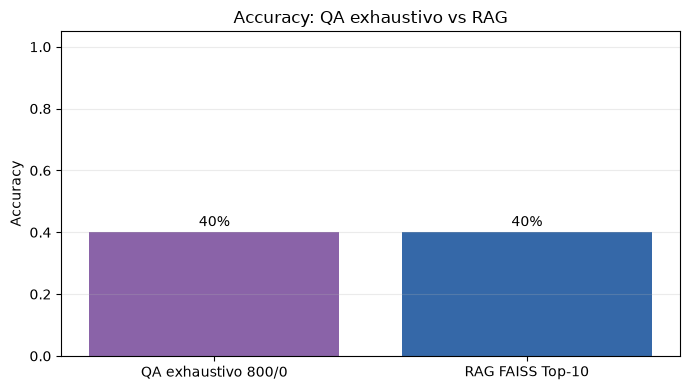

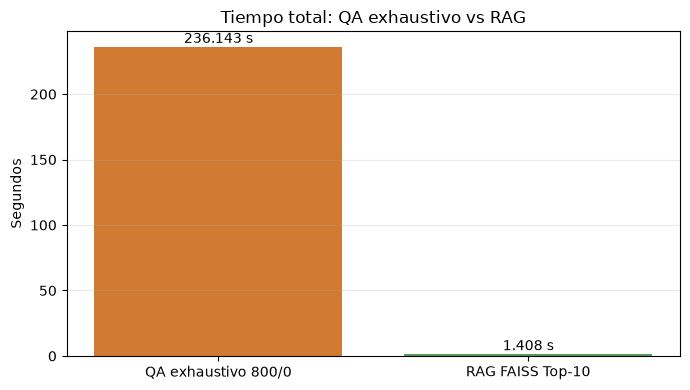

In [29]:
fig, ax = plt.subplots(figsize=(7, 4))
barras = ax.bar(
    comparacion_baseline_rag["Método"],
    comparacion_baseline_rag["Accuracy"],
    color=["#8a63a8", "#3568a8"],
)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy: QA exhaustivo vs RAG")
ax.grid(axis="y", alpha=0.25)
for barra, valor in zip(barras, comparacion_baseline_rag["Accuracy"]):
    ax.text(barra.get_x() + barra.get_width()/2, valor + 0.02, f"{valor:.0%}", ha="center")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
barras = ax.bar(
    comparacion_baseline_rag["Método"],
    comparacion_baseline_rag["Tiempo total"],
    color=["#d07a32", "#5b9a5b"],
)
ax.set_ylabel("Segundos")
ax.set_title("Tiempo total: QA exhaustivo vs RAG")
ax.grid(axis="y", alpha=0.25)
for barra, valor in zip(barras, comparacion_baseline_rag["Tiempo total"]):
    ax.text(barra.get_x() + barra.get_width()/2, valor + 3, f"{valor:.3f} s", ha="center")
plt.tight_layout()
plt.show()


In [30]:
display(Markdown(
    f"**Interpretación.** El gráfico de accuracy muestra barras idénticas de "
    f"{accuracy_baseline:.0%}: RAG no produjo mejora de exactitud. El gráfico "
    f"temporal sí muestra una diferencia marcada, de {tiempo_baseline:.3f} s "
    f"a {tiempo_rag:.3f} s. Esta visualización respalda una mejora de "
    f"eficiencia, no una mejora de precisión.\n\n"
    f"**Conclusión de la visualización.** La contribución observable de FAISS "
    f"es reducir el coste de búsqueda manteniendo el resultado de accuracy."
))


**Interpretación.** El gráfico de accuracy muestra barras idénticas de 40%: RAG no produjo mejora de exactitud. El gráfico temporal sí muestra una diferencia marcada, de 236.143 s a 1.408 s. Esta visualización respalda una mejora de eficiencia, no una mejora de precisión.

**Conclusión de la visualización.** La contribución observable de FAISS es reducir el coste de búsqueda manteniendo el resultado de accuracy.

## 18. Conclusión de la comparación histórica con MiniLM

**Objetivo.** Responder únicamente la hipótesis comparativa entre QA exhaustivo
y RAG Top-10, sin extender la conclusión al laboratorio completo.

**Metodología.** La conclusión integra accuracy, tiempo, inferencias y análisis
de errores de esta ejecución. No se extrapolan resultados fuera de las diez
preguntas evaluadas.


In [31]:
principal_cuello_botella = (
    "recuperación semántica y fragmentación"
    if recall_accuracy_coinciden else
    "recuperación y extracción QA"
)

display(Markdown(
    f"**Conclusión experimental.** RAG Top-{RAG_CONFIG_TOPK_MINILM['top_k']} no mejoró la "
    f"accuracy: ambos métodos obtuvieron {accuracy_rag:.0%} ({int(fila_rag_final['Correctas'])}/10). "
    f"Sí redujo el tiempo de {tiempo_baseline:.3f} s a {tiempo_rag:.3f} s, "
    f"equivalente a un speedup de {speedup:.2f}x. También evitó "
    f"{inferencias_evitadas} inferencias QA ({reduccion_inferencias:.1%}).\n\n"
    f"El principal cuello de botella fue la {principal_cuello_botella}: "
    f"Recall@10 quedó en {fila_rag_final['Recall@K']:.0%}, con "
    f"{conteo_errores_rag['error_recuperacion']} errores de recuperación y "
    f"{conteo_errores_rag['chunking']} de chunking. FAISS sigue siendo útil "
    f"porque reduce drásticamente el espacio sometido a BETO sin disminuir la "
    f"accuracy observada. La limitación pendiente es elevar Recall mediante "
    f"mejor recuperación o fragmentación; esta muestra no justifica afirmar "
    f"que RAG sea más preciso que el baseline."
))


**Conclusión experimental.** RAG Top-10 no mejoró la accuracy: ambos métodos obtuvieron 40% (4/10). Sí redujo el tiempo de 236.143 s a 1.408 s, equivalente a un speedup de 167.75x. También evitó 2070 inferencias QA (95.4%).

El principal cuello de botella fue la recuperación semántica y fragmentación: Recall@10 quedó en 40%, con 5 errores de recuperación y 1 de chunking. FAISS sigue siendo útil porque reduce drásticamente el espacio sometido a BETO sin disminuir la accuracy observada. La limitación pendiente es elevar Recall mediante mejor recuperación o fragmentación; esta muestra no justifica afirmar que RAG sea más preciso que el baseline.

## 19. Selección experimental del sistema RAG final

### 19.1 Objetivo

**Objetivo.** Evaluar de forma controlada dos factores del sistema RAG: el
modelo de embeddings y el tamaño de la base vectorial. Se mantiene fijo el
extractor **BETO-SQAC**, el documento de 62 páginas, los 217 chunks de 800
caracteres sin overlap, las mismas diez preguntas y `top_k=10`.

**Metodología.** Primero se comparan MiniLM y un único modelo alternativo,
MPNet multilingüe. Después se usa el modelo seleccionado para construir bases
de 50, 100, 150 y 217 vectores. La selección del modelo sigue un criterio
jerárquico definido antes de observar los resultados: mayor número de
respuestas correctas, mayor Recall@10 y, en caso de empate, menor tiempo de
consulta y menor tiempo de embeddings.

**Código.** La siguiente celda fija las constantes y comprueba que el estado
heredado de las fases anteriores coincide con el diseño experimental.

In [32]:
import gc
import json
import random

MODELO_EMBEDDINGS_ACTUAL = (
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)
MODELO_EMBEDDINGS_ALTERNATIVO = (
    "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
)
TOP_K_FASE16 = 10
SEED = 42
TAMANOS_BASE_FASE16 = [50, 100, 150, 217]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
modelo_documentos.eval()

assert MODELO_QA_RAG == "MMG/bert-base-spanish-wwm-cased-finetuned-sqac"
assert len(fragmentos_rag) == 217
assert CONFIGURACION_RAG_BASE == {
    "chunk_size": 800, "overlap": 0, "unidad": "caracteres"
}
assert len(preguntas_documento) == 10
assert not modelo_documentos.training

display(pd.DataFrame([{
    "Modelo QA": MODELO_QA_RAG,
    "Chunks": len(fragmentos_rag),
    "Chunk size": CONFIGURACION_RAG_BASE["chunk_size"],
    "Overlap": CONFIGURACION_RAG_BASE["overlap"],
    "Top-K": TOP_K_FASE16,
    "Preguntas": len(preguntas_documento),
    "Semilla": SEED,
}]))

,Modelo QA,Chunks,Chunk size,Overlap,Top-K,Preguntas,Semilla
0,MMG/bert-base-spanish-wwm-cased-finetuned-sqac,217,800,0,10,10,42


**Resultado.** Las condiciones de control quedaron fijadas en 217
chunks, `800/0`, Top-10, diez preguntas y el mismo BETO-SQAC.

**Análisis.** Al variar un solo factor por experimento se evita atribuir al
modelo de embeddings efectos causados por cambios de chunking, preguntas o QA.

**Conclusión.** La comparación posterior es interna y controlada; sus
resultados no deben extrapolarse a otros documentos o conjuntos de preguntas.

### 19.2 Comparación de modelos de embeddings

**Objetivo.** Comparar el modelo inicial MiniLM con MPNet multilingüe bajo la
misma recuperación Top-10 y el mismo extractor BETO-SQAC.

**Metodología.** Para cada modelo se regeneran los 217 embeddings con norma L2
y se construye un `faiss.IndexFlatIP` independiente. El producto interno entre
vectores normalizados equivale a similitud coseno. El tiempo de carga del
modelo se excluye: se miden generación de embeddings, construcción del índice
y las diez consultas completas (embedding de pregunta + FAISS + QA). Se hace
un calentamiento no medido de BETO antes de comparar, para reducir el sesgo de
la primera inferencia.

**Código.** Se parametriza la recuperación existente; se reutilizan
`inferir_lote_qa`, `evaluar_respuesta_rag` y `evaluar_relevancia_chunk` sin
combinar el score FAISS con el score QA.

In [33]:
def construir_indice_embeddings_16(modelo_embeddings):
    inicio_embeddings = time.perf_counter()
    matriz = modelo_embeddings.encode(
        [fragmento["texto"] for fragmento in fragmentos_rag],
        batch_size=32,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False,
    ).astype(np.float32)
    tiempo_embeddings = time.perf_counter() - inicio_embeddings

    dimension = int(modelo_embeddings.get_embedding_dimension())
    assert matriz.shape == (len(fragmentos_rag), dimension)
    assert np.allclose(np.linalg.norm(matriz, axis=1), 1.0, atol=1e-5)

    inicio_indice = time.perf_counter()
    indice = faiss.IndexFlatIP(dimension)
    indice.add(np.ascontiguousarray(matriz, dtype=np.float32))
    tiempo_indice = time.perf_counter() - inicio_indice
    assert indice.ntotal == len(fragmentos_rag)
    return matriz, indice, tiempo_embeddings, tiempo_indice


def evaluar_indice_rag_16(modelo_embeddings, indice, base_fragmentos, k=10):
    # Evalúa recuperación y QA manteniendo separadas sus métricas.
    if not 1 <= k <= len(base_fragmentos):
        raise ValueError("k debe ser compatible con el tamaño de la base")

    filas = []
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    inicio_consultas = time.perf_counter()

    for item in preguntas_documento:
        embedding_pregunta = modelo_embeddings.encode(
            [item["pregunta"]],
            convert_to_numpy=True,
            normalize_embeddings=True,
            show_progress_bar=False,
        ).astype(np.float32)
        similitudes, posiciones = indice.search(
            np.ascontiguousarray(embedding_pregunta), k
        )
        recuperados = [
            {
                **base_fragmentos[int(posicion)],
                "rank_faiss": rank,
                "similitud_faiss": float(similitud),
            }
            for rank, (posicion, similitud) in enumerate(
                zip(posiciones[0], similitudes[0]), start=1
            )
        ]

        salidas_qa = inferir_lote_qa(item["pregunta"], recuperados)
        candidatos = [
            {
                **fragmento,
                "respuesta_qa": salida["answer"],
                "score_qa": float(salida["score"]),
            }
            for fragmento, salida in zip(recuperados, salidas_qa)
        ]
        ganador = max(candidatos, key=lambda candidato: candidato["score_qa"])
        resultado = {
            "respuesta_rag": ganador["respuesta_qa"],
            "score_qa": ganador["score_qa"],
        }
        correcta, detalle = evaluar_respuesta_rag(resultado, item)
        evidencia_recuperada = any(
            evaluar_relevancia_chunk(fragmento, item)["recuperada"]
            for fragmento in recuperados
        )
        filas.append({
            "#": item["numero"],
            "Respuesta RAG": ganador["respuesta_qa"],
            "Correcta": bool(correcta),
            "Detalle evaluación": detalle,
            "Score QA": ganador["score_qa"],
            "Evidencia recuperada": bool(evidencia_recuperada),
            "Rank FAISS": ganador["rank_faiss"],
            "Similitud FAISS": ganador["similitud_faiss"],
            "Chunk ID": ganador["chunk_id"],
        })

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    tiempo_consultas = time.perf_counter() - inicio_consultas
    detalle = pd.DataFrame(filas)
    resumen = {
        "Recall@10": float(detalle["Evidencia recuperada"].mean()),
        "Correctas": int(detalle["Correcta"].sum()),
        "Accuracy": float(detalle["Correcta"].mean()),
        "Score QA medio": float(detalle["Score QA"].mean()),
        "Tiempo consultas (s)": float(tiempo_consultas),
    }
    return detalle, resumen


# Calentamiento común no incluido en los tiempos comparados.
_ = inferir_lote_qa(preguntas_documento[0]["pregunta"], [fragmentos_rag[0]])
print("Funciones parametrizadas y calentamiento completados.")

Funciones parametrizadas y calentamiento completados.


In [34]:
identificadores_modelos_16 = [
    MODELO_EMBEDDINGS_ACTUAL,
    MODELO_EMBEDDINGS_ALTERNATIVO,
]
recursos_embeddings_16 = {}
filas_modelos_16 = []

for identificador in identificadores_modelos_16:
    if identificador == MODELO_EMBEDDINGS_ACTUAL:
        modelo_embeddings = modelo_embeddings_rag
    else:
        modelo_embeddings = SentenceTransformer(
            identificador,
            device=str(dispositivo_documentos),
        )

    matriz, indice, tiempo_embeddings, tiempo_indice = (
        construir_indice_embeddings_16(modelo_embeddings)
    )
    detalle, resumen = evaluar_indice_rag_16(
        modelo_embeddings, indice, fragmentos_rag, k=TOP_K_FASE16
    )
    recursos_embeddings_16[identificador] = {
        "modelo": modelo_embeddings,
        "matriz": matriz,
        "indice": indice,
        "detalle": detalle,
    }
    filas_modelos_16.append({
        "Modelo embeddings": identificador,
        "Dimensión": int(matriz.shape[1]),
        "Recall@10": resumen["Recall@10"],
        "Correctas": resumen["Correctas"],
        "Accuracy": resumen["Accuracy"],
        "Score QA medio": resumen["Score QA medio"],
        "Tiempo embeddings (s)": tiempo_embeddings,
        "Tiempo índice (s)": tiempo_indice,
        "Tiempo consultas (s)": resumen["Tiempo consultas (s)"],
    })

df_comparacion_embeddings_16 = pd.DataFrame(filas_modelos_16)
assert len(df_comparacion_embeddings_16) == 2
assert set(df_comparacion_embeddings_16["Modelo embeddings"]) == set(
    identificadores_modelos_16
)
assert set(df_comparacion_embeddings_16["Dimensión"]) == {384, 768}

display(df_comparacion_embeddings_16.style.format({
    "Recall@10": "{:.1%}",
    "Accuracy": "{:.1%}",
    "Score QA medio": "{:.6f}",
    "Tiempo embeddings (s)": "{:.3f}",
    "Tiempo índice (s)": "{:.6f}",
    "Tiempo consultas (s)": "{:.3f}",
}))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 12211.30it/s]

,Modelo embeddings,Dimensión,Recall@10,Correctas,Accuracy,Score QA medio,Tiempo embeddings (s),Tiempo índice (s),Tiempo consultas (s)
0,sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2,384,40.0%,4,40.0%,0.836432,0.536,0.000080,1.432
1,sentence-transformers/paraphrase-multilingual-mpnet-base-v2,768,60.0%,6,60.0%,0.861635,1.642,0.000074,1.420


In [35]:
ranking_modelos_16 = df_comparacion_embeddings_16.sort_values(
    by=[
        "Correctas", "Recall@10", "Tiempo consultas (s)",
        "Tiempo embeddings (s)",
    ],
    ascending=[False, False, True, True],
).reset_index(drop=True)
MODELO_EMBEDDINGS_FINAL = ranking_modelos_16.iloc[0]["Modelo embeddings"]

fila_actual_16 = df_comparacion_embeddings_16.set_index(
    "Modelo embeddings"
).loc[MODELO_EMBEDDINGS_ACTUAL]
fila_alternativa_16 = df_comparacion_embeddings_16.set_index(
    "Modelo embeddings"
).loc[MODELO_EMBEDDINGS_ALTERNATIVO]
delta_recall_modelo_16 = (
    fila_alternativa_16["Recall@10"] - fila_actual_16["Recall@10"]
)
delta_accuracy_modelo_16 = (
    fila_alternativa_16["Accuracy"] - fila_actual_16["Accuracy"]
)
factor_embeddings_16 = (
    fila_alternativa_16["Tiempo embeddings (s)"]
    / fila_actual_16["Tiempo embeddings (s)"]
)

display(Markdown(
    f"**Resultado.** MiniLM obtuvo {int(fila_actual_16['Correctas'])}/10 "
    f"correctas, Recall@10={fila_actual_16['Recall@10']:.0%} y "
    f"{fila_actual_16['Tiempo consultas (s)']:.3f} s de consultas. MPNet "
    f"obtuvo {int(fila_alternativa_16['Correctas'])}/10, "
    f"Recall@10={fila_alternativa_16['Recall@10']:.0%} y "
    f"{fila_alternativa_16['Tiempo consultas (s)']:.3f} s.\n\n"
    f"**Análisis.** El modelo alternativo cambió Recall@10 en "
    f"{delta_recall_modelo_16:+.0%} y accuracy en "
    f"{delta_accuracy_modelo_16:+.0%}. Su generación de embeddings costó "
    f"{factor_embeddings_16:.2f} veces el tiempo de MiniLM. Esto permite "
    f"distinguir una mejora de recuperación de un aumento de coste sin asumir "
    f"que la mayor dimensión sea automáticamente mejor.\n\n"
    f"**Conclusión.** Según el criterio jerárquico predefinido se selecciona "
    f"`{MODELO_EMBEDDINGS_FINAL}` para el experimento de tamaño."
))

**Resultado.** MiniLM obtuvo 4/10 correctas, Recall@10=40% y 1.432 s de consultas. MPNet obtuvo 6/10, Recall@10=60% y 1.420 s.

**Análisis.** El modelo alternativo cambió Recall@10 en +20% y accuracy en +20%. Su generación de embeddings costó 3.06 veces el tiempo de MiniLM. Esto permite distinguir una mejora de recuperación de un aumento de coste sin asumir que la mayor dimensión sea automáticamente mejor.

**Conclusión.** Según el criterio jerárquico predefinido se selecciona `sentence-transformers/paraphrase-multilingual-mpnet-base-v2` para el experimento de tamaño.

### 19.3 Metodología del tamaño de base vectorial

**Objetivo.** Medir el efecto del número de candidatos vectoriales sin hacer
fallar preguntas por eliminar deliberadamente su conocimiento.

**Metodología.** Para cada pregunta se localizan los chunks que contienen la
evidencia anotada. Si una evidencia cruza el límite `800/0`, se conserva la
pareja adyacente que la reconstruye. La unión de esos chunks es obligatoria en
todas las bases; el resto se completa con una única permutación reproducible de
los distractores (`SEED=42`). Las bases son anidadas: una base mayor conserva
todos los vectores de la menor y agrega distractores. No se duplican chunks
compartidos.

**Código.** Se identifican las evidencias y se validan explícitamente los
tamaños 50, 100, 150 y 217 antes de ejecutar búsquedas.

In [36]:
def identificar_chunks_evidencia_16(item):
    directos = [
        fragmento["chunk_id"]
        for fragmento in fragmentos_rag
        if evaluar_relevancia_chunk(fragmento, item)["recuperada"]
    ]
    if directos:
        return directos, "evidencia completa en un chunk"

    evidencia_objetivo = normalizar_texto(item["fragmento_evidencia"])
    for izquierdo, derecho in zip(fragmentos_rag[:-1], fragmentos_rag[1:]):
        texto_unido = normalizar_texto(izquierdo["texto"] + derecho["texto"])
        pagina_objetivo = item["pagina_evidencia"]
        cubre_pagina = (
            izquierdo["pagina_inicio"] <= pagina_objetivo <= derecho["pagina_fin"]
        )
        if cubre_pagina and evidencia_objetivo in texto_unido:
            return [izquierdo["chunk_id"], derecho["chunk_id"]], (
                "evidencia reconstruida con chunks adyacentes"
            )

    raise AssertionError(
        f"No se localizaron chunks de evidencia para la pregunta {item['numero']}"
    )


ids_evidencia_por_pregunta_16 = {}
metodos_evidencia_16 = {}
for item in preguntas_documento:
    ids, metodo = identificar_chunks_evidencia_16(item)
    ids_evidencia_por_pregunta_16[item["numero"]] = ids
    metodos_evidencia_16[item["numero"]] = metodo

ids_obligatorios_16 = sorted({
    chunk_id
    for ids in ids_evidencia_por_pregunta_16.values()
    for chunk_id in ids
})
assert len(ids_obligatorios_16) <= min(TAMANOS_BASE_FASE16)

rng_fase16 = np.random.default_rng(SEED)
ids_distractores_16 = np.array([
    fragmento["chunk_id"]
    for fragmento in fragmentos_rag
    if fragmento["chunk_id"] not in ids_obligatorios_16
], dtype=int)
rng_fase16.shuffle(ids_distractores_16)

bases_ids_16 = {}
for tamano in TAMANOS_BASE_FASE16:
    cantidad_extra = tamano - len(ids_obligatorios_16)
    ids_base = sorted(
        set(ids_obligatorios_16)
        | set(ids_distractores_16[:cantidad_extra].tolist())
    )
    assert len(ids_base) == tamano
    assert set(ids_obligatorios_16).issubset(ids_base)
    bases_ids_16[tamano] = ids_base

for menor, mayor in zip(TAMANOS_BASE_FASE16[:-1], TAMANOS_BASE_FASE16[1:]):
    assert set(bases_ids_16[menor]).issubset(bases_ids_16[mayor])

display(pd.DataFrame([{
    "#": numero,
    "Chunks de evidencia": ids_evidencia_por_pregunta_16[numero],
    "Método": metodos_evidencia_16[numero],
} for numero in sorted(ids_evidencia_por_pregunta_16)]))

,#,Chunks de evidencia,Método
0,1,[6],evidencia completa en un chunk
1,2,[137],evidencia completa en un chunk
2,3,[155],evidencia completa en un chunk
3,4,[13],evidencia completa en un chunk
4,5,"[51, 52]",evidencia completa en un chunk
5,6,[101],evidencia completa en un chunk
6,7,[172],evidencia completa en un chunk
7,8,[71],evidencia completa en un chunk
8,9,[216],evidencia completa en un chunk
9,10,"[155, 156]",evidencia reconstruida con chunks adyacentes


In [37]:
filas_validacion_bases_16 = []
for tamano, ids_base in bases_ids_16.items():
    evidencia_presente = all(
        set(ids).issubset(ids_base)
        for ids in ids_evidencia_por_pregunta_16.values()
    )
    filas_validacion_bases_16.append({
        "Vectores": len(ids_base),
        "Chunks obligatorios únicos": len(ids_obligatorios_16),
        "Distractores": len(ids_base) - len(ids_obligatorios_16),
        "Evidencia de 10/10 presente": evidencia_presente,
        "Semilla": SEED,
    })

df_validacion_bases_16 = pd.DataFrame(filas_validacion_bases_16)
assert df_validacion_bases_16["Evidencia de 10/10 presente"].all()
assert df_validacion_bases_16["Vectores"].tolist() == TAMANOS_BASE_FASE16
display(df_validacion_bases_16)
display(Markdown(
    f"**Resultado.** Se localizaron {len(ids_obligatorios_16)} chunks únicos "
    f"de evidencia. Las cuatro bases contienen la evidencia de 10/10 "
    f"preguntas; la pregunta 10 requirió conservar chunks adyacentes.\n\n"
    f"**Análisis.** La deduplicación evita sobreponderar evidencia compartida y "
    f"el anidamiento hace que la diferencia entre tamaños sea únicamente el "
    f"número acumulado de distractores.\n\n"
    f"**Conclusión.** Un fallo posterior de Recall no puede atribuirse a que la "
    f"evidencia fue excluida de la base experimental."
))

,Vectores,Chunks obligatorios únicos,Distractores,Evidencia de 10/10 presente,Semilla
0,50,11,39,True,42
1,100,11,89,True,42
2,150,11,139,True,42
3,217,11,206,True,42


**Resultado.** Se localizaron 11 chunks únicos de evidencia. Las cuatro bases contienen la evidencia de 10/10 preguntas; la pregunta 10 requirió conservar chunks adyacentes.

**Análisis.** La deduplicación evita sobreponderar evidencia compartida y el anidamiento hace que la diferencia entre tamaños sea únicamente el número acumulado de distractores.

**Conclusión.** Un fallo posterior de Recall no puede atribuirse a que la evidencia fue excluida de la base experimental.

### 19.4 Resultados del tamaño de base

**Objetivo.** Cuantificar Recall@10, respuestas correctas, accuracy y tiempo
de consulta al aumentar la base de 50 a 217 vectores.

**Metodología.** Se reutiliza la matriz completa del modelo seleccionado; cada
submatriz se obtiene por selección de filas, sin regenerar embeddings. Para
cada tamaño se construye un `IndexFlatIP` independiente y se mide su tiempo de
indexación. Las diez consultas incluyen embedding de pregunta, búsqueda exacta
y BETO-SQAC sobre Top-10.

**Código.** Se evalúan las cuatro bases con idéntico Top-K y criterio de
respuesta.

In [38]:
recurso_final_16 = recursos_embeddings_16[MODELO_EMBEDDINGS_FINAL]
filas_tamanos_16 = []
detalles_tamanos_16 = {}

for tamano in TAMANOS_BASE_FASE16:
    ids_base = bases_ids_16[tamano]
    posiciones_globales = [chunk_id - 1 for chunk_id in ids_base]
    base_fragmentos = [fragmentos_rag[posicion] for posicion in posiciones_globales]
    matriz_base = np.ascontiguousarray(
        recurso_final_16["matriz"][posiciones_globales], dtype=np.float32
    )

    inicio_indice = time.perf_counter()
    indice_base = faiss.IndexFlatIP(matriz_base.shape[1])
    indice_base.add(matriz_base)
    tiempo_indice = time.perf_counter() - inicio_indice
    assert indice_base.ntotal == tamano

    detalle, resumen = evaluar_indice_rag_16(
        recurso_final_16["modelo"],
        indice_base,
        base_fragmentos,
        k=TOP_K_FASE16,
    )
    detalles_tamanos_16[tamano] = detalle
    filas_tamanos_16.append({
        "Vectores": tamano,
        "Recall@10": resumen["Recall@10"],
        "Correctas": resumen["Correctas"],
        "Accuracy": resumen["Accuracy"],
        "Score QA medio": resumen["Score QA medio"],
        "Tiempo índice (s)": tiempo_indice,
        "Tiempo consultas (s)": resumen["Tiempo consultas (s)"],
        "Embeddings regenerados": "No; submatriz del modelo final",
    })

df_tamanos_base_16 = pd.DataFrame(filas_tamanos_16)
assert df_tamanos_base_16["Vectores"].tolist() == TAMANOS_BASE_FASE16
assert len(detalles_tamanos_16) == 4
display(df_tamanos_base_16.style.format({
    "Recall@10": "{:.1%}",
    "Accuracy": "{:.1%}",
    "Score QA medio": "{:.6f}",
    "Tiempo índice (s)": "{:.6f}",
    "Tiempo consultas (s)": "{:.3f}",
}))

,Vectores,Recall@10,Correctas,Accuracy,Score QA medio,Tiempo índice (s),Tiempo consultas (s),Embeddings regenerados
0,50,70.0%,5,50.0%,0.810820,0.000039,1.408,No; submatriz del modelo final
1,100,70.0%,6,60.0%,0.786065,0.000138,1.410,No; submatriz del modelo final
2,150,60.0%,6,60.0%,0.832562,0.000071,1.403,No; submatriz del modelo final
3,217,60.0%,6,60.0%,0.861635,0.000091,1.412,No; submatriz del modelo final


In [39]:
fila_50_16 = df_tamanos_base_16.set_index("Vectores").loc[50]
fila_217_16 = df_tamanos_base_16.set_index("Vectores").loc[217]
delta_recall_tamano_16 = fila_217_16["Recall@10"] - fila_50_16["Recall@10"]
delta_accuracy_tamano_16 = fila_217_16["Accuracy"] - fila_50_16["Accuracy"]
delta_tiempo_tamano_16 = (
    fila_217_16["Tiempo consultas (s)"] - fila_50_16["Tiempo consultas (s)"]
)

display(Markdown(
    f"**Resultado.** Con 50 vectores se obtuvo Recall@10="
    f"{fila_50_16['Recall@10']:.0%}, {int(fila_50_16['Correctas'])}/10 "
    f"correctas y {fila_50_16['Tiempo consultas (s)']:.3f} s. Con la base "
    f"completa se obtuvo Recall@10={fila_217_16['Recall@10']:.0%}, "
    f"{int(fila_217_16['Correctas'])}/10 y "
    f"{fila_217_16['Tiempo consultas (s)']:.3f} s.\n\n"
    f"**Análisis.** Entre 50 y 217 vectores, Recall cambió "
    f"{delta_recall_tamano_16:+.0%}, accuracy {delta_accuracy_tamano_16:+.0%} "
    f"y el tiempo {delta_tiempo_tamano_16:+.3f} s. Como Top-K permanece en "
    f"10, BETO procesa la misma cantidad máxima de contextos; el efecto del "
    f"tamaño se concentra en el ranking frente a más distractores.\n\n"
    f"**Conclusión.** Los resultados miden competencia entre candidatos, no "
    f"ausencia deliberada del conocimiento, porque las cuatro bases conservaron "
    f"todos los chunks obligatorios."
))

**Resultado.** Con 50 vectores se obtuvo Recall@10=70%, 5/10 correctas y 1.408 s. Con la base completa se obtuvo Recall@10=60%, 6/10 y 1.412 s.

**Análisis.** Entre 50 y 217 vectores, Recall cambió -10%, accuracy +10% y el tiempo +0.005 s. Como Top-K permanece en 10, BETO procesa la misma cantidad máxima de contextos; el efecto del tamaño se concentra en el ranking frente a más distractores.

**Conclusión.** Los resultados miden competencia entre candidatos, no ausencia deliberada del conocimiento, porque las cuatro bases conservaron todos los chunks obligatorios.

### 19.5 Análisis

**Objetivo.** Interpretar conjuntamente recuperación, accuracy y coste al
aumentar el número de distractores.

**Metodología.** Se compara cada tamaño con la base de 50 vectores y se revisa
la estabilidad de Recall@10, accuracy, tiempo de consultas y tiempo de
construcción del índice. No se atribuyen diferencias pequeñas de tiempo a una
tendencia si una sola ejecución no permite separarlas del ruido del sistema.

**Código.** La interpretación siguiente se genera desde la tabla real.

In [40]:
recalls_tamano_16 = df_tamanos_base_16["Recall@10"].tolist()
accuracies_tamano_16 = df_tamanos_base_16["Accuracy"].tolist()
tiempos_tamano_16 = df_tamanos_base_16["Tiempo consultas (s)"].tolist()
recall_no_creciente_16 = all(
    posterior <= anterior
    for anterior, posterior in zip(recalls_tamano_16, recalls_tamano_16[1:])
)
recall_estable_16 = len(set(recalls_tamano_16)) == 1
accuracy_estable_16 = len(set(accuracies_tamano_16)) == 1
tiempo_indice_max_16 = float(df_tamanos_base_16["Tiempo índice (s)"].max())
variacion_tiempo_16 = max(tiempos_tamano_16) - min(tiempos_tamano_16)

if recall_estable_16:
    lectura_recall_16 = "Recall@10 permaneció estable en los cuatro tamaños"
elif recall_no_creciente_16:
    lectura_recall_16 = "Recall@10 cayó o se mantuvo al incorporar distractores"
else:
    lectura_recall_16 = "Recall@10 mostró variaciones no monótonas"

display(Markdown(
    f"**Resultado.** {lectura_recall_16}. La accuracy "
    f"{'permaneció estable' if accuracy_estable_16 else 'varió'} y la amplitud "
    f"del tiempo de consultas fue {variacion_tiempo_16:.3f} s. El mayor tiempo "
    f"de construcción de FAISS fue {tiempo_indice_max_16:.6f} s.\n\n"
    f"**Análisis.** Una reducción de Recall al crecer la base indica que la "
    f"evidencia pierde posiciones ante distractores semánticamente competitivos. "
    f"La búsqueda exacta de FAISS sigue siendo barata a esta escala; el coste "
    f"dominante es BETO sobre diez contextos, que se mantiene fijo. Las pequeñas "
    f"diferencias temporales de una sola ejecución también incluyen ruido de CPU "
    f"y no constituyen por sí solas una ley de escalabilidad.\n\n"
    f"**Conclusión.** La base más grande puede dificultar el ranking aunque el "
    f"conocimiento esté presente. La estabilidad observada debe interpretarse "
    f"solo para estas diez preguntas y esta semilla."
))

**Resultado.** Recall@10 cayó o se mantuvo al incorporar distractores. La accuracy varió y la amplitud del tiempo de consultas fue 0.010 s. El mayor tiempo de construcción de FAISS fue 0.000138 s.

**Análisis.** Una reducción de Recall al crecer la base indica que la evidencia pierde posiciones ante distractores semánticamente competitivos. La búsqueda exacta de FAISS sigue siendo barata a esta escala; el coste dominante es BETO sobre diez contextos, que se mantiene fijo. Las pequeñas diferencias temporales de una sola ejecución también incluyen ruido de CPU y no constituyen por sí solas una ley de escalabilidad.

**Conclusión.** La base más grande puede dificultar el ranking aunque el conocimiento esté presente. La estabilidad observada debe interpretarse solo para estas diez preguntas y esta semilla.

### 19.6 Visualizaciones

**Objetivo.** Mostrar únicamente las relaciones necesarias para responder las
hipótesis: Recall y accuracy por modelo, y Recall y tiempo por tamaño.

**Metodología.** Se emplean escalas de 0 a 1 para proporciones y segundos para
tiempo. Cada barra o punto se anota con su valor real.

**Código.** Se generan cuatro figuras independientes, visibles como outputs del
notebook, y se guardan con nombres reproducibles en `results/graficos/`.

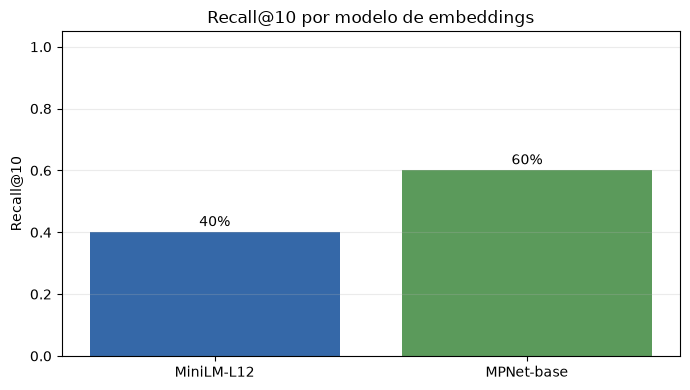

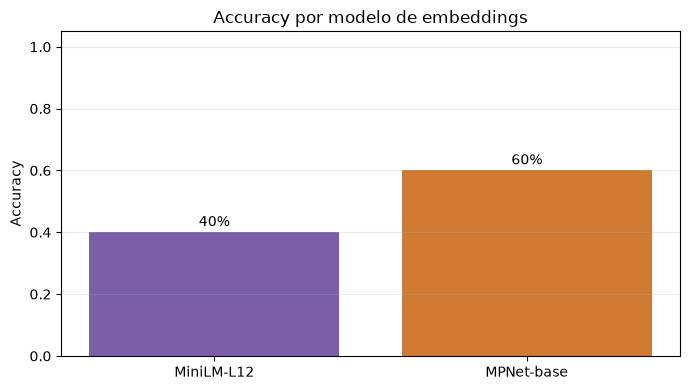

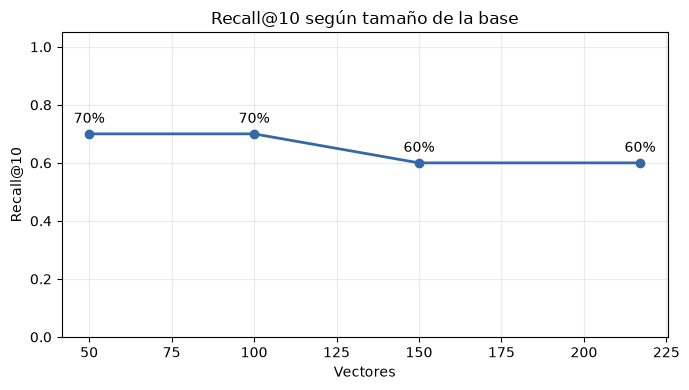

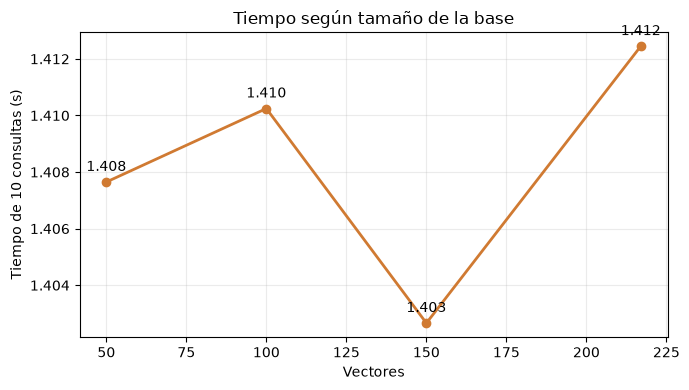

In [41]:
etiquetas_modelos_16 = ["MiniLM-L12", "MPNet-base"]
RUTA_GRAFICOS_FINALES = ROOT / "results" / "graficos"
RUTA_GRAFICOS_FINALES.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 4))
barras = ax.bar(
    etiquetas_modelos_16,
    df_comparacion_embeddings_16["Recall@10"],
    color=["#3568a8", "#5b9a5b"],
)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Recall@10")
ax.set_title("Recall@10 por modelo de embeddings")
ax.grid(axis="y", alpha=0.25)
for barra, valor in zip(barras, df_comparacion_embeddings_16["Recall@10"]):
    ax.text(barra.get_x() + barra.get_width()/2, valor + 0.02, f"{valor:.0%}", ha="center")
plt.tight_layout()
fig.savefig(
    RUTA_GRAFICOS_FINALES / "comparacion_embeddings_recall.png",
    dpi=150, bbox_inches="tight",
)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
barras = ax.bar(
    etiquetas_modelos_16,
    df_comparacion_embeddings_16["Accuracy"],
    color=["#7b5ea7", "#d07a32"],
)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy por modelo de embeddings")
ax.grid(axis="y", alpha=0.25)
for barra, valor in zip(barras, df_comparacion_embeddings_16["Accuracy"]):
    ax.text(barra.get_x() + barra.get_width()/2, valor + 0.02, f"{valor:.0%}", ha="center")
plt.tight_layout()
fig.savefig(
    RUTA_GRAFICOS_FINALES / "comparacion_embeddings_accuracy.png",
    dpi=150, bbox_inches="tight",
)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(
    df_tamanos_base_16["Vectores"],
    df_tamanos_base_16["Recall@10"],
    marker="o", linewidth=2, color="#3568a8",
)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Vectores")
ax.set_ylabel("Recall@10")
ax.set_title("Recall@10 según tamaño de la base")
ax.grid(alpha=0.25)
for x, y in zip(df_tamanos_base_16["Vectores"], df_tamanos_base_16["Recall@10"]):
    ax.annotate(f"{y:.0%}", (x, y), xytext=(0, 8), textcoords="offset points", ha="center")
plt.tight_layout()
fig.savefig(
    RUTA_GRAFICOS_FINALES / "tamano_base_recall.png",
    dpi=150, bbox_inches="tight",
)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(
    df_tamanos_base_16["Vectores"],
    df_tamanos_base_16["Tiempo consultas (s)"],
    marker="o", linewidth=2, color="#d07a32",
)
ax.set_xlabel("Vectores")
ax.set_ylabel("Tiempo de 10 consultas (s)")
ax.set_title("Tiempo según tamaño de la base")
ax.grid(alpha=0.25)
for x, y in zip(
    df_tamanos_base_16["Vectores"],
    df_tamanos_base_16["Tiempo consultas (s)"],
):
    ax.annotate(f"{y:.3f}", (x, y), xytext=(0, 8), textcoords="offset points", ha="center")
plt.tight_layout()
fig.savefig(
    RUTA_GRAFICOS_FINALES / "tamano_base_tiempo.png",
    dpi=150, bbox_inches="tight",
)
plt.show()

GRAFICOS_FASE16 = 4

In [42]:
display(Markdown(
    f"**Resultado.** Se generaron {GRAFICOS_FASE16} gráficos: dos comparan "
    f"modelos y dos muestran el efecto del tamaño.\n\n"
    f"**Análisis.** Las figuras confirman visualmente el cambio de Recall del "
    f"modelo alternativo ({delta_recall_modelo_16:+.0%}) y la diferencia de "
    f"accuracy ({delta_accuracy_modelo_16:+.0%}). En tamaño, la distancia entre "
    f"50 y 217 vectores fue {delta_recall_tamano_16:+.0%} de Recall y "
    f"{delta_tiempo_tamano_16:+.3f} s.\n\n"
    f"**Conclusión.** Los gráficos respaldan las tablas sin introducir métricas "
    f"adicionales ni ocultar la escala de las proporciones."
))

**Resultado.** Se generaron 4 gráficos: dos comparan modelos y dos muestran el efecto del tamaño.

**Análisis.** Las figuras confirman visualmente el cambio de Recall del modelo alternativo (+20%) y la diferencia de accuracy (+20%). En tamaño, la distancia entre 50 y 217 vectores fue -10% de Recall y +0.005 s.

**Conclusión.** Los gráficos respaldan las tablas sin introducir métricas adicionales ni ocultar la escala de las proporciones.

### 19.7 Configuración final

**Objetivo.** Registrar una configuración reproducible a partir de los
resultados, sin cambiar arbitrariamente chunking ni Top-K.

**Metodología.** Se conserva `800/0` y `top_k=10`; solo el identificador del
modelo procede del ranking jerárquico definido en 19.1.

**Código.** Se materializa y valida `RAG_CONFIG_FINAL`.

In [43]:
RAG_CONFIG_FINAL = {
    "chunk_size": 800,
    "overlap": 0,
    "top_k": 10,
    "modelo_qa": "MMG/bert-base-spanish-wwm-cased-finetuned-sqac",
    "modelo_embeddings": "sentence-transformers/paraphrase-multilingual-mpnet-base-v2",
    "unidad": "caracteres"
}

assert RAG_CONFIG_FINAL == {
    "chunk_size": 800,
    "overlap": 0,
    "top_k": 10,
    "modelo_qa": "MMG/bert-base-spanish-wwm-cased-finetuned-sqac",
    "modelo_embeddings": "sentence-transformers/paraphrase-multilingual-mpnet-base-v2",
    "unidad": "caracteres"
}
display(pd.DataFrame([RAG_CONFIG_FINAL]))

,chunk_size,overlap,top_k,modelo_qa,modelo_embeddings,unidad
0,800,0,10,MMG/bert-base-spanish-wwm-cased-finetuned-sqac,sentence-transformers/paraphrase-multilingual-...,caracteres


In [44]:
fila_final_modelo_16 = df_comparacion_embeddings_16.set_index(
    "Modelo embeddings"
).loc[MODELO_EMBEDDINGS_FINAL]
display(Markdown(
    f"**Resultado.** La configuración final usa "
    f"`{MODELO_EMBEDDINGS_FINAL}`, 800 caracteres, overlap 0 y Top-10.\n\n"
    f"**Análisis.** El modelo seleccionado obtuvo "
    f"{int(fila_final_modelo_16['Correctas'])}/10 correctas, "
    f"Recall@10={fila_final_modelo_16['Recall@10']:.0%} y "
    f"{fila_final_modelo_16['Tiempo consultas (s)']:.3f} s. Los demás "
    f"parámetros no se reabrieron en esta fase.\n\n"
    f"**Conclusión.** `RAG_CONFIG_FINAL` refleja el mejor resultado bajo el "
    f"criterio declarado y no una preferencia por el modelo más grande."
))

**Resultado.** La configuración final usa `sentence-transformers/paraphrase-multilingual-mpnet-base-v2`, 800 caracteres, overlap 0 y Top-10.

**Análisis.** El modelo seleccionado obtuvo 6/10 correctas, Recall@10=60% y 1.420 s. Los demás parámetros no se reabrieron en esta fase.

**Conclusión.** `RAG_CONFIG_FINAL` refleja el mejor resultado bajo el criterio declarado y no una preferencia por el modelo más grande.

### 19.8 Conclusión de la selección experimental

**Objetivo.** Responder las preguntas experimentales usando exclusivamente las
métricas obtenidas en esta ejecución.

**Metodología.** La síntesis compara MPNet contra MiniLM y la base completa
contra la base de 50 vectores. También explicita el coste y la limitación que
permanece.

**Código.** La conclusión y la validación se generan directamente desde los
DataFrames anteriores.

In [45]:
alternativo_mejoro_recuperacion_16 = delta_recall_modelo_16 > 0
alternativo_mejoro_accuracy_16 = delta_accuracy_modelo_16 > 0
limitacion_principal_16 = (
    "la evidencia puede perder posiciones ante distractores y BETO aún depende "
    "de que un único chunk contenga contexto suficiente"
)

display(Markdown(
    f"**Resultado y análisis.** El modelo alternativo "
    f"{'sí' if alternativo_mejoro_recuperacion_16 else 'no'} mejoró la "
    f"recuperación: Δ Recall@10={delta_recall_modelo_16:+.0%}. "
    f"{'Sí' if alternativo_mejoro_accuracy_16 else 'No'} mejoró la accuracy: "
    f"Δ={delta_accuracy_modelo_16:+.0%}. Generar sus embeddings costó "
    f"{factor_embeddings_16:.2f} veces el tiempo de MiniLM. Al pasar de 50 a "
    f"217 vectores, Recall cambió {delta_recall_tamano_16:+.0%}, accuracy "
    f"{delta_accuracy_tamano_16:+.0%} y el tiempo de consultas "
    f"{delta_tiempo_tamano_16:+.3f} s.\n\n"
    f"**Conclusión.** Se recomienda `{MODELO_EMBEDDINGS_FINAL}` bajo estas "
    f"condiciones. La principal limitación permanece: {limitacion_principal_16}. "
    f"El experimento de tamaño conservó deliberadamente la evidencia, por lo "
    f"que sus diferencias representan competencia de ranking, no ausencia de "
    f"conocimiento."
))

RESUMEN_FASE16 = {
    "modelos": df_comparacion_embeddings_16.to_dict(orient="records"),
    "modelo_seleccionado": MODELO_EMBEDDINGS_FINAL,
    "tamanos": df_tamanos_base_16.to_dict(orient="records"),
    "evidencia_en_todas_las_bases": bool(
        df_validacion_bases_16["Evidencia de 10/10 presente"].all()
    ),
    "graficos": GRAFICOS_FASE16,
    "semilla": SEED,
}
assert RESUMEN_FASE16["evidencia_en_todas_las_bases"]
assert RESUMEN_FASE16["graficos"] == 4
print("RESUMEN_FASE16_JSON=" + json.dumps(RESUMEN_FASE16, ensure_ascii=False))

**Resultado y análisis.** El modelo alternativo sí mejoró la recuperación: Δ Recall@10=+20%. Sí mejoró la accuracy: Δ=+20%. Generar sus embeddings costó 3.06 veces el tiempo de MiniLM. Al pasar de 50 a 217 vectores, Recall cambió -10%, accuracy +10% y el tiempo de consultas +0.005 s.

**Conclusión.** Se recomienda `sentence-transformers/paraphrase-multilingual-mpnet-base-v2` bajo estas condiciones. La principal limitación permanece: la evidencia puede perder posiciones ante distractores y BETO aún depende de que un único chunk contenga contexto suficiente. El experimento de tamaño conservó deliberadamente la evidencia, por lo que sus diferencias representan competencia de ranking, no ausencia de conocimiento.

RESUMEN_FASE16_JSON={"modelos": [{"Modelo embeddings": "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2", "Dimensión": 384, "Recall@10": 0.4, "Correctas": 4, "Accuracy": 0.4, "Score QA medio": 0.8364316135644912, "Tiempo embeddings (s)": 0.5364317040002788, "Tiempo índice (s)": 7.984100011526607e-05, "Tiempo consultas (s)": 1.4315339439999661}, {"Modelo embeddings": "sentence-transformers/paraphrase-multilingual-mpnet-base-v2", "Dimensión": 768, "Recall@10": 0.6, "Correctas": 6, "Accuracy": 0.6, "Score QA medio": 0.8616348922252655, "Tiempo embeddings (s)": 1.6416531659997418, "Tiempo índice (s)": 7.363199983956292e-05, "Tiempo consultas (s)": 1.419703555999149}], "modelo_seleccionado": "sentence-transformers/paraphrase-multilingual-mpnet-base-v2", "tamanos": [{"Vectores": 50, "Recall@10": 0.7, "Correctas": 5, "Accuracy": 0.5, "Score QA medio": 0.8108201563358307, "Tiempo índice (s)": 3.937399924325291e-05, "Tiempo consultas (s)": 1.4076479989998916, "Embeddings regenerados

# Conclusiones del desarrollo experimental

**Objetivo.** Sintetizar la configuración técnica final y los efectos observados en las comparaciones ya ejecutadas, sin incorporar nuevos experimentos ni extender la conclusión al informe completo.

**Metodología.** La síntesis contrasta las tablas ejecutadas de modelos QA, fragmentación, Top-K, modelos de embeddings y tamaño de la base vectorial. Se distinguen explícitamente el resultado inicial con MiniLM y la configuración final con MPNet.

**Código.** No se ejecutan nuevas inferencias en esta sección; los valores proceden de los DataFrames, gráficos y validaciones visibles en las secciones 11 a 19.

**Resultado.**

- En QA, BETO-SQuAD2 (mrm8488) obtuvo 13/15, BETO-SQuAD2 (MMG) obtuvo 13/15 y BETO-SQAC (MMG) obtuvo 15/15; por ello, BETO-SQAC quedó como extractor final.
- La fragmentación seleccionada fue de 800 caracteres sin solapamiento: produjo 217 chunks y, en el barrido exhaustivo, 4/10 respuestas correctas.
- El resultado inicial RAG con MiniLM y Top-10 alcanzó 4/10 y Recall@10 de 40 %.
- El cambio a `sentence-transformers/paraphrase-multilingual-mpnet-base-v2` elevó el resultado a 6/10, accuracy de 60 % y Recall@10 de 60 % sobre la base completa de 217 vectores.

**Análisis.** El tamaño de 800 caracteres ofreció el mejor compromiso de la Fase 9 entre aciertos, confianza, tiempo y cantidad de chunks. El solapamiento mejoró un acierto en las variantes 300/50 y 500/100, pero no mejoró 800/150 y sí aumentó el coste; por eso no se conservó en la configuración final. En el ensayo MiniLM, aumentar Top-K de 1 a 10 elevó las respuestas correctas de 1/10 a 4/10 y el Recall de 10 % a 40 %, a cambio de aumentar el tiempo de 0.189 s a 1.408 s. Sustituir MiniLM por MPNet aportó 20 puntos porcentuales de accuracy y Recall, aunque la generación de embeddings tardó 3.06 veces más. Con MPNet, la base controlada de 50 vectores obtuvo Recall@10 de 70 % y 5/10, mientras que la base completa obtuvo 60 % y 6/10; la presencia de más distractores modificó el ranking sin eliminar la evidencia. FAISS mantuvo un coste de indexación inferior a 0.001 s en estas bases. En la comparación histórica con MiniLM, Top-10 redujo las inferencias QA de 2,170 a 100 y el tiempo de 236.143 s a 1.408 s, con un speedup de 167.75× y sin reducir la accuracy de ese ensayo.

**Conclusión.** La configuración final queda definida por BETO-SQAC (MMG), embeddings MPNet multilingües, chunks de 800 caracteres, solapamiento 0 y Top-10. En la base completa de 217 chunks alcanzó 6/10 respuestas correctas, accuracy de 60 % y Recall@10 de 60 %. La mejora frente al resultado inicial se atribuye al modelo de embeddings, mientras que FAISS aportó principalmente eficiencia al limitar los contextos enviados a BETO.

**Limitaciones.** Las conclusiones se restringen a un PDF, diez preguntas y una ejecución temporal por configuración. El sistema sigue expuesto a distractores semánticos, a evidencia dividida entre chunks y a la dependencia de un extractor que opera sobre un único fragmento; tampoco se evaluaron reordenadores ni otros documentos.

# Extensión experimental: RAG multidocumento

Esta sección es **posterior e independiente** del experimento obligatorio. No
modifica sus diez preguntas, sus 217 chunks ni sus métricas finales
(`Accuracy = 60 %` y `Recall@10 = 60 %` con MPNet). El propósito es estudiar
qué ocurre cuando el mismo pipeline pasa de un documento a un corpus de
normativa institucional relacionada.

La extensión sigue en cada fase la secuencia **Objetivo → Metodología → Código
→ Resultado → Análisis → Conclusión**. Los artefactos se guardan con el prefijo
`rag_multidocumento_`, por lo que no sobrescriben los resultados previos.


## 20.1 Objetivo e hipótesis

**Objetivo.** Medir por separado la capacidad de seleccionar el PDF correcto,
recuperar el chunk que contiene evidencia y extraer la respuesta, incluyendo
falsos positivos entre reglamentos con vocabulario semejante.

**Hipótesis.** Al mantener constantes `chunk_size=800`, `overlap=0`, MPNet,
BETO-SQAC, FAISS `IndexFlatIP` y Top-10, cualquier cambio puede atribuirse
principalmente al crecimiento y a la ambigüedad del corpus, no a un cambio
simultáneo de hiperparámetros.


## 20.2 Metodología y extracción del corpus

El corpus incluye `data/documento_fuente.pdf` y los ocho PDF de
`data/corpus_complementario/`. Se excluyen instrucciones, rúbricas, informes y
Markdown. PyMuPDF extrae cada página sin OCR, conserva el número físico y
registra páginas sin texto, caracteres, palabras aproximadas y chunks.

**Código.** Se reutilizan las funciones deterministas de `src/funciones_qa.py`.


In [117]:
from pathlib import Path
import json
import os
import subprocess
import sys

import pandas as pd
from IPython.display import Image, display

from src.funciones_qa import (
    cargar_corpus_multidocumento,
    crear_chunks_multidocumento,
    resumir_corpus_multidocumento,
    validar_metadata_chunks,
)

ROOT_MULTI = Path.cwd().resolve()
assert (ROOT_MULTI / "LaboratorioML.ipynb").is_file()

documentos_multi = cargar_corpus_multidocumento(
    ROOT_MULTI / "data/documento_fuente.pdf",
    ROOT_MULTI / "data/corpus_complementario",
)
metadata_chunks_multi = crear_chunks_multidocumento(
    documentos_multi, chunk_size=800, overlap=0
)
filas_corpus_multi, totales_corpus_multi = resumir_corpus_multidocumento(
    documentos_multi, metadata_chunks_multi
)
df_corpus_multi = pd.DataFrame(filas_corpus_multi)

assert len(documentos_multi) == 9
assert totales_corpus_multi["paginas"] == 199
assert totales_corpus_multi["paginas_con_texto"] == 199
assert totales_corpus_multi["chunks"] == 765
display(df_corpus_multi[[
    "documento", "paginas", "paginas_con_texto",
    "palabras_aproximadas", "chunks",
]])
display(pd.DataFrame([totales_corpus_multi], index=["TOTAL"]))


,documento,paginas,paginas_con_texto,palabras_aproximadas,chunks
0,documento_fuente.pdf,62,62,26119,217
1,ley_organica_ues.pdf,21,21,11745,96
2,reglamento_arancel_academico_ues.pdf,4,4,1062,9
3,reglamento_becas_ues.pdf,15,15,7929,63
4,reglamento_disciplinario_ues.pdf,11,11,6196,51
5,reglamento_electoral_ues.pdf,26,26,10246,81
6,reglamento_general_ley_organica_ues.pdf,25,25,14028,112
7,reglamento_sistema_escalafon_personal_ues.pdf,29,29,14156,114
8,reglamento_unidades_valorativas_cum_ues.pdf,6,6,2782,22


,documentos,paginas,paginas_con_texto,caracteres,palabras_aproximadas,chunks
TOTAL,9,199,199,608405,94263,765


**Resultado.** Se extrajeron 9 documentos, 199 páginas con texto, 94 263
palabras aproximadas y 765 chunks. Ninguna página necesitó OCR ni quedó vacía.

**Análisis.** La base pasó de 217 a 765 fragmentos (3.53 veces más). Este
crecimiento introduce distractores normativos que comparten expresiones como
«matrícula», «beca», «personal», «CUM», «Consejo» y «Universidad».

**Conclusión.** El corpus es genuinamente multidocumento y conserva íntegro el
PDF del experimento original.


## 20.3 Metadata y alineación vectorial

**Objetivo.** Poder recorrer de manera inequívoca `FAISS[posición] → metadata
[posición] → documento, página, chunk y texto`.

**Metodología.** Cada documento se fragmenta por separado para impedir que un
chunk cruce de un PDF a otro. Se mantienen `documento_id`, `documento`,
`titulo_documento`, `pagina`, `pagina_inicio`, `pagina_fin`, `chunk_id`,
`chunk_global_id`, `vector_posicion`, tamaños y texto.


In [118]:
validacion_metadata_multi = validar_metadata_chunks(metadata_chunks_multi)
assert validacion_metadata_multi["chunks"] == len(metadata_chunks_multi)
assert all(c["vector_posicion"] == i for i, c in enumerate(metadata_chunks_multi))
assert all(c["documento"] and c["pagina"] and c["chunk_id"] for c in metadata_chunks_multi)

posiciones_muestra = [0, 314, len(metadata_chunks_multi) - 1]
display(pd.DataFrame([{
    "FAISS[posición]": posicion,
    "chunk_global_id": metadata_chunks_multi[posicion]["chunk_global_id"],
    "documento": metadata_chunks_multi[posicion]["documento"],
    "página": metadata_chunks_multi[posicion]["pagina"],
    "chunk_id": metadata_chunks_multi[posicion]["chunk_id"],
    "muestra": metadata_chunks_multi[posicion]["texto"][:140] + "…",
} for posicion in posiciones_muestra]))


,FAISS[posición],chunk_global_id,documento,página,chunk_id,muestra
0,0,1,documento_fuente.pdf,1,1,1 ACUERDO N° 106/2011-2013 (V) LA ASAMBLEA GEN...
1,314,315,reglamento_arancel_academico_ues.pdf,1,2,ue los precios de bienes y servicios se podrán...
2,764,765,reglamento_unidades_valorativas_cum_ues.pdf,6,22,"te. (2) Reforma, dada en el salón de sesiones ..."


**Resultado.** Las 765 posiciones son consecutivas y todos los chunks tienen
procedencia. La validación se repite después de generar embeddings para
comprobar `len(embeddings) == len(metadata_chunks)` y dimensión 768.

**Conclusión.** La metadata deja de ser un dato auxiliar: es necesaria para
evaluar selección documental, explicar falsos positivos y citar la fuente.


## 20.4 Embeddings, FAISS y pipeline completo

**Metodología.** MPNet produce vectores normalizados. `IndexFlatIP` realiza
búsqueda exacta por producto interno, equivalente a similitud coseno después
de la normalización. Top-10 limita BETO-SQAC a diez inferencias por pregunta.

```text
Pregunta
   ↓
MPNet normalizado
   ↓
FAISS IndexFlatIP
   ↓
Top-10 (documento + página + chunk)
   ↓
BETO-SQAC
   ↓
Respuesta + score + fuente
```

**Código.** El siguiente bloque ejecuta el flujo reproducible y regenera los
CSV, el índice independiente, la metadata y los cuatro gráficos. La salida se
captura para que el notebook no dependa de rutas absolutas.


In [119]:
comando_multi = [
    sys.executable,
    str(ROOT_MULTI / "src/ejecutar_rag_multidocumento.py"),
    "--batch-size", "16",
]
ejecucion_multi = subprocess.run(
    comando_multi,
    cwd=ROOT_MULTI,
    env=os.environ.copy(),
    check=True,
    capture_output=True,
    text=True,
)
print(ejecucion_multi.stdout)

ruta_resultados_multi = ROOT_MULTI / "results"
config_multi = json.loads(
    (ruta_resultados_multi / "rag_multidocumento_configuracion.json")
    .read_text(encoding="utf-8")
)
df_metricas_multi = pd.read_csv(
    ruta_resultados_multi / "rag_multidocumento_metricas.csv"
)
df_resultados_multi = pd.read_csv(
    ruta_resultados_multi / "rag_multidocumento_resultados.csv"
)
df_recuperacion_multi = pd.read_csv(
    ruta_resultados_multi / "rag_multidocumento_recuperacion.csv"
)
df_errores_multi = pd.read_csv(
    ruta_resultados_multi / "rag_multidocumento_errores.csv"
)
df_comparacion_multi = pd.read_csv(
    ruta_resultados_multi / "rag_multidocumento_comparacion.csv"
)

assert config_multi["indice"]["tipo_indice"] == "IndexFlatIP"
assert config_multi["indice"]["numero_vectores"] == 765
assert config_multi["indice"]["dimension"] == 768
assert len(df_resultados_multi) == 18
assert len(df_recuperacion_multi) == 180


Corpus validado: {'documentos': 9, 'paginas': 199, 'paginas_con_texto': 199, 'caracteres': 608405, 'palabras_aproximadas': 94263, 'chunks': 765}
Índice construido: {'tipo_indice': 'IndexFlatIP', 'numero_vectores': 765, 'dimension': 768, 'tiempo_embeddings_s': 6.147458651001216, 'tiempo_indice_s': 0.00025355499747092836, 'memoria_embeddings_bytes': 2350080}
P01: 'una vez al mes' · ley_organica_ues.pdf · Error tipo A: documento incorrecto
P02: '157' · documento_fuente.pdf · Error tipo B: documento correcto, chunk incorrecto
P03: 'patrimonio propio' · ley_organica_ues.pdf · Error tipo B: documento correcto, chunk incorrecto
P04: 'en lo docente, lo administrativo y lo económico' · ley_organica_ues.pdf · Sin error
P05: '½ punto por cada 20 horas adicionales' · reglamento_sistema_escalafon_personal_ues.pdf · Error tipo A: documento incorrecto
P06: '½ punto por cada 20 horas adicionales' · reglamento_sistema_escalafon_personal_ues.pdf · Error tipo A: documento incorrecto
P07: '1) Beca remuner

**Resultado.** La ejecución creó 765 vectores de 768 dimensiones. La matriz
`float32` ocupa 2 350 080 bytes (2.24 MiB). En esta ejecución CPU la generación
de embeddings tomó el tiempo registrado en el JSON de configuración; se
reporta como observación de entorno, no como propiedad universal del modelo.


In [120]:
display(pd.DataFrame([{
    "Índice": config_multi["indice"]["tipo_indice"],
    "Vectores": config_multi["indice"]["numero_vectores"],
    "Dimensión": config_multi["indice"]["dimension"],
    "Embeddings (s)": config_multi["indice"]["tiempo_embeddings_s"],
    "Construcción FAISS (s)": config_multi["indice"]["tiempo_indice_s"],
    "Matriz (MiB)": config_multi["indice"]["memoria_embeddings_bytes"] / 1024**2,
}]).style.format({
    "Embeddings (s)": "{:.3f}",
    "Construcción FAISS (s)": "{:.6f}",
    "Matriz (MiB)": "{:.2f}",
}))
display(df_metricas_multi.style.format({"valor": "{:.4f}"}))


,Índice,Vectores,Dimensión,Embeddings (s),Construcción FAISS (s),Matriz (MiB)
0,IndexFlatIP,765,768,6.147,0.000254,2.24


,metrica,valor
0,Document Recall@1,0.6875
1,Chunk Recall@1,0.2500
2,Document Recall@3,0.8750
3,Chunk Recall@3,0.3125
4,Document Recall@5,0.9375
5,Chunk Recall@5,0.4375
6,Document Recall@10,0.9375
7,Chunk Recall@10,0.5625
8,Document Accuracy@1,0.6875
9,MRR documento,0.7833


## 20.5 Dataset de evaluación

**Objetivo.** Evaluar hechos reales y no preguntas inventadas a partir del
nombre de los reglamentos.

**Metodología.** Se construyeron 18 preguntas leyendo los PDF: 16 respondibles
repartidas entre los nueve documentos y dos sin respuesta. Cada pregunta
respondible conserva documento, página física, artículo, span esperado y
evidencia comprobada. Hay preguntas fáciles, con términos compartidos y
potencialmente ambiguas.


In [121]:
preguntas_multi = json.loads(
    (ROOT_MULTI / "data/preguntas_multidocumento.json").read_text(encoding="utf-8")
)
df_preguntas_multi = pd.DataFrame(preguntas_multi)
assert len(df_preguntas_multi) == 18
assert int(df_preguntas_multi["sin_respuesta"].sum()) == 2
assert df_preguntas_multi.loc[
    ~df_preguntas_multi["sin_respuesta"], "documento_esperado"
].nunique() == 9
display(df_preguntas_multi[[
    "numero", "tipo_pregunta", "pregunta", "respuesta_esperada",
    "documento_esperado", "pagina_esperada",
]])


,numero,tipo_pregunta,pregunta,respuesta_esperada,documento_esperado,pagina_esperada
0,1,A. Fácil,¿Con qué periodicidad sesiona ordinariamente e...,una vez al mes,documento_fuente.pdf,3.0
1,2,B. Términos compartidos,¿Cuál es el máximo de veces que un estudiante ...,dos veces,documento_fuente.pdf,40.0
2,3,A. Fácil,¿Cuál es la naturaleza jurídica de la Universi...,una corporación de derecho público,ley_organica_ues.pdf,1.0
3,4,C. Potencialmente ambigua,¿En qué ámbitos goza de autonomía la Universid...,"en lo docente, lo administrativo y lo económico",ley_organica_ues.pdf,2.0
4,5,A. Fácil,¿Cuánto se paga en dólares por la reposición d...,114.29 dólares,reglamento_arancel_academico_ues.pdf,2.0
5,6,C. Potencialmente ambigua,¿Cuál es el cobro máximo en dólares por labora...,2.86 dólares,reglamento_arancel_academico_ues.pdf,3.0
6,7,B. Términos compartidos,¿Qué tipos de beca puede solicitar la població...,"beca remunerada diferenciada, beca a la excele...",reglamento_becas_ues.pdf,9.0
7,8,C. Potencialmente ambigua,¿De qué pagos queda exonerado quien recibe una...,de las cuotas de matrícula y escolaridad,reglamento_becas_ues.pdf,10.0
8,9,B. Términos compartidos,¿En qué tres categorías se clasifican las infr...,"graves, menos graves y leves",reglamento_disciplinario_ues.pdf,2.0
9,10,A. Fácil,¿Qué sanción corresponde a las infracciones le...,amonestación privada,reglamento_disciplinario_ues.pdf,5.0


**Conclusión.** El conjunto permite separar fallos documentales de fallos de
chunk y de QA. Las preguntas sin respuesta no entran en los denominadores de
Document/Chunk Recall porque no existe una fuente correcta que recuperar; sí
entran en QA Accuracy para observar si el extractor se abstiene.


## 20.6 Recuperación para K = 1, 3, 5 y 10

**Metodología.** `Document Recall@K` exige que algún candidato pertenezca al
PDF esperado. `Chunk Recall@K` exige además página y evidencia textual. MRR usa
el primer rank relevante. La recuperación se calcula para todos los K; QA se
ejecuta una sola vez con Top-10 para no multiplicar innecesariamente el coste.


In [122]:
orden_metricas_recuperacion = [
    "Document Accuracy@1",
    "Document Recall@1", "Document Recall@3", "Document Recall@5", "Document Recall@10",
    "Chunk Recall@1", "Chunk Recall@3", "Chunk Recall@5", "Chunk Recall@10",
    "MRR documento", "MRR chunk",
]
tabla_recuperacion_multi = (
    df_metricas_multi.set_index("metrica")
    .loc[orden_metricas_recuperacion]
    .reset_index()
)
display(tabla_recuperacion_multi.style.format({"valor": "{:.2%}"}))

ejemplo_top10_multi = df_recuperacion_multi.loc[
    df_recuperacion_multi["numero"] == 6,
    ["rank", "documento", "pagina_inicio", "chunk_id", "similitud", "chunk_relevante"],
]
display(ejemplo_top10_multi.style.format({"similitud": "{:.4f}"}))


,metrica,valor
0,Document Accuracy@1,68.75%
1,Document Recall@1,68.75%
2,Document Recall@3,87.50%
3,Document Recall@5,93.75%
4,Document Recall@10,93.75%
5,Chunk Recall@1,25.00%
6,Chunk Recall@3,31.25%
7,Chunk Recall@5,43.75%
8,Chunk Recall@10,56.25%
9,MRR documento,78.33%


,rank,documento,pagina_inicio,chunk_id,similitud,chunk_relevante
50,1,reglamento_unidades_valorativas_cum_ues.pdf,1,4,0.6162,False
51,2,reglamento_becas_ues.pdf,10,41,0.6133,False
52,3,reglamento_sistema_escalafon_personal_ues.pdf,13,61,0.6098,False
53,4,reglamento_becas_ues.pdf,5,20,0.5988,False
54,5,reglamento_arancel_academico_ues.pdf,2,6,0.5969,True
55,6,reglamento_sistema_escalafon_personal_ues.pdf,15,67,0.5882,False
56,7,reglamento_sistema_escalafon_personal_ues.pdf,13,59,0.5778,False
57,8,ley_organica_ues.pdf,17,81,0.5585,False
58,9,documento_fuente.pdf,47,162,0.5543,False
59,10,reglamento_sistema_escalafon_personal_ues.pdf,12,56,0.5515,False


**Resultado.** Document Accuracy@1 fue 68.75 %. Document Recall creció de
68.75 % en K=1 a 93.75 % en K=5 y K=10. Chunk Recall fue mucho menor: 25.00 %,
31.25 %, 43.75 % y 56.25 %. El MRR documental fue 0.7833 y el MRR de chunk
0.3188.

**Análisis.** Aumentar K ayuda principalmente a incluir el documento; no
garantiza ubicar la región exacta. La meseta documental entre K=5 y K=10
indica que ampliar K más allá de 5 no corrigió el documento faltante en esta
muestra, aunque sí elevó el Recall de chunk.


## 20.7 QA y preguntas sin respuesta

**Resultado.** BETO-SQAC respondió correctamente 4 de 16 preguntas
respondibles (25.00 %). Si se incluyen las dos preguntas sin evidencia, la QA
Accuracy global es 4/18 = 22.22 %. La abstención correcta fue 0/2: el modelo
produjo los spans `sta` y `***`, con scores distintos, aunque ninguna fuente
contenía la respuesta.


In [123]:
display(df_resultados_multi[[
    "numero", "pregunta", "respuesta_esperada", "respuesta_predicha",
    "correcta", "documento_esperado", "documento_recuperado",
    "pagina_recuperada", "score_qa", "similitud", "categoria_error",
]].style.format({"score_qa": "{:.4f}", "similitud": "{:.4f}"}))


,numero,pregunta,respuesta_esperada,respuesta_predicha,correcta,documento_esperado,documento_recuperado,pagina_recuperada,score_qa,similitud,categoria_error
0,1,¿Con qué periodicidad sesiona ordinariamente el Consejo Académico?,una vez al mes,una vez al mes,Sí,documento_fuente.pdf,ley_organica_ues.pdf,5,0.9966,0.7040,Error tipo A: documento incorrecto
1,2,¿Cuál es el máximo de veces que un estudiante puede cambiar de carrera?,dos veces,157,No,documento_fuente.pdf,documento_fuente.pdf,40,0.7998,0.7072,"Error tipo B: documento correcto, chunk incorrecto"
2,3,¿Cuál es la naturaleza jurídica de la Universidad de El Salvador?,una corporación de derecho público,patrimonio propio,No,ley_organica_ues.pdf,ley_organica_ues.pdf,1,0.8257,0.8256,"Error tipo B: documento correcto, chunk incorrecto"
3,4,¿En qué ámbitos goza de autonomía la Universidad para cumplir sus fines?,"en lo docente, lo administrativo y lo económico","en lo docente, lo administrativo y lo económico",Sí,ley_organica_ues.pdf,ley_organica_ues.pdf,2,0.9283,0.7786,Sin error
4,5,¿Cuánto se paga en dólares por la reposición de un título académico?,114.29 dólares,½ punto por cada 20 horas adicionales,No,reglamento_arancel_academico_ues.pdf,reglamento_sistema_escalafon_personal_ues.pdf,13,0.6314,0.6024,Error tipo A: documento incorrecto
5,6,¿Cuál es el cobro máximo en dólares por laboratorio cuando una materia se cursa en otra Facultad?,2.86 dólares,½ punto por cada 20 horas adicionales,No,reglamento_arancel_academico_ues.pdf,reglamento_sistema_escalafon_personal_ues.pdf,13,0.6532,0.5778,Error tipo A: documento incorrecto
6,7,¿Qué tipos de beca puede solicitar la población estudiantil activa?,"beca remunerada diferenciada, beca a la excelencia, beca de estímulo y beca de intercambio académico",1) Beca remunerada diferenciada; 2) Beca a la excelencia; 3) Beca de estímulo; y 4) Beca de intercambio académico,Sí,reglamento_becas_ues.pdf,reglamento_becas_ues.pdf,9,0.7294,0.8086,Sin error
7,8,¿De qué pagos queda exonerado quien recibe una Beca Remunerada Diferenciada?,de las cuotas de matrícula y escolaridad,los gastos institucionales de graduación,No,reglamento_becas_ues.pdf,reglamento_unidades_valorativas_cum_ues.pdf,3,0.5075,0.5987,Error tipo A: documento incorrecto
8,9,¿En qué tres categorías se clasifican las infracciones disciplinarias?,"graves, menos graves y leves",menos graves,No,reglamento_disciplinario_ues.pdf,reglamento_disciplinario_ues.pdf,5,0.5809,0.6344,"Error tipo B: documento correcto, chunk incorrecto"
9,10,¿Qué sanción corresponde a las infracciones leves?,amonestación privada,amonestación verbal,No,reglamento_disciplinario_ues.pdf,reglamento_disciplinario_ues.pdf,8,0.8252,0.6451,"Error tipo B: documento correcto, chunk incorrecto"


**Análisis.** El score QA no detectó por sí solo la ausencia de conocimiento.
También aparecieron respuestas con score alto desde documentos equivocados.
Esto confirma que la trazabilidad documental y las métricas de recuperación no
pueden sustituirse por el score del extractor.

**Conclusión.** La principal pérdida frente al laboratorio original no es una
sola etapa: la evidencia correcta llega al Top-10 en 56.25 % de las preguntas
y, aun cuando llega, BETO puede elegir otro chunk con mayor score.


# Análisis de errores del RAG multidocumento

Se aplicaron categorías mutuamente excluyentes: A) documento de la respuesta
incorrecto; B) documento correcto pero chunk ganador incorrecto; C) evidencia
correcta recuperada pero QA incorrecto; D) respuesta parcial; E) pregunta sin
respuesta. Una coincidencia textual obtenida desde otro PDF sigue siendo falso
positivo documental y no se oculta como «sin error».


In [124]:
conteo_errores_multi = (
    df_errores_multi.groupby("categoria", as_index=False)
    .size().rename(columns={"size": "cantidad"})
)
display(conteo_errores_multi)
display(df_errores_multi.loc[
    df_errores_multi["categoria"] != "Sin error",
    ["numero", "categoria", "observacion"],
])


,categoria,cantidad
0,Error tipo A: documento incorrecto,6
1,"Error tipo B: documento correcto, chunk incorr...",6
2,"Error tipo C: recuperación correcta, QA incorr...",1
3,Error tipo E: pregunta sin respuesta,2
4,Sin error,3


,numero,categoria,observacion
0,1,Error tipo A: documento incorrecto,El documento esperado documento_fuente.pdf apa...
1,2,"Error tipo B: documento correcto, chunk incorr...","El documento apareció en rank 1, pero el ganad..."
2,3,"Error tipo B: documento correcto, chunk incorr...","El documento apareció en rank 1, pero el ganad..."
4,5,Error tipo A: documento incorrecto,El documento esperado reglamento_arancel_acade...
5,6,Error tipo A: documento incorrecto,El documento esperado reglamento_arancel_acade...
7,8,Error tipo A: documento incorrecto,El documento esperado reglamento_becas_ues.pdf...
8,9,"Error tipo B: documento correcto, chunk incorr...","El documento apareció en rank 2, pero el ganad..."
9,10,"Error tipo B: documento correcto, chunk incorr...","El documento apareció en rank 1, pero el ganad..."
10,11,"Error tipo B: documento correcto, chunk incorr...","El documento apareció en rank 1, pero el ganad..."
11,12,Error tipo A: documento incorrecto,El documento esperado reglamento_electoral_ues...


**Ejemplos reales.** En P1 la respuesta «una vez al mes» era textualmente
correcta, pero el ganador procedió de `ley_organica_ues.pdf` y no del documento
esperado: es un falso positivo documental. En P6 el chunk relevante del
reglamento de arancel apareció en rank 5, pero BETO prefirió un span del
reglamento de escalafón. En P16 la evidencia estaba en rank 1 y el modelo
extrajo solo «veinte», por lo que el fallo quedó aislado en QA. En P17 y P18 el
sistema no se abstuvo.

No apareció un error tipo D con la regla de evaluación adoptada; no se inventa
un ejemplo para llenar la categoría.


## 20.8 Comparación monodocumento frente a multidocumento

La comparación es descriptiva porque los conjuntos de preguntas difieren. Sí
son comparables la arquitectura, dimensión, chunking y Top-K; las métricas no
constituyen un experimento pareado pregunta por pregunta.


,sistema,documentos,paginas,chunks,vectores,dimension,top_k,recall_at_10,qa_accuracy,preguntas,seleccion_documental,metadata,nota_comparabilidad
0,RAG monodocumento,1,62,217,217,768,10,60.00%,60.00%,10,No aplica,Página + chunk,Conjunto original de 10 preguntas
1,RAG multidocumento,9,199,765,765,768,10,56.25%,25.00%,18,Sí,Documento + página + chunk,16 preguntas respondibles y 2 sin respuesta; comparación descriptiva


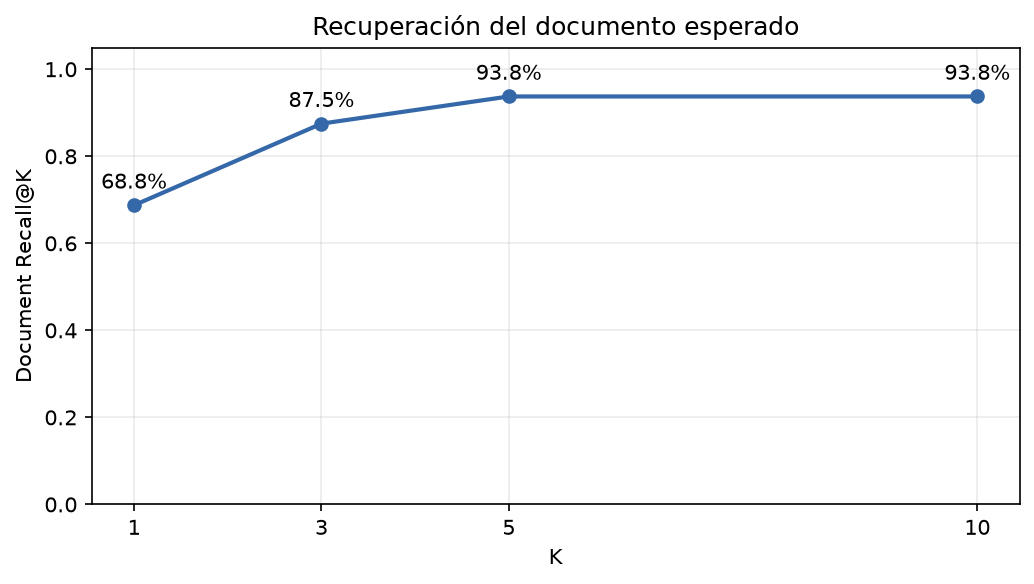

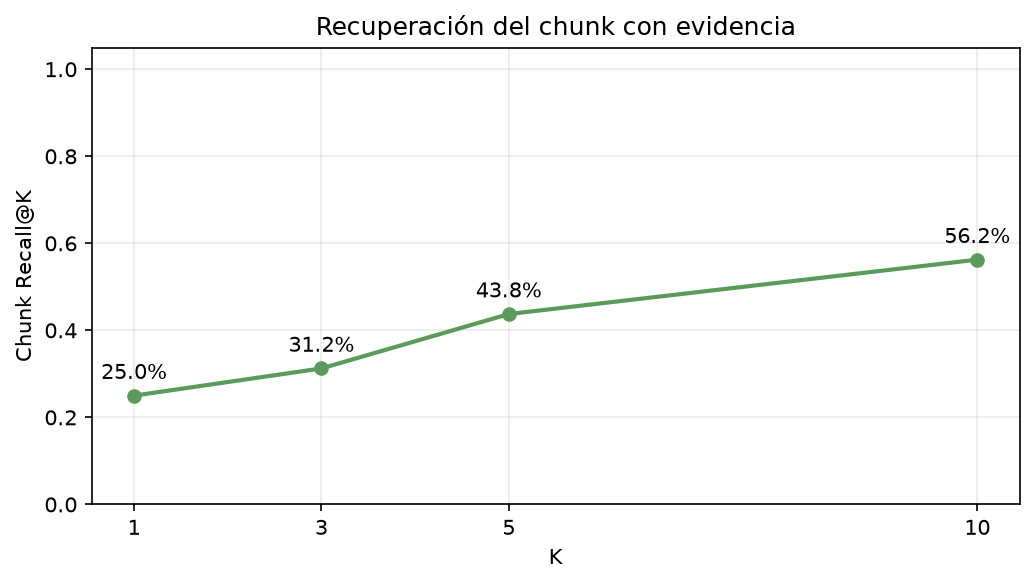

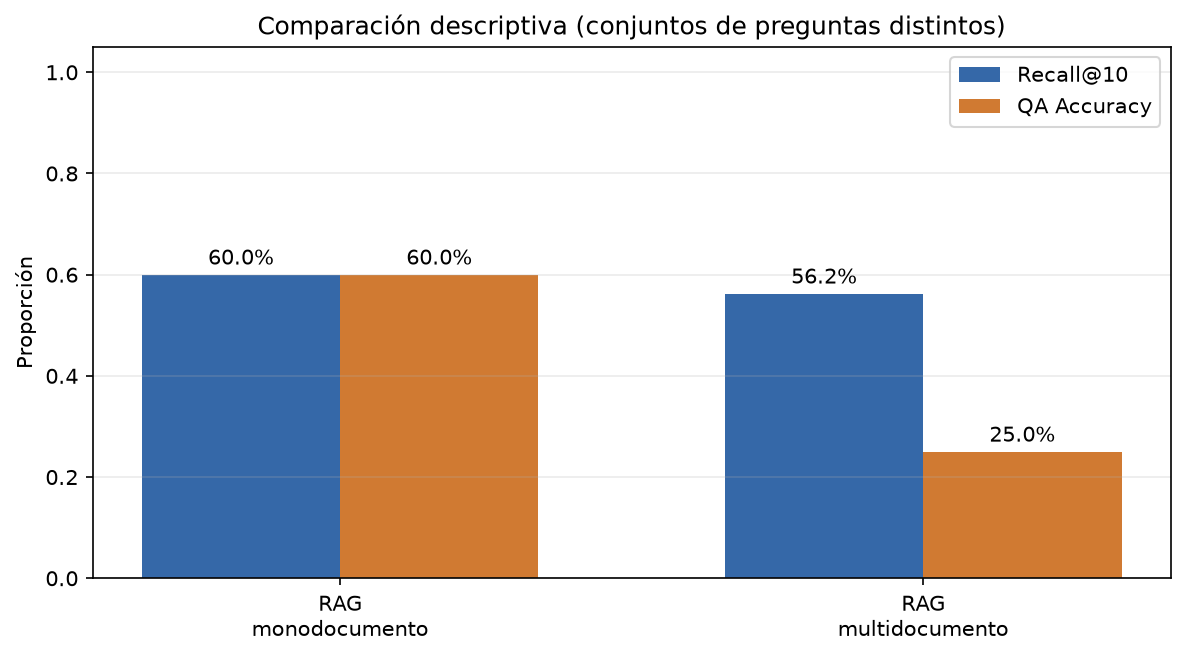

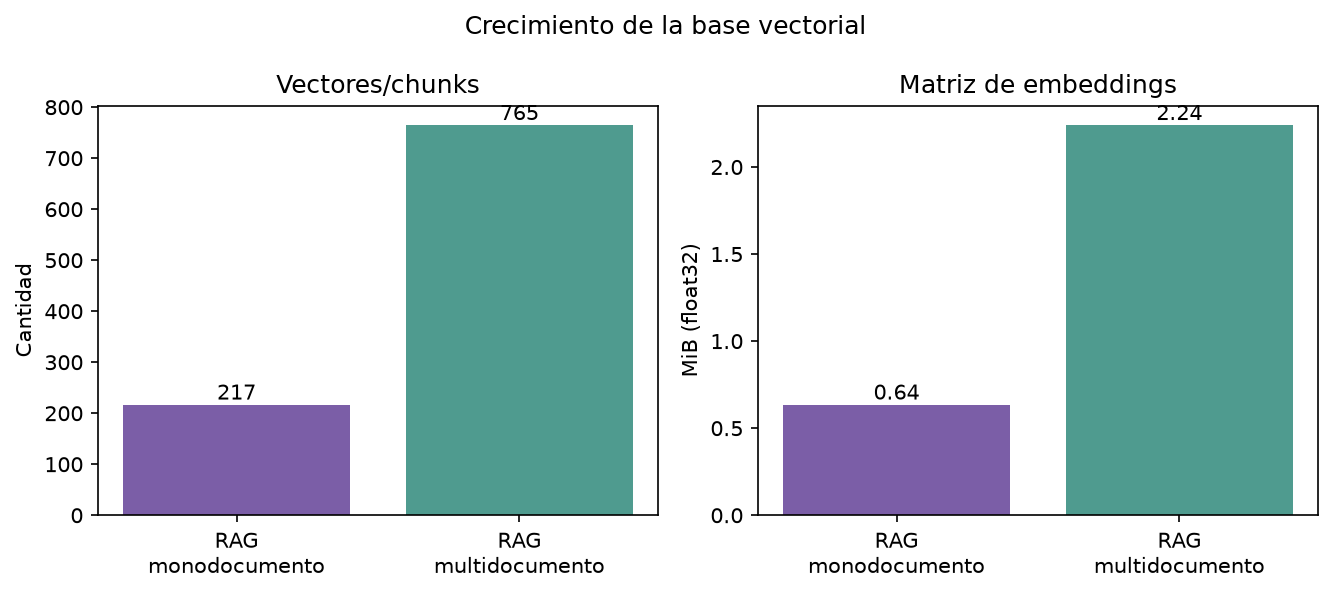

In [125]:
display(df_comparacion_multi.style.format({
    "recall_at_10": "{:.2%}", "qa_accuracy": "{:.2%}",
}))

for nombre_grafico in [
    "rag_multidocumento_document_recall_at_k.png",
    "rag_multidocumento_chunk_recall_at_k.png",
    "rag_monodocumento_vs_multidocumento.png",
    "rag_multidocumento_tamano_base_vectorial.png",
]:
    display(Image(filename=str(ruta_resultados_multi / "graficos" / nombre_grafico)))


## 20.9 Conclusión de la extensión

**Resultado.** El corpus creció de 1 a 9 documentos, de 62 a 199 páginas y de
217 a 765 vectores. Manteniendo 800/0, MPNet, `IndexFlatIP`, Top-10 y
BETO-SQAC, Document Recall@10 alcanzó 93.75 %, pero Chunk Recall@10 fue 56.25 %
y QA Accuracy respondible 25.00 %.

**Interpretación.** El experimento demuestra tres niveles distintos: elegir el
PDF, localizar evidencia y extraer el span. El primer nivel funcionó mucho
mejor que los dos siguientes. El crecimiento del corpus expuso vocabulario
compartido, fuentes alternativas capaces de producir la misma frase y scores
QA altos sobre evidencia equivocada.

**Limitaciones.** Son 18 preguntas diseñadas manualmente, una sola ejecución
temporal, búsqueda densa sin reranking y un extractor que no dispone de una
regla fiable de abstención. Los tiempos dependen del hardware.

**Decisión.** La extensión se conserva como resultado académico negativo y
trazable. El trabajo futuro prioritario es reranking, detección explícita de
preguntas sin respuesta, filtros de metadata, búsqueda híbrida, embeddings de
dominio e índices aproximados para corpus mayores.
